In [91]:
# -*- coding: utf-8 -*-
"""HODLR.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/14KvYWxP0tBlyzeegHUdHDvBnIZciWb6V
"""

import numpy as np
from math import sqrt
from numpy.linalg import norm
from time import perf_counter
from scipy.special import erf
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---

# Reproducibility
np.random.seed(42)

# Global constants and toggles
DEFAULT_USE_LOWRANK = True        # Set True for RandSVD/HODLR experiments
DEFAULT_RANK_K = 20               # Target rank for low-rank approximations
DEFAULT_POWER_ITERS = 1           # Power iterations for randomized SVD

# Choose Low-Rank Method (Change this in the experiment section)
# Options: 'ACA', 'RAND_SVD', 'HODLR'
LOWRANK_METHOD = 'HODLR'


# --- 2. DATA GENERATION (Mixture of Gaussians) ---

rng = np.random.default_rng(42)
N = 100  # Reduced for quick testing

# Mixture on R_+ (positive axis): Two Gaussian components
x = np.abs(np.concatenate([
    rng.normal(loc=2.0, scale=0.4, size=N//2),
    rng.normal(loc=5.0, scale=0.7, size=N - N//2)
])).astype(float)
x.sort()

# Midpoints z_k between consecutive ordered samples; M = N-1
z = 0.5 * (x[:-1] + x[1:])
M = z.shape[0]

# Empirical CDF at midpoints: T_k = k/N, k = 1..N-1
T = np.arange(1, N) / N

# --- 3. GAUSSIAN KERNEL FUNCTIONS & MATRIX BUILDERS ---

SQRT2 = sqrt(2.0)
INV_SQRT_2PI = 1.0 / sqrt(2.0 * np.pi)

In [92]:
def generate_mixture_gaussian_data(N, seed=42):
    """Generate mixture of Gaussians data (using existing logic)."""
    rng = np.random.default_rng(seed)
    x = np.abs(np.concatenate([
        rng.normal(loc=2.0, scale=0.4, size=N//2),
        rng.normal(loc=5.0, scale=0.7, size=N - N//2)
    ])).astype(float)
    x.sort()
    return x

def generate_exponential_data(N, seed=42):
    """Generate exponential distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.exponential(scale=2.0, size=N)
    x.sort()
    return x

def generate_uniform_data(N, seed=42):
    """Generate uniform distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(low=0.0, high=10.0, size=N)
    x.sort()
    return x

def generate_lognormal_data(N, seed=42):
    """Generate log-normal distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.lognormal(mean=1.0, sigma=0.5, size=N)
    x.sort()
    return x

def generate_beta_data(N, seed=42):
    """Generate beta distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.beta(a=2.0, b=5.0, size=N) * 10.0  # Scale to [0, 10]
    x.sort()
    return x

In [93]:
#normal pdf
def kappa(u):
    """Standard normal pdf φ(u). Vectorized."""
    return INV_SQRT_2PI * np.exp(-0.5 * u * u)

#normal cdf
def K(u):
    """Standard normal cdf Φ(u) via erf. Vectorized."""
    return 0.5 * (1.0 + erf(u / SQRT2))

#builds full desnse NxN matrix
def build_Kmat(x, z, h):
    """Kmat_{k,j} = Φ( (z_k - x_j)/h_j ). Returns (M, N)."""
    U = (z[:, None] - x[None, :]) / h[None, :]
    return K(U)

#builds full dense NxN gradient matrix
def build_D(x, z, h):
    """D_{k,j}(h) = -φ((z_k - x_j)/h_j) * (z_k - x_j) / h_j^2. Returns (M, N)."""
    N_local = len(x)
    diff = z[:, None] - x[None, :].reshape(1, N_local)
    U = diff / h[None, :]
    return -kappa(U) * (diff / (h[None, :] ** 2))




# --- 4. LOW-RANK ACCELERATION BUILDING BLOCKS ---

# --- 4.1 Randomized SVD (RandSVD) ---

#Comprsses dense matrix after building it
def randomized_svd(A, rank=32, q=1):
    """
    Randomized SVD for dense A (M x N).
    Returns U (M x r), S (r,), Vt (r x N) with r = min(rank, M, N).
    """
    M, N = A.shape
    r = int(min(rank, M, N))
    if r <= 0:
        return np.zeros((M,0)), np.zeros((0,)), np.zeros((0,N))

    Omega = np.random.randn(N, r)
    Y = A @ Omega                          # (M, r)
    for _ in range(q):
        Y = A @ (A.T @ Y)                  # power iterations

    Q, _ = np.linalg.qr(Y, mode='reduced') # (M, r)
    B = Q.T @ A                            # (r, N)
    Ub, S, Vt = np.linalg.svd(B, full_matrices=False)
    U = Q @ Ub                             # (M, r)
    return U, S, Vt

#matvec using RandSVD factors
def lowrank_apply_row_sum(U, S, Vt):
    """Approximate (A @ 1_N) given A ≈ U diag(S) Vt. Returns (M,)."""
    s = Vt @ np.ones(Vt.shape[1])          # (r,)
    return U @ (S * s)                     # (M,)

#matvec using RandSVD factors
def lowrank_apply_Dt_r(U, S, Vt, r_vec):
    """Approximate (A^T @ r_vec) given A ≈ U diag(S) Vt. Returns (N,)."""
    z = U.T @ r_vec                        # (r,)
    return Vt.T @ (S * z)                  # (N,)

# --- 4.2 Partially Pivoted ACA (PPACA) ---
# NOTE: This implementation is structurally correct but was empirically unstable
# in previous runs. We keep it for reference/testing the ACA method.

def pivoted_aca(A, tol=1e-8, max_rank=None):
    """PPACA (Alternative implementation, observed to be unstable)."""
    M, N = A.shape
    if max_rank is None: max_rank = min(M, N)
    U_list, V_list = [], []
    i = 0  # Initial pivot row index
    k = 0

    while k < max_rank:
        # 1. Compute residual row (R_k[i, :])
        row = A[i, :] - sum(u[i] * v for u, v in zip(U_list, V_list))
        # Find pivot column j in the residual row
        j = np.argmax(np.abs(row))

        pivot_val = row[j]
        if np.abs(pivot_val) < 1e-14: # Premature termination point
            break

        # 2. Compute residual column (R_k[:, j])
        col = A[:, j] - sum(v[j] * u for u, v in zip(U_list, V_list))

        # 3. Rank-1 Update (using outer product approximation)
        u_new = col / pivot_val
        v_new = row

        U_list.append(u_new)
        V_list.append(v_new)

        # 4. Next Pivot Row Selection (Partial Pivoting)
        i = np.argmax(np.abs(col))
        k += 1

    if not U_list: return np.zeros((M,0)), np.zeros((N,0))
    U = np.column_stack(U_list)
    V = np.column_stack(V_list)
    return U, V

def aca_apply_row_sum(U, V):
    """Approximate A @ 1 using A ≈ U V^T. Returns (M,)."""
    ones = np.ones(V.shape[0])
    return U @ (V.T @ ones)

def aca_apply_Dt_r(U, V, r_vec):
    """Approximate A^T @ r using A ≈ U V^T. Returns (N,)."""
    return V @ (U.T @ r_vec)

In [94]:
# ---------------- Rectangular Recursive HODLR (fixed signatures) ----------------
# takes a dense matrix A as input, recursively splits it, applies RandSVD to each off-diagonal block
def HODLR_factor_recursive_rect(A, rank=None, q=1, min_block=64):
    m, n = A.shape
    if min(m, n) <= min_block:
        return {"type": "dense", "A": A.copy(), "m": m, "n": n}

    m1 = m // 2; m2 = m - m1
    n1 = n // 2; n2 = n - n1

    A11 = A[:m1, :n1]
    A12 = A[:m1, n1:]
    A21 = A[m1:, :n1]
    A22 = A[m1:, n1:]

    H11 = HODLR_factor_recursive_rect(A11, rank=rank, q=q, min_block=min_block)
    H22 = HODLR_factor_recursive_rect(A22, rank=rank, q=q, min_block=min_block)

    # ranks capped by local block size
    rank_k12 = rank if rank is not None else max(1, min( max(4, min(m1, n2)//10), min(m1, n2) ))
    rank_k21 = rank if rank is not None else max(1, min( max(4, min(m2, n1)//10), min(m2, n1) ))

    if A12.size == 0:
        U12 = np.zeros((m1, 0)); S12 = np.zeros((0,)); V12t = np.zeros((0, n2))
    else:
        U12, S12, V12t = randomized_svd(A12, rank=int(rank_k12), q=q)

    if A21.size == 0:
        U21 = np.zeros((m2, 0)); S21 = np.zeros((0,)); V21t = np.zeros((0, n1))
    else:
        U21, S21, V21t = randomized_svd(A21, rank=int(rank_k21), q=q)

    node = {
        "type": "node",
        "m": m, "n": n, "m1": m1, "m2": m2, "n1": n1, "n2": n2,
        "H11": H11, "H22": H22,
        "U12": U12, "S12": S12, "V12t": V12t,
        "U21": U21, "S21": S21, "V21t": V21t
    }
    return node


#matvec y = A @ 1
def HODLR_apply_row_sum_recursive_rect(H, N_total=None):
    """
    y = A @ 1_n for H representing an m x n matrix. Returns length-m vector.
    Signature kept as (H, N_total=None) so it matches earlier usage: APPLY_F(K_factors, N).
    """
    if H["type"] == "dense":
        return H["A"] @ np.ones(H["n"])

    m1 = H["m1"]; m2 = H["m2"]; n1 = H["n1"]; n2 = H["n2"]

    # y1
    y1_diag = HODLR_apply_row_sum_recursive_rect(H["H11"], N_total=n1)
    if H["V12t"].size == 0:
        y1_off = np.zeros(m1)
    else:
        s12 = H["V12t"] @ np.ones(n2)
        y1_off = H["U12"] @ (H["S12"] * s12)

    y1 = y1_diag + y1_off

    # y2
    if H["V21t"].size == 0:
        y2_off = np.zeros(m2)
    else:
        s21 = H["V21t"] @ np.ones(n1)
        y2_off = H["U21"] @ (H["S21"] * s21)

    y2_diag = HODLR_apply_row_sum_recursive_rect(H["H22"], N_total=n2)
    y2 = y2_off + y2_diag

    return np.concatenate([y1, y2])

#transpose matvec g = A^T @ r
def HODLR_apply_Dt_r_recursive_rect(H, r_vec, M_total=None):
    """
    g = A^T @ r_vec for H representing an m x n matrix.
    Signature intentionally (H, r_vec, M_total) to match your solve_kde call:
        APPLY_J(D_factors, r, M)
    M_total is accepted but not needed here (kept for API compatibility).
    Returns length-n vector.
    """
    if H["type"] == "dense":
        return H["A"].T @ r_vec

    m1 = H["m1"]; m2 = H["m2"]; n1 = H["n1"]; n2 = H["n2"]
    r1 = r_vec[:m1]; r2 = r_vec[m1:]

    # g1: length n1
    g1_diag = HODLR_apply_Dt_r_recursive_rect(H["H11"], r1, M_total=None)
    if H["U21"].size == 0:
        g1_off = np.zeros(n1)
    else:
        z21 = H["U21"].T @ r2
        g1_off = H["V21t"].T @ (H["S21"] * z21)
    g1 = g1_diag + g1_off

    # g2: length n2
    g2_diag = HODLR_apply_Dt_r_recursive_rect(H["H22"], r2, M_total=None)
    if H["U12"].size == 0:
        g2_off = np.zeros(n2)
    else:
        z12 = H["U12"].T @ r1
        g2_off = H["V12t"].T @ (H["S12"] * z12)
    g2 = g2_off + g2_diag

    return np.concatenate([g1, g2])


#reconstructs dense matrix from HODLR tree
def HODLR_to_dense(H):
    """
    Reconstruct a (dense) matrix from the recursive HODLR-like dict H.
    Returns a dense numpy array of shape (m, n).
    Use only for debugging / checks.
    """
    if H["type"] == "dense":
        return H["A"].copy()

    # interior node
    m1 = H["m1"]; m2 = H["m2"]; n1 = H["n1"]; n2 = H["n2"]

    # Dense recon of diagonal blocks (recursively)
    A11 = HODLR_to_dense(H["H11"])  # (m1, n1)
    A22 = HODLR_to_dense(H["H22"])  # (m2, n2)

    # Reconstruct off-diagonals from low-rank factors
    if H["U12"].size == 0 or H["S12"].size == 0 or H["V12t"].size == 0:
        A12 = np.zeros((m1, n2))
    else:
        # U12: (m1, r12), S12: (r12,), V12t: (r12, n2)
        A12 = H["U12"] @ (H["S12"][:, None] * H["V12t"])

    if H["U21"].size == 0 or H["S21"].size == 0 or H["V21t"].size == 0:
        A21 = np.zeros((m2, n1))
    else:
        A21 = H["U21"] @ (H["S21"][:, None] * H["V21t"])

    # assemble blocks
    top = np.hstack([A11, A12])    # (m1, n1+n2)
    bot = np.hstack([A21, A22])    # (m2, n1+n2)
    A = np.vstack([top, bot])      # (m1+m2, n1+n2) == (m,n)
    return A


In [95]:
def solve_kde_enhanced(x, z, T, *,
                      lowrank_method='DENSE',
                      rank_k=20,
                      power_iters=1,
                      min_block=64,
                      eta=0.5,
                      max_iters=400,
                      tol=1e-8,
                      verbose=False):

    # ===== TIMING =====
    time_build_K = time_fact_K = time_ops_K = 0.0
    time_build_D = time_fact_D = time_ops_D = 0.0

    hodlr_construction_times = []
    gradient_descent_times = []

    use_lowrank = (lowrank_method != 'DENSE')

    # ===== METHOD SELECTION =====
    if lowrank_method == 'RAND_SVD':
        FACTOR = randomized_svd
        APPLY_F = lowrank_apply_row_sum
        APPLY_J = lowrank_apply_Dt_r
        APP_NAME = 'RandSVD'

    elif lowrank_method == 'HODLR':
        FACTOR = lambda A, rank=None, q=1: HODLR_factor_recursive_rect(
            A, rank=rank, q=q, min_block=min_block
        )
        APPLY_F = HODLR_apply_row_sum_recursive_rect
        APPLY_J = HODLR_apply_Dt_r_recursive_rect
        APP_NAME = 'HODLR'

    else:
        APP_NAME = 'DENSE'

    # ===== FORWARD =====
    def _F_hat(h, flag, track_construction=False):
        nonlocal time_build_K, time_fact_K, time_ops_K

        M, N = z.shape[0], x.shape[0]

        t0 = perf_counter()
        Kmat = build_Kmat(x, z, h)
        time_build_K += perf_counter() - t0

        if not use_lowrank:
            t1 = perf_counter()
            y = (Kmat @ np.ones(N)) / N
            time_ops_K += perf_counter() - t1
            return y

        # ===== HODLR BUILD =====
        t_fact = perf_counter()
        K_factors = FACTOR(Kmat, rank=rank_k, q=power_iters)
        fact_time = perf_counter() - t_fact
        time_fact_K += fact_time

        if track_construction:
            hodlr_construction_times.append(fact_time)

        # ===== MATVEC =====
        t2 = perf_counter()
        if lowrank_method == 'HODLR':
            y = APPLY_F(K_factors, N) / N
        else:
            y = APPLY_F(*K_factors) / N
        time_ops_K += perf_counter() - t2

        return y

    # ===== GRADIENT =====
    def _grad_J(h, track_gradient=False):
        nonlocal time_build_D, time_fact_D, time_ops_D

        grad_start = perf_counter()

        M, N = z.shape[0], x.shape[0]
        r = _F_hat(h, False, track_construction=track_gradient) - T

        # Build D
        t0 = perf_counter()
        D = build_D(x, z, h)
        d_build = perf_counter() - t0
        time_build_D += d_build

        if use_lowrank and track_gradient:
            hodlr_construction_times.append(d_build)

        if not use_lowrank:
            t1 = perf_counter()
            g = (2.0 / N) * (D.T @ r)
            time_ops_D += perf_counter() - t1

        else:
            # Factor D
            t_fact = perf_counter()
            D_factors = FACTOR(D, rank=rank_k, q=power_iters)
            d_fact = perf_counter() - t_fact
            time_fact_D += d_fact

            if track_gradient:
                hodlr_construction_times.append(d_fact)

            t2 = perf_counter()
            if lowrank_method == 'HODLR':
                g = (2.0 / N) * APPLY_J(D_factors, r, M)
            else:
                g = (2.0 / N) * APPLY_J(*D_factors, r_vec=r)
            time_ops_D += perf_counter() - t2

        if track_gradient:
            gradient_descent_times.append(perf_counter() - grad_start)

        return g

    # ===== INIT =====
    data_span = x.max() - x.min()
    h0 = max(0.2 * data_span / (len(x)**0.2), 1e-3)
    h = np.full_like(x, h0)
    alpha = np.log(h)

    J_hist = []
    t_hist = []
    grad_norm_hist = []
    eta_hist = []

    t0 = perf_counter()

    def _J(a, track=False):
        h_local = np.exp(a)
        r = _F_hat(h_local, False, track_construction=track) - T
        return float(r @ r)

    # ===== INITIAL =====
    J0 = _J(alpha, track=True)
    J_hist.append(J0)
    t_hist.append(0.0)
    grad_norm_hist.append(0.0)
    eta_hist.append(eta)

    # ===== OPTIMIZATION =====
    for t in range(max_iters):

        h = np.exp(alpha)
        grad_h = _grad_J(h, track_gradient=True)
        grad_alpha = grad_h * h
        grad_norm = norm(grad_alpha)

        J_curr = _J(alpha)

        alpha_new = alpha - eta * grad_alpha
        alpha_new = np.clip(alpha_new,
                            np.log(1e-3),
                            np.log(5.0 * data_span))

        J_next = _J(alpha_new, track=True)

        # Backtracking
        tries = 0
        while J_next > J_curr and tries < 10:
            eta *= 0.5
            alpha_new = alpha - eta * grad_alpha
            alpha_new = np.clip(alpha_new,
                                np.log(1e-3),
                                np.log(5.0 * data_span))
            J_next = _J(alpha_new)
            tries += 1

        alpha = alpha_new

        J_hist.append(J_next)
        t_hist.append(perf_counter() - t0)
        grad_norm_hist.append(grad_norm)
        eta_hist.append(eta)

        if grad_norm < tol:
            break

    h_opt = np.exp(alpha)

    # ===== FINAL METRICS (CLEAN + CONSISTENT) =====
    metrics = {
        "method": APP_NAME,
        "rank_k": rank_k,
        "min_block": min_block,

        # MAIN
        "J_final": J_hist[-1],
        "J_initial": J_hist[0],
        "total_time": t_hist[-1],

        # IMPORTANT (use this in plots)
        "total_gradient_descent_time": np.sum(gradient_descent_times),
        "total_hodlr_construction_time": np.sum(hodlr_construction_times),

        # TIMING BREAKDOWN
        "timing": {
            "K_build": time_build_K,
            "K_fact": time_fact_K,
            "K_ops": time_ops_K,
            "D_build": time_build_D,
            "D_fact": time_fact_D,
            "D_ops": time_ops_D,
        },

        # HISTORY
        "J_hist": J_hist,
        "t_hist": t_hist,
        "grad_norm_hist": grad_norm_hist,
        "eta_hist": eta_hist,

        # CONVERGENCE
        "convergence": {
            "iterations": len(J_hist) - 1,
            "final_grad_norm": grad_norm_hist[-1],
            "converged": grad_norm_hist[-1] < tol
        },

        # BANDWIDTH
        "h_stats": (
            float(h_opt.min()),
            float(np.median(h_opt)),
            float(h_opt.max())
        )
    }

    return h_opt, metrics

In [96]:
def true_mixture(u, SQRT2):
    """True mixture density from which data was drawn."""
    INV_SQRT_2PI = 1.0 / sqrt(2.0 * np.pi)

    def component_pdf(u, loc, scale):
        u_scaled = (u - loc) / scale
        return (1/scale) * INV_SQRT_2PI * np.exp(-0.5 * u_scaled**2)

    f1 = component_pdf(u, loc=2.0, scale=0.4)
    f2 = component_pdf(u, loc=5.0, scale=0.7)

    result = 0.5 * f1 + 0.5 * f2
    result[u < 0] = 0
    return result

def kde_estimate(u, x, h):
    """Evaluate KDE at points u using sample points x and per-sample bandwidths h."""
    U = (u[:, None] - x[None, :]) / h[None, :]
    return np.mean(kappa(U) / h[None, :], axis=1)

In [97]:
def run_scaling_experiment(
    N_values=[500, 1000, 2000, 3000, 5000],
    ranks=[10, 15, 20],
    min_block=32
):
    """
    KDE Dense vs HODLR (SVD) — FINAL CORRECT VERSION

    - Only mixture of 2 Gaussians (as required)
    - Dense + HODLR (SVD)
    - N truncated to 5000
    - 3 ranks (for Figure 1)
    - Single min_block (clean + consistent)
    """

    results = {
        'dense': [],
        'hodlr': {}
    }

    print("\n" + "="*80)
    print("DENSE vs HODLR (SVD) KDE ANALYSIS")
    print("="*80)

    for N in N_values:
        print(f"\nN = {N}")

        # ===== DATA (ONLY mixture Gaussian) =====
        x = generate_mixture_gaussian_data(N)
        z = 0.5 * (x[:-1] + x[1:])
        T = np.arange(1, N) / N

        # ===== DENSE =====
        print("  Running Dense...")
        _, m_dense = solve_kde_enhanced(
            x, z, T,
            lowrank_method='DENSE',
            max_iters=100,
            tol=1e-6,
            verbose=False
        )
        results['dense'].append(m_dense)

        # ===== HODLR (SVD) =====
        for rank in ranks:
            key = f'r{rank}'

            if key not in results['hodlr']:
                results['hodlr'][key] = []

            print(f"  Running HODLR (rank={rank})...")

            _, m_hodlr = solve_kde_enhanced(
                x, z, T,
                lowrank_method='HODLR',
                rank_k=rank,
                min_block=min_block,   # ✅ FIXED
                max_iters=100,
                tol=1e-6,
                verbose=False
            )

            results['hodlr'][key].append(m_hodlr)

    return results, N_values

In [98]:
import time
import numpy as np
import matplotlib.pyplot as plt

# ===== FONT (MATCH LATEX STYLE) =====
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# =========================================================
# ✅ FIGURE 1 (SVD HODLR) — COMBINED
# =========================================================
def fig1_svd_hodlr(N_values, ranks):

    build_all = {p: [] for p in ranks}
    matvec_all = {p: [] for p in ranks}
    error_all = {p: [] for p in ranks}

    for N in N_values:
        print(f"N={N}")
        x = generate_mixture_gaussian_data(N)
        z = 0.5 * (x[:-1] + x[1:])
        h = np.full(N, 0.3)

        K_dense = build_Kmat(x, z, h)

        for p in ranks:
            # Build
            t0 = time.perf_counter()
            H = HODLR_factor_recursive_rect(K_dense, rank=p)
            build_all[p].append(time.perf_counter() - t0)

            # Matvec
            t0 = time.perf_counter()
            _ = HODLR_apply_row_sum_recursive_rect(H)
            matvec_all[p].append(time.perf_counter() - t0)

            # Error
            K_approx = HODLR_to_dense(H)
            err = np.linalg.norm(K_dense - K_approx) / np.linalg.norm(K_dense)
            error_all[p].append(err)

    N = np.array(N_values)

    # ---- (a) BUILD ----
    plt.figure(figsize=(6,5))
    for p in ranks:
        plt.loglog(N, build_all[p], 'o-', label=f'r={p}')
    plt.loglog(N, N*np.log(N), '--', label='N log N')
    plt.xlabel('N')
    plt.ylabel('Build Time (s)')
    plt.title('HODLR (SVD) Construction Time')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig1a.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ---- (b) MATVEC ----
    plt.figure(figsize=(6,5))
    for p in ranks:
        plt.loglog(N, matvec_all[p], 'o-', label=f'r={p}')
    plt.loglog(N, N*np.log(N), '--', label='N log N')
    plt.xlabel('N')
    plt.ylabel('MatVec Time (s)')
    plt.title('HODLR (SVD) MatVec Time')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig1b.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ---- (c) ERROR ----
    plt.figure(figsize=(6,5))
    for p in ranks:
        plt.loglog(N, error_all[p], 'o-', label=f'r={p}')
    plt.xlabel('N')
    plt.ylabel('Relative Error')
    plt.title('HODLR (SVD) Approximation Error')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig1c.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# ✅ FIGURE 3 (ONE RANK ONLY)
# =========================================================
def fig3_total(results, N_values, rank_key='r15'):
    plt.figure(figsize=(6,5))

    dense = [m['total_time'] for m in results['dense']]
    hodlr = [m['total_time'] for m in results['hodlr'][rank_key]]

    plt.loglog(N_values, dense, 'o-', label='Dense')
    plt.loglog(N_values, hodlr, 'o-', label=f'HODLR ({rank_key})')

    N = np.array(N_values)
    plt.loglog(N, N*np.log(N), '--', label='N log N')

    plt.xlabel('N')
    plt.ylabel('Total Time (s)')
    plt.title('Total KDE Computation Time vs N')  # ✅ FIXED
    plt.legend()
    plt.grid(True)
    plt.savefig("fig3.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# ✅ FIGURE 4 (ONE RANK ONLY)
# =========================================================
def fig4_gd_time(results, N_values, rank_key='r15'):
    plt.figure(figsize=(6,5))

    dense = [m['total_gradient_descent_time'] for m in results['dense']]
    hodlr = [m['total_gradient_descent_time'] for m in results['hodlr'][rank_key]]

    plt.loglog(N_values, dense, 'o-', label='Dense')
    plt.loglog(N_values, hodlr, 'o-', label=f'HODLR ({rank_key})')

    plt.xlabel('N')
    plt.ylabel('Gradient Descent Time (s)')
    plt.title('Gradient Descent Time vs N')  # ✅ FIXED
    plt.legend()
    plt.grid(True)
    plt.savefig("fig4.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# ✅ FIGURE 5 (EXACTLY 3 N VALUES — FIXED)
# =========================================================
def fig5_speedup(results, N_values, rank_key='r15'):
    plt.figure(figsize=(6,5))

    # ✅ FIXED: explicit N selection
    target_N = [1000, 3000, 5000]
    idx = [N_values.index(n) for n in target_N]

    dense = [results['dense'][i]['total_time'] for i in idx]
    hodlr = [results['hodlr'][rank_key][i]['total_time'] for i in idx]

    speedup = [dense[i]/hodlr[i] for i in range(3)]

    plt.plot(target_N, speedup, 'o-')
    plt.xlabel('N')
    plt.ylabel('Speedup')
    plt.title('Speedup Factor (HODLR over Dense)')
    plt.grid(True)
    plt.savefig("fig5.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# ✅ FIGURE 6 (ONE RANK ONLY)
# =========================================================
def fig6_loss(results, rank_key='r15'):
    plt.figure(figsize=(6,5))

    plt.semilogy(results['dense'][0]['J_hist'], label='Dense')
    plt.semilogy(results['hodlr'][rank_key][0]['J_hist'],
                 label=f'HODLR ({rank_key})')

    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss vs Iteration (small N)')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig6.png", dpi=300, bbox_inches='tight')
    plt.show()

In [99]:
def run_complete_analysis():
    """
    Final clean pipeline for KDE (Dense + SVD-HODLR)
    STRICTLY matching paper requirements.
    """

    # ================= PARAMETERS =================
    N_values = [500, 1000, 2000, 3000, 4000, 5000]
    ranks = [10, 15, 20]
    min_block = 32   # ✅ FIXED (not list)

    # IMPORTANT: choose ONE rank for comparison plots
    rank_key = 'r15'

    print("="*60)
    print("FINAL KDE ANALYSIS (Dense + SVD-HODLR)")
    print("="*60)

    # ================= RUN EXPERIMENT =================
    print("\nRunning experiments (mixture of Gaussians only)...")

    results, N_values = run_scaling_experiment(
        N_values=N_values,
        ranks=ranks,
        min_block=min_block   # ✅ FIXED
    )

    print("\nExperiments completed.")

    # ================= FIGURE 1 =================
    print("\nGenerating Figure 1 (SVD-HODLR matrix analysis)...")
    fig1_svd_hodlr(N_values, ranks)

    # ================= FIGURE 3 =================
    print("Generating Figure 3 (Total Time)...")
    fig3_total(results, N_values, rank_key=rank_key)

    # ================= FIGURE 4 =================
    print("Generating Figure 4 (Gradient Descent Time)...")
    fig4_gd_time(results, N_values, rank_key=rank_key)

    # ================= FIGURE 5 =================
    print("Generating Figure 5 (Speedup)...")
    fig5_speedup(results, N_values, rank_key=rank_key)

    # ================= FIGURE 6 =================
    print("Generating Figure 6 (Loss vs Iteration)...")
    fig6_loss(results, rank_key=rank_key)

    # ================= SUMMARY =================
    print("\n" + "="*60)
    print("SUMMARY (using rank = 15)")
    print("="*60)

    dense_times = [m['total_time'] for m in results['dense']]
    hodlr_times = [m['total_time'] for m in results['hodlr'][rank_key]]

    speedups = [
        dense_times[i] / hodlr_times[i]
        for i in range(len(N_values))
    ]

    errors = [
        abs(results['hodlr'][rank_key][i]['J_final'] - results['dense'][i]['J_final']) /
        results['dense'][i]['J_final']
        for i in range(len(N_values))
    ]

    print(f"\nHODLR ({rank_key}):")
    print(f"  Avg speedup: {np.mean(speedups):.2f}x")
    print(f"  Max speedup: {np.max(speedups):.2f}x")
    print(f"  Avg error: {np.mean(errors):.2e}")

    print("\nAll figures saved (high quality, dpi=300).")

    return results, N_values

In [100]:
# def run_quick_demo():
#     """
#     Quick sanity check for KDE (Dense + SVD-HODLR)
#     Runs fast with small N.
#     """

#     print("\n" + "="*60)
#     print("QUICK DEMO (FAST CHECK)")
#     print("="*60)

#     # ✅ SMALL N ONLY (fast)
#     N_values = [500, 1000]
#     ranks = [5, 10]
#     min_blocks = [32]

#     print("\nRunning quick experiment...")

#     results, N_values = run_scaling_experiment(
#         N_values=N_values,
#         ranks=ranks,
#         min_blocks=min_blocks,
#         distributions=['mixture_gaussian']
#     )

#     results = results['mixture_gaussian']

#     print("\nQuick plots...")

#     # Only lightweight plots
#     fig3_total(results, N_values)
#     fig5_speedup(results, N_values)
#     fig6_loss(results)

#     print("\nQuick demo done ✅")

#     return results, N_values

In [101]:
# run_quick_demo()

FINAL KDE ANALYSIS (Dense + SVD-HODLR)

Running experiments (mixture of Gaussians only)...

DENSE vs HODLR (SVD) KDE ANALYSIS

N = 500
  Running Dense...
  Running HODLR (rank=10)...
  Running HODLR (rank=15)...
  Running HODLR (rank=20)...

N = 1000
  Running Dense...
  Running HODLR (rank=10)...
  Running HODLR (rank=15)...
  Running HODLR (rank=20)...

N = 2000
  Running Dense...
  Running HODLR (rank=10)...
  Running HODLR (rank=15)...
  Running HODLR (rank=20)...

N = 3000
  Running Dense...
  Running HODLR (rank=10)...
  Running HODLR (rank=15)...
  Running HODLR (rank=20)...

N = 4000
  Running Dense...
  Running HODLR (rank=10)...
  Running HODLR (rank=15)...
  Running HODLR (rank=20)...

N = 5000
  Running Dense...
  Running HODLR (rank=10)...
  Running HODLR (rank=15)...
  Running HODLR (rank=20)...

Experiments completed.

Generating Figure 1 (SVD-HODLR matrix analysis)...
N=500
N=1000
N=2000
N=3000
N=4000
N=5000


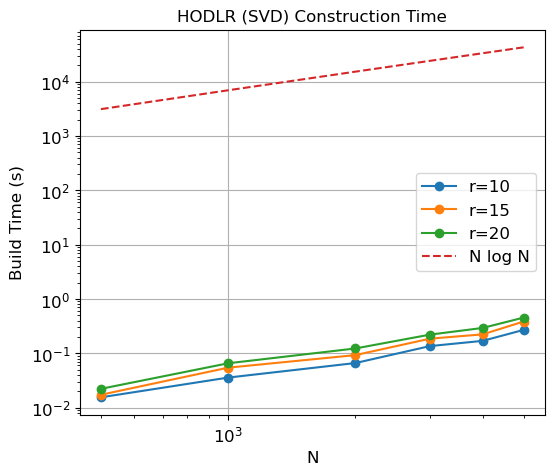

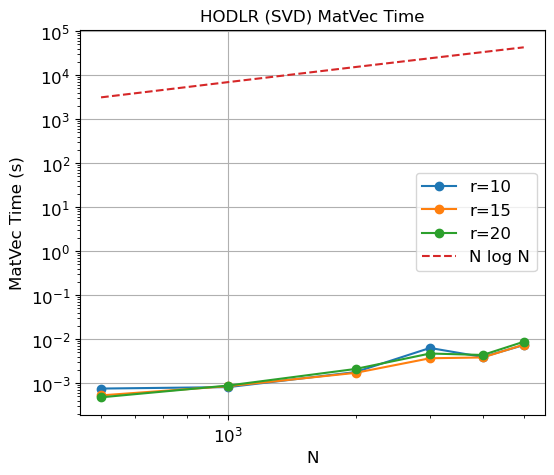

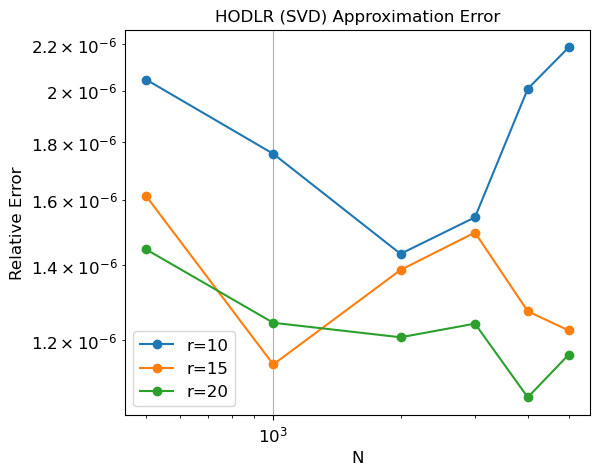

Generating Figure 3 (Total Time)...


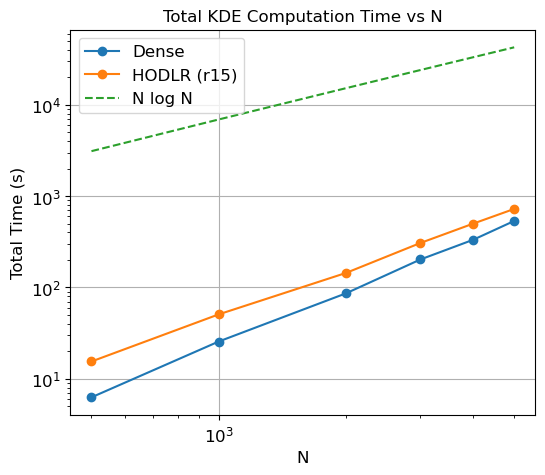

Generating Figure 4 (Gradient Descent Time)...


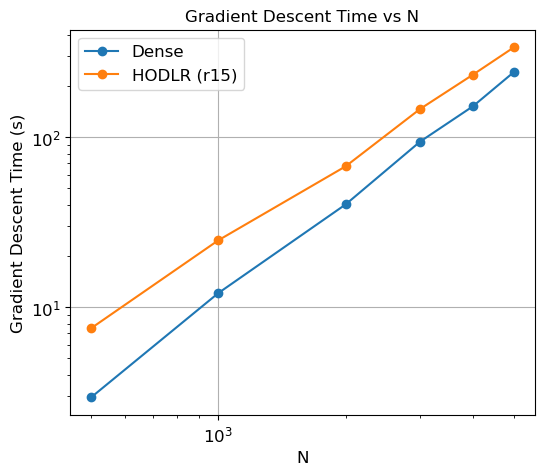

Generating Figure 5 (Speedup)...


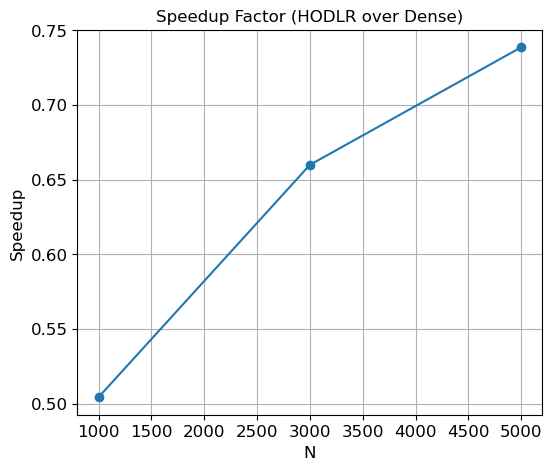

Generating Figure 6 (Loss vs Iteration)...


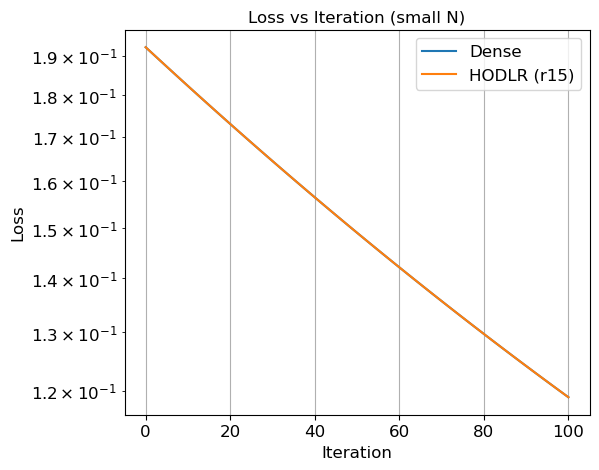


SUMMARY (using rank = 15)

HODLR (r15):
  Avg speedup: 0.60x
  Max speedup: 0.74x
  Avg error: 1.06e-07

All figures saved (high quality, dpi=300).


({'dense': [{'method': 'DENSE',
    'rank_k': 20,
    'min_block': 64,
    'J_final': 0.11890933127940397,
    'J_initial': 0.19221882159995757,
    'total_time': 6.265467399964109,
    'total_gradient_descent_time': np.float64(2.9490354999434203),
    'total_hodlr_construction_time': np.float64(0.0),
    'timing': {'K_build': 4.716688399901614,
     'K_fact': 0.0,
     'K_ops': 0.12074419937562197,
     'D_build': 1.2801591994939372,
     'D_fact': 0.0,
     'D_ops': 0.034151399857364595},
    'J_hist': [0.19221882159995757,
     0.19118911188463597,
     0.1901670490077254,
     0.18915257305854888,
     0.18814562453511918,
     0.18714614434325005,
     0.1861540737956202,
     0.18516935461079265,
     0.18419192891219005,
     0.1832217392270282,
     0.18225872848520783,
     0.18130284001816466,
     0.1803540175576836,
     0.17941220523467222,
     0.17847734757789824,
     0.177549389512692,
     0.17662827635961323,
     0.17571395383308513,
     0.17480636803999544,
     0

In [102]:
run_complete_analysis()

In [104]:
results,N_values = (
({'dense': [{'method': 'DENSE',
    'rank_k': 20,
    'min_block': 64,
    'J_final': 0.11890933127940397,
    'J_initial': 0.19221882159995757,
    'total_time': 6.265467399964109,
    'total_gradient_descent_time': np.float64(2.9490354999434203),
    'total_hodlr_construction_time': np.float64(0.0),
    'timing': {'K_build': 4.716688399901614,
     'K_fact': 0.0,
     'K_ops': 0.12074419937562197,
     'D_build': 1.2801591994939372,
     'D_fact': 0.0,
     'D_ops': 0.034151399857364595},
    'J_hist': [0.19221882159995757,
     0.19118911188463597,
     0.1901670490077254,
     0.18915257305854888,
     0.18814562453511918,
     0.18714614434325005,
     0.1861540737956202,
     0.18516935461079265,
     0.18419192891219005,
     0.1832217392270282,
     0.18225872848520783,
     0.18130284001816466,
     0.1803540175576836,
     0.17941220523467222,
     0.17847734757789824,
     0.177549389512692,
     0.17662827635961323,
     0.17571395383308513,
     0.17480636803999544,
     0.1739054654782658,
     0.17301119303539128,
     0.1721234979869497,
     0.17124232799508352,
     0.1703676311069521,
     0.16949935575316055,
     0.16863745074615924,
     0.16778186527862152,
     0.16693254892179643,
     0.1660894516238378,
     0.16525252370811294,
     0.16442171587148743,
     0.16359697918259347,
     0.16277826508007398,
     0.16196552537081182,
     0.16115871222813855,
     0.16035777819002756,
     0.15956267615726946,
     0.1587733593916327,
     0.15798978151400864,
     0.1572118965025429,
     0.15643965869075271,
     0.15567302276563122,
     0.15491194376574058,
     0.15415637707929236,
     0.15340627844221774,
     0.15266160393622746,
     0.15192230998686176,
     0.15118835336153147,
     0.1504596911675513,
     0.1497362808501641,
     0.1490180801905589,
     0.14830504730388144,
     0.1475971406372395,
     0.14689431896770133,
     0.1461965414002905,
     0.14550376736597448,
     0.14481595661965058,
     0.1441330692381268,
     0.14345506561810134,
     0.14278190647413747,
     0.14211355283663796,
     0.1414499660498161,
     0.14079110776966658,
     0.1401369399619349,
     0.1394874249000857,
     0.1388425251632723,
     0.13820220363430535,
     0.13756642349762235,
     0.13693514823725794,
     0.1363083416348167,
     0.13568596776744596,
     0.13506799100581188,
     0.1344543760120771,
     0.13384508773788145,
     0.13324009142232646,
     0.13263935258996107,
     0.1320428370487728,
     0.13145051088818227,
     0.13086234047704154,
     0.13027829246163752,
     0.12969833376369885,
     0.12912243157840955,
     0.12855055337242577,
     0.12798266688190002,
     0.12741874011050913,
     0.12685874132748995,
     0.1263026390656793,
     0.12575040211956148,
     0.12520199954332223,
     0.12465740064890854,
     0.12411657500409638,
     0.12357949243056453,
     0.1230461230019766,
     0.12251643704206969,
     0.12199040512275126,
     0.12146799806220286,
     0.12094918692299302,
     0.12043394301019703,
     0.11992223786952554,
     0.11941404328546122,
     0.11890933127940397],
    't_hist': [0.0,
     0.14323199994396418,
     0.2227398999966681,
     0.3123377999290824,
     0.39545509999152273,
     0.4739434999646619,
     0.5394502999261022,
     0.6037618999835104,
     0.6686390999238938,
     0.7294995000120252,
     0.7936732999514788,
     0.8831559999380261,
     0.9790071999887004,
     1.0449109999462962,
     1.10571939998772,
     1.1650296999141574,
     1.2221027999185026,
     1.2791869000066072,
     1.3336323000257835,
     1.3876183999236673,
     1.442748999921605,
     1.5055359000107273,
     1.5675598999951035,
     1.6337179999100044,
     1.6937824999913573,
     1.7572648000204936,
     1.8210708999540657,
     1.8801660999888554,
     1.9376143999397755,
     1.998322599916719,
     2.0610347000183538,
     2.1239076999481767,
     2.184708199929446,
     2.243075600010343,
     2.30300429998897,
     2.363089899998158,
     2.4238808000227436,
     2.4857377000153065,
     2.5479447999969125,
     2.606999299954623,
     2.674482199945487,
     2.7384400999872014,
     2.7964726999634877,
     2.8575156999286264,
     2.921792499953881,
     2.975721099996008,
     3.031345000024885,
     3.08572779991664,
     3.1383772999979556,
     3.196164899971336,
     3.2593585000140592,
     3.327061799936928,
     3.3937208999413997,
     3.456742199952714,
     3.519056999939494,
     3.5731610999209806,
     3.6293191999429837,
     3.684936899924651,
     3.749588800012134,
     3.8062344000209123,
     3.86603599996306,
     3.9260777999879792,
     3.9838713000062853,
     4.04169959994033,
     4.101011399994604,
     4.158388699986972,
     4.216260800021701,
     4.274153999984264,
     4.342097699991427,
     4.404323099995963,
     4.474394500022754,
     4.55051819991786,
     4.607889899984002,
     4.665703999926336,
     4.734162600012496,
     4.794294699910097,
     4.863431999925524,
     4.929091400001198,
     4.98855539993383,
     5.044834299944341,
     5.104402299970388,
     5.161961799953133,
     5.217395999934524,
     5.273785899975337,
     5.329359299968928,
     5.386360700009391,
     5.444465899956413,
     5.497639699955471,
     5.548382999957539,
     5.610192499938421,
     5.669953799922951,
     5.730243899975903,
     5.784636899945326,
     5.842273099930026,
     5.9061642999295145,
     5.9618053999729455,
     6.0245012999512255,
     6.084038299974054,
     6.144807599950582,
     6.200981899979524,
     6.265467399964109],
    'grad_norm_hist': [0.0,
     np.float64(0.04542309785032829),
     np.float64(0.045254105679353764),
     np.float64(0.045085811175572615),
     np.float64(0.04491821307742671),
     np.float64(0.04475131009152402),
     np.float64(0.044585100893285205),
     np.float64(0.04441958412758394),
     np.float64(0.04425475840938078),
     np.float64(0.04409062232435087),
     np.float64(0.043927174429505285),
     np.float64(0.043764413253805985),
     np.float64(0.04360233729877429),
     np.float64(0.04344094503909313),
     np.float64(0.04328023492320279),
     np.float64(0.043120205373890164),
     np.float64(0.042960854788871704),
     np.float64(0.04280218154136986),
     np.float64(0.042644183980683086),
     np.float64(0.04248686043274941),
     np.float64(0.04233020920070348),
     np.float64(0.042174228565427394),
     np.float64(0.04201891678609472),
     np.float64(0.04186427210070851),
     np.float64(0.04171029272663249),
     np.float64(0.0415569768611162),
     np.float64(0.04140432268181342),
     np.float64(0.04125232834729438),
     np.float64(0.041100991997551656),
     np.float64(0.04095031175449947),
     np.float64(0.040800285722466974),
     np.float64(0.04065091198868485),
     np.float64(0.04050218862376601),
     np.float64(0.040354113682179726),
     np.float64(0.040206685202719625),
     np.float64(0.04005990120896547),
     np.float64(0.039913759709738796),
     np.float64(0.039768258699552236),
     np.float64(0.039623396159052846),
     np.float64(0.03947917005545929),
     np.float64(0.03933557834299296),
     np.float64(0.039192618963303026),
     np.float64(0.03905028984588551),
     np.float64(0.03890858890849637),
     np.float64(0.03876751405755873),
     np.float64(0.038627063188564105),
     np.float64(0.03848723418646784),
     np.float64(0.038348024926078736),
     np.float64(0.03820943327244277),
     np.float64(0.038071457081221366),
     np.float64(0.03793409419906363),
     np.float64(0.03779734246397313),
     np.float64(0.03766119970566904),
     np.float64(0.0375256637459417),
     np.float64(0.037390732399002626),
     np.float64(0.037256403471829035),
     np.float64(0.037122674764503025),
     np.float64(0.03698954407054524),
     np.float64(0.03685700917724323),
     np.float64(0.036725067865974584),
     np.float64(0.036593717912524665),
     np.float64(0.03646295708739934),
     np.float64(0.03633278315613233),
     np.float64(0.03620319387958758),
     np.float64(0.03607418701425658),
     np.float64(0.035945760312550534),
     np.float64(0.035817911523087755),
     np.float64(0.03569063839097597),
     np.float64(0.03556393865808986),
     np.float64(0.03543781006334367),
     np.float64(0.03531225034295921),
     np.float64(0.035187257230729),
     np.float64(0.03506282845827474),
     np.float64(0.034938961755301236),
     np.float64(0.03481565484984566),
     np.float64(0.03469290546852242),
     np.float64(0.03457071133676334),
     np.float64(0.03444907017905362),
     np.float64(0.03432797971916327),
     np.float64(0.03420743768037431),
     np.float64(0.03408744178570369),
     np.float64(0.03396798975812181),
     np.float64(0.033849079320767174),
     np.float64(0.033730708197156546),
     np.float64(0.033612874111391335),
     np.float64(0.03349557478835976),
     np.float64(0.03337880795393509),
     np.float64(0.033262571335169924),
     np.float64(0.03314686266048663),
     np.float64(0.033031679659863866),
     np.float64(0.03291702006501939),
     np.float64(0.03280288160958907),
     np.float64(0.0326892620293022),
     np.float64(0.03257615906215319),
     np.float64(0.03246357044856966),
     np.float64(0.03235149393157691),
     np.float64(0.03223992725695895),
     np.float64(0.03212886817341606),
     np.float64(0.032018314432718915),
     np.float64(0.03190826378985934),
     np.float64(0.03179871400319771)],
    'eta_hist': [0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5],
    'convergence': {'iterations': 100,
     'final_grad_norm': np.float64(0.03179871400319771),
     'converged': np.False_},
    'h_stats': (0.27433819183378466, 0.3149101227501163, 0.35727072258648795)},
   {'method': 'DENSE',
    'rank_k': 20,
    'min_block': 64,
    'J_final': 0.19309329833586253,
    'J_initial': 0.30780713301566065,
    'total_time': 25.583740600035526,
    'total_gradient_descent_time': np.float64(12.108383699553087),
    'total_hodlr_construction_time': np.float64(0.0),
    'timing': {'K_build': 19.515257598948665,
     'K_fact': 0.0,
     'K_ops': 0.17278160096611828,
     'D_build': 5.369593300507404,
     'D_fact': 0.0,
     'D_ops': 0.0921831006417051},
    'J_hist': [0.30780713301566065,
     0.3062207827613217,
     0.30464572949560964,
     0.3030818842472078,
     0.3015291587283961,
     0.299987465331255,
     0.2984567171238525,
     0.29693682784641245,
     0.29542771190746786,
     0.2939292843800001,
     0.2924414609975622,
     0.29096415815039267,
     0.2894972928815149,
     0.2880407828828284,
     0.28659454649118904,
     0.28515850268448145,
     0.2837325710776838,
     0.28231667191892573,
     0.2809107260855417,
     0.27951465508011747,
     0.27812838102653464,
     0.27675182666601167,
     0.2753849153531414,
     0.27402757105192893,
     0.2726797183318276,
     0.27134128236377575,
     0.2700121889162336,
     0.26869236435122246,
     0.26738173562036704,
     0.2660802302609372,
     0.2647877763918984,
     0.263504302709962,
     0.26222973848564274,
     0.2609640135593222,
     0.25970705833731667,
     0.25845880378795244,
     0.257219181437649,
     0.2559881233670095,
     0.25476556220691926,
     0.2535514311346537,
     0.2523456638699953,
     0.25114819467136124,
     0.2499589583319394,
     0.2487778901758374,
     0.2476049260542411,
     0.24644000234158597,
     0.24528305593173935,
     0.2441340242341968,
     0.24299284517028874,
     0.2418594571694032,
     0.24073379916522006,
     0.23961581059195913,
     0.2385054313806441,
     0.2374026019553805,
     0.23630726322964635,
     0.23521935660260146,
     0.23413882395540891,
     0.23306560764757553,
     0.23199965051330465,
     0.230940895857869,
     0.22988928745399614,
     0.2288447695382741,
     0.22780728680757198,
     0.22677678441547777,
     0.2257532079687547,
     0.22473650352381364,
     0.22372661758320436,
     0.2227234970921245,
     0.22172708943494604,
     0.22073734243176063,
     0.21975420433494347,
     0.21877762382573435,
     0.21780755001083987,
     0.216843932419052,
     0.21588672099788642,
     0.21493586611024107,
     0.2139913185310723,
     0.2130530294440907,
     0.2121209504384759,
     0.21119503350561347,
     0.21027523103584597,
     0.2093614958152493,
     0.20845378102242526,
     0.2075520402253147,
     0.20665622737803097,
     0.205766296817712,
     0.2048822032613937,
     0.2040039018029017,
     0.20313134790976511,
     0.20226449742014735,
     0.2014033065398002,
     0.2005477318390359,
     0.1996977302497183,
     0.19885325906227724,
     0.19801427592274076,
     0.1971807388297867,
     0.1963526061318161,
     0.19552983652404654,
     0.19471238904562385,
     0.19390022307675558,
     0.19309329833586253],
    't_hist': [0.0,
     0.29335459996946156,
     0.5322615000186488,
     0.7475139999296516,
     0.995286799967289,
     1.201916899997741,
     1.4194240999640897,
     1.6676499999593943,
     1.8904766000341624,
     2.134037400013767,
     2.401574300020002,
     2.666986200027168,
     2.908028499921784,
     3.145197800011374,
     3.3800800000317395,
     3.6514550999272615,
     3.8714365999912843,
     4.1488295999588445,
     4.368868899997324,
     4.58156780002173,
     4.8040825999341905,
     5.044693999923766,
     5.264377899933606,
     5.513040199992247,
     5.723571199923754,
     5.962050499976613,
     6.197446499951184,
     6.433171699987724,
     6.670379100018181,
     6.917575099971145,
     7.161147799924947,
     7.40486599993892,
     7.644460899988189,
     7.91681810002774,
     8.185876999981701,
     8.426694600027986,
     8.6817590999417,
     8.943503099959344,
     9.200081299990416,
     9.453363299951889,
     9.722702399943955,
     9.993880999973044,
     10.246830399963073,
     10.515333199989982,
     10.732132300036028,
     10.979508899967186,
     11.241836700006388,
     11.502180299954489,
     11.76800199993886,
     11.982453499920666,
     12.20543390000239,
     12.442717500030994,
     12.718287899973802,
     12.97674289997667,
     13.222370199975558,
     13.500614800024778,
     13.762666799942963,
     14.027740099932998,
     14.25138919998426,
     14.464769899961539,
     14.70235039992258,
     14.926314599928446,
     15.139796199975535,
     15.442776500014588,
     15.761895000003278,
     16.049528099945746,
     16.300676599959843,
     16.559814799926244,
     16.840841399971396,
     17.19868699996732,
     17.54235110001173,
     17.878487100009806,
     18.17677569994703,
     18.475799200008623,
     18.743199900025502,
     18.997799500008114,
     19.261843499960378,
     19.515473800012842,
     19.77590569993481,
     20.03700619994197,
     20.29199579998385,
     20.56100400001742,
     20.836906499927863,
     21.103878299938515,
     21.36943700001575,
     21.62948649993632,
     21.907937999931164,
     22.175317400018685,
     22.445496700005606,
     22.708190899924375,
     23.00401759997476,
     23.275512899970636,
     23.55710909992922,
     23.846048000035807,
     24.116755399969406,
     24.39268579997588,
     24.670525699970312,
     24.9476624999661,
     25.17898680001963,
     25.38122460001614,
     25.583740600035526],
    'grad_norm_hist': [0.0,
     np.float64(0.056377043870141176),
     np.float64(0.0561759062238694),
     np.float64(0.05597563836224506),
     np.float64(0.055776237381265435),
     np.float64(0.0555777003628083),
     np.float64(0.05538002437516806),
     np.float64(0.05518320647358366),
     np.float64(0.054987243700758116),
     np.float64(0.054792133087369965),
     np.float64(0.05459787165257666),
     np.float64(0.054404456404509735),
     np.float64(0.054211884340762226),
     np.float64(0.05402015244886804),
     np.float64(0.053829257706773666),
     np.float64(0.05363919708330199),
     np.float64(0.053449967538608575),
     np.float64(0.053261566024630204),
     np.float64(0.05307398948552608),
     np.float64(0.05288723485811144),
     np.float64(0.0527012990722839),
     np.float64(0.05251617905144234),
     np.float64(0.0523318717128989),
     np.float64(0.05214837396828338),
     np.float64(0.05196568272394108),
     np.float64(0.051783794881323134),
     np.float64(0.05160270733737038),
     np.float64(0.05142241698489009),
     np.float64(0.05124292071292606),
     np.float64(0.05106421540712211),
     np.float64(0.05088629795007863),
     np.float64(0.05070916522170303),
     np.float64(0.05053281409955339),
     np.float64(0.05035724145917589),
     np.float64(0.050182444174435924),
     np.float64(0.05000841911784287),
     np.float64(0.049835163160868834),
     np.float64(0.04966267317426121),
     np.float64(0.04949094602834925),
     np.float64(0.049319978593344756),
     np.float64(0.049149767739636835),
     np.float64(0.048980310338080826),
     np.float64(0.048811603260281715),
     np.float64(0.048643643378871566),
     np.float64(0.048476427567781706),
     np.float64(0.04830995270250924),
     np.float64(0.04814421566037814),
     np.float64(0.04797921332079498),
     np.float64(0.04781494256549951),
     np.float64(0.04765140027880977),
     np.float64(0.04748858334786228),
     np.float64(0.047326488662847034),
     np.float64(0.04716511311723749),
     np.float64(0.04700445360801569),
     np.float64(0.046844507035892435),
     np.float64(0.046685270305522664),
     np.float64(0.04652674032571614),
     np.float64(0.04636891400964333),
     np.float64(0.04621178827503702),
     np.float64(0.04605536004438882),
     np.float64(0.04589962624514185),
     np.float64(0.045744583809878475),
     np.float64(0.04559022967650397),
     np.float64(0.04543656078842587),
     np.float64(0.045283574094729044),
     np.float64(0.04513126655034668),
     np.float64(0.04497963511622707),
     np.float64(0.04482867675949643),
     np.float64(0.04467838845361783),
     np.float64(0.044528767178546),
     np.float64(0.04437980992087847),
     np.float64(0.04423151367400288),
     np.float64(0.04408387543824037),
     np.float64(0.04393689222098562),
     np.float64(0.043790561036843006),
     np.float64(0.04364487890775923),
     np.float64(0.04349984286315255),
     np.float64(0.04335544994003854),
     np.float64(0.04321169718315226),
     np.float64(0.04306858164506727),
     np.float64(0.04292610038631148),
     np.float64(0.04278425047547929),
     np.float64(0.04264302898934109),
     np.float64(0.04250243301294929),
     np.float64(0.042362459639741355),
     np.float64(0.042223105971639856),
     np.float64(0.042084369119149465),
     np.float64(0.04194624620145111),
     np.float64(0.041808734346493084),
     np.float64(0.0416718306910796),
     np.float64(0.04153553238095623),
     np.float64(0.041399836570892905),
     np.float64(0.041264740424764024),
     np.float64(0.04113024111562596),
     np.float64(0.04099633582579207),
     np.float64(0.04086302174690505),
     np.float64(0.04073029608000677),
     np.float64(0.040598156035605695),
     np.float64(0.04046659883374195),
     np.float64(0.040335621704049834),
     np.float64(0.04020522188581812)],
    'eta_hist': [0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5],
    'convergence': {'iterations': 100,
     'final_grad_norm': np.float64(0.04020522188581812),
     'converged': np.False_},
    'h_stats': (0.2677709470525742, 0.30541092958875515, 0.338054418035358)},
   {'method': 'DENSE',
    'rank_k': 20,
    'min_block': 64,
    'J_final': 0.2771958878025159,
    'J_initial': 0.4180652382507739,
    'total_time': 86.20029460010119,
    'total_gradient_descent_time': np.float64(40.209923999616876),
    'total_hodlr_construction_time': np.float64(0.0),
    'timing': {'K_build': 67.34367200033739,
     'K_fact': 0.0,
     'K_ops': 0.4613697985187173,
     'D_build': 17.051957000163384,
     'D_fact': 0.0,
     'D_ops': 0.19408319983631372},
    'J_hist': [0.4180652382507739,
     0.41617191132605025,
     0.41429086587595465,
     0.4124220105792304,
     0.41056525482747386,
     0.408720508719988,
     0.40688768305865264,
     0.4050666893428193,
     0.40325743976422745,
     0.40145984720194533,
     0.39967382521733064,
     0.39789928804901786,
     0.396136150607928,
     0.3943843284723003,
     0.39264373788275136,
     0.390914295737355,
     0.3891959195867488,
     0.387488527629266,
     0.38579203870608825,
     0.3841063722964284,
     0.3824314485127339,
     0.38076718809591875,
     0.37911351241062063,
     0.3774703434404796,
     0.37583760378344894,
     0.3742152166471267,
     0.3726031058441148,
     0.37100119578740515,
     0.3694094114857909,
     0.36782767853930387,
     0.3662559231346784,
     0.36469407204084264,
     0.3631420526044342,
     0.3615997927453447,
     0.3600672209522887,
     0.3585442662784011,
     0.3570308583368605,
     0.35552692729653945,
     0.3540324038776789,
     0.3525472193475955,
     0.35107130551640864,
     0.3496045947328008,
     0.34814701987979757,
     0.3466985143705824,
     0.3452590121443315,
     0.34382844766208004,
     0.34240675590261144,
     0.3409938723583781,
     0.3395897330314437,
     0.33819427442945604,
     0.3368074335616458,
     0.33542914793484935,
     0.3340593555495636,
     0.33269799489602125,
     0.33134500495029784,
     0.3300003251704412,
     0.328663895492631,
     0.32733565632736117,
     0.32601554855565285,
     0.32470351352528853,
     0.3233994930470775,
     0.322103429391143,
     0.32081526528324,
     0.3195349439010937,
     0.31826240887076995,
     0.3169976042630653,
     0.3157404745899281,
     0.3144909648009032,
     0.3132490202796001,
     0.3120145868401913,
     0.3107876107239318,
     0.3095680385957059,
     0.30835581754059943,
     0.3071508950604971,
     0.3059532190707026,
     0.3047627378965877,
     0.30357940027026237,
     0.30240315532727197,
     0.3012339526033186,
     0.3000717420310064,
     0.2989164739366106,
     0.2977680990368739,
     0.29662656843582313,
     0.2954918336216127,
     0.29436384646339137,
     0.2932425592081914,
     0.2921279244778447,
     0.2910198952659179,
     0.28991842493467607,
     0.2888234672120654,
     0.28773497618872235,
     0.28665290631500295,
     0.285577212398039,
     0.284507849598812,
     0.28344477342925567,
     0.2823879397493751,
     0.2813373047643943,
     0.28029282502192043,
     0.27925445740913546,
     0.27822215915000537,
     0.2771958878025159],
    't_hist': [0.0,
     1.222855200059712,
     2.1389548000879586,
     2.9835715000517666,
     3.863670499995351,
     4.729065000079572,
     5.622150600072928,
     6.49891550000757,
     7.308084700023755,
     8.174818600062281,
     9.025480900076218,
     9.861778400023468,
     10.684004400041886,
     11.476671200012788,
     12.32095990004018,
     13.213810000102967,
     14.117793000070378,
     14.927213300019503,
     15.797577899997123,
     16.713850200059824,
     17.5703301000176,
     18.496068100095727,
     19.35201190004591,
     20.189174700062722,
     21.083686700090766,
     21.928696700022556,
     22.76204780000262,
     23.602046200074255,
     24.439673300017603,
     25.273997700074688,
     26.155422900104895,
     27.03817010007333,
     28.0028447000077,
     28.903296400094405,
     29.73801500000991,
     30.650790200103074,
     31.506582600064576,
     32.42070960009005,
     33.26989300001878,
     34.101340000052005,
     34.92225180007517,
     35.78720050002448,
     36.671674300101586,
     37.513853600015864,
     38.37363530008588,
     39.211438700091094,
     40.071771200047806,
     40.92668970010709,
     41.87529190001078,
     42.71028150001075,
     43.6353237000294,
     44.72951470001135,
     45.612289200071245,
     46.47948580002412,
     47.33760190010071,
     48.14571000006981,
     48.96376539999619,
     49.767623700085096,
     50.59079790010583,
     51.45997810002882,
     52.3533599000657,
     53.198052800027654,
     53.971546600107104,
     54.7761042000493,
     55.67779840005096,
     56.54985430010129,
     57.471287699998356,
     58.286052600014955,
     59.14194600004703,
     59.99280810006894,
     60.76030470000114,
     61.5720139000332,
     62.41649279999547,
     63.267878200043924,
     64.10133269999642,
     64.95246460009366,
     65.75737690005917,
     66.62259290006477,
     67.437591599999,
     68.22557550005149,
     69.02099260000978,
     69.80853260005824,
     70.62467990000732,
     71.43386820005253,
     72.28356910008006,
     73.35423020005692,
     74.22623820009176,
     75.06159650010522,
     75.81345340004191,
     76.61237050010823,
     77.38783540006261,
     78.15573460003361,
     79.00153110001702,
     79.7873627000954,
     80.72852230002172,
     81.66074750002008,
     82.51558280002791,
     83.41672860004473,
     84.37797410006169,
     85.30835210008081,
     86.20029460010119],
    'grad_norm_hist': [0.0,
     np.float64(0.06158585159397145),
     np.float64(0.061385733921868246),
     np.float64(0.061186457177660705),
     np.float64(0.06098801789487047),
     np.float64(0.06079041261185489),
     np.float64(0.060593637872003114),
     np.float64(0.060397690223927956),
     np.float64(0.060202566221653576),
     np.float64(0.060008262424799154),
     np.float64(0.05981477539875849),
     np.float64(0.059622101714875676),
     np.float64(0.05943023795061674),
     np.float64(0.05923918068973766),
     np.float64(0.059048926522448295),
     np.float64(0.058859472045572764),
     np.float64(0.05867081386270602),
     np.float64(0.058482948584366846),
     np.float64(0.05829587282814725),
     np.float64(0.058109583218858216),
     np.float64(0.05792407638867213),
     np.float64(0.05773934897726162),
     np.float64(0.057555397631935075),
     np.float64(0.057372219007768906),
     np.float64(0.05718980976773625),
     np.float64(0.057008166582832774),
     np.float64(0.056827286132199055),
     np.float64(0.056647165103239895),
     np.float64(0.05646780019174048),
     np.float64(0.05628918810197964),
     np.float64(0.056111325546839896),
     np.float64(0.055934209247914736),
     np.float64(0.05575783593561283),
     np.float64(0.05558220234925947),
     np.float64(0.055407305237195226),
     np.float64(0.05523314135687167),
     np.float64(0.05505970747494448),
     np.float64(0.054887000367363895),
     np.float64(0.054715016819462406),
     np.float64(0.05454375362603985),
     np.float64(0.05437320759144606),
     np.float64(0.054203375529660876),
     np.float64(0.05403425426437173),
     np.float64(0.053865840629048714),
     np.float64(0.05369813146701738),
     np.float64(0.053531123631529016),
     np.float64(0.053364813985828756),
     np.float64(0.05319919940322128),
     np.float64(0.05303427676713434),
     np.float64(0.05287004297118),
     np.float64(0.0527064949192138),
     np.float64(0.05254362952539182),
     np.float64(0.0523814437142253),
     np.float64(0.052219934420633767),
     np.float64(0.052059098589995634),
     np.float64(0.05189893317819707),
     np.float64(0.05173943515167874),
     np.float64(0.05158060148748088),
     np.float64(0.05142242917328611),
     np.float64(0.05126491520746082),
     np.float64(0.0511080565990943),
     np.float64(0.05095185036803637),
     np.float64(0.05079629354493317),
     np.float64(0.05064138317126118),
     np.float64(0.05048711629935957),
     np.float64(0.0503334899924609),
     np.float64(0.050180501324720087),
     np.float64(0.05002814738124195),
     np.float64(0.04987642525810698),
     np.float64(0.04972533206239566),
     np.float64(0.04957486491221127),
     np.float64(0.04942502093670117),
     np.float64(0.049275797276076554),
     np.float64(0.049127191081630925),
     np.float64(0.04897919951575709),
     np.float64(0.04883181975196261),
     np.float64(0.04868504897488419),
     np.float64(0.048538884380300455),
     np.float64(0.04839332317514367),
     np.float64(0.04824836257750991),
     np.float64(0.048103999816668304),
     np.float64(0.047960232133068645),
     np.float64(0.04781705677834823),
     np.float64(0.04767447101533715),
     np.float64(0.047532472118062594),
     np.float64(0.047391057371752095),
     np.float64(0.0472502240728354),
     np.float64(0.04710996952894556),
     np.float64(0.04697029105891869),
     np.float64(0.04683118599279289),
     np.float64(0.04669265167180597),
     np.float64(0.04655468544839226),
     np.float64(0.04641728468617844),
     np.float64(0.04628044675997842),
     np.float64(0.046144169055787186),
     np.float64(0.04600844897077383),
     np.float64(0.045873283913273596),
     np.float64(0.04573867130277912),
     np.float64(0.04560460856993079),
     np.float64(0.045471093156506145),
     np.float64(0.0453381225154086)],
    'eta_hist': [0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5],
    'convergence': {'iterations': 100,
     'final_grad_norm': np.float64(0.0453381225154086),
     'converged': np.False_},
    'h_stats': (0.24972404680403762, 0.27940292587483295, 0.301700863333913)},
   {'method': 'DENSE',
    'rank_k': 20,
    'min_block': 64,
    'J_final': 0.334172627018831,
    'J_initial': 0.4852074113289957,
    'total_time': 202.4725551001029,
    'total_gradient_descent_time': np.float64(94.09115980088245),
    'total_hodlr_construction_time': np.float64(0.0),
    'timing': {'K_build': 158.35342359903734,
     'K_fact': 0.0,
     'K_ops': 1.0327331011649221,
     'D_build': 40.1886163004674,
     'D_fact': 0.0,
     'D_ops': 0.4097510998835787},
    'J_hist': [0.4852074113289957,
     0.48321366441778857,
     0.4812320335680219,
     0.4792624330160691,
     0.47730477765441975,
     0.4753589830266863,
     0.4734249653226448,
     0.4715026413733074,
     0.4695919286460233,
     0.46769274523961507,
     0.4658050098795424,
     0.46392864191310035,
     0.46206356130464343,
     0.46020968863085177,
     0.4583669450760126,
     0.4565352524273478,
     0.45471453307036436,
     0.45290470998423427,
     0.45110570673721284,
     0.44931744748208,
     0.4475398569516177,
     0.445772860454114,
     0.4440163838689011,
     0.44227035364192024,
     0.44053469678132207,
     0.4388093408530902,
     0.437094213976702,
     0.43538924482081437,
     0.4336943625989844,
     0.4320094970654115,
     0.4303345785107213,
     0.4286695377577685,
     0.4270143061574744,
     0.42536881558469375,
     0.4237329984341099,
     0.42210678761615894,
     0.4204901165529853,
     0.4188829191744213,
     0.4172851299140028,
     0.41569668370500557,
     0.4141175159765185,
     0.41254756264953785,
     0.4109867601330952,
     0.409435045320411,
     0.40789235558507675,
     0.40635862877726586,
     0.40483380321997225,
     0.40331781770527403,
     0.4018106114906308,
     0.4003121242952018,
     0.3988222962961942,
     0.3973410681252411,
     0.39586838086480136,
     0.3944041760445914,
     0.39294839563803946,
     0.39150098205876926,
     0.3900618781571098,
     0.3886310272166316,
     0.3872083729507064,
     0.38579385949909706,
     0.3843874314245713,
     0.38298903370954035,
     0.38159861175272525,
     0.38021611136584654,
     0.37884147877034213,
     0.3774746605941053,
     0.3761156038682548,
     0.3747642560239235,
     0.37342056488907593,
     0.3720844786853458,
     0.3707559460249048,
     0.36943491590734867,
     0.36812133771661343,
     0.366815161217909,
     0.3655163365546844,
     0.3642248142456105,
     0.36294054518158714,
     0.36166348062277826,
     0.3603935721956643,
     0.35913077189012227,
     0.3578750320565241,
     0.3566263054028648,
     0.3553845449919045,
     0.3541497042383408,
     0.3529217369059987,
     0.35170059710504453,
     0.3504862392892215,
     0.34927861825310796,
     0.34807768912939696,
     0.3468834073861941,
     0.3456957288243456,
     0.344514609574777,
     0.34334000609586024,
     0.3421718751708004,
     0.3410101739050409,
     0.33985485972369234,
     0.33870589036897975,
     0.3375632238977121,
     0.33642681867877067,
     0.33529663339061927,
     0.334172627018831],
    't_hist': [0.0,
     2.3930659000761807,
     4.2583901000907645,
     6.226848700083792,
     8.113892700057477,
     9.941570300026797,
     11.859870300046168,
     13.68196940002963,
     15.503713200101629,
     17.422502900008112,
     19.241538000060245,
     21.07158280001022,
     22.986363800009713,
     24.833706000004895,
     26.570562100037932,
     28.375064000021666,
     30.222356100101024,
     32.35326670005452,
     34.37269170000218,
     36.51124540006276,
     38.863719400018454,
     40.70876310009044,
     42.567064200062305,
     44.42839340004139,
     46.27087000000756,
     48.20066349999979,
     49.97896020009648,
     51.84255060006399,
     53.69063070008997,
     55.538169700070284,
     57.48754500003997,
     59.2453282000497,
     61.2035074000014,
     63.17754600010812,
     64.9608294001082,
     66.8691603000043,
     68.79534730000887,
     70.71018710010685,
     72.91928090003785,
     74.94399290008005,
     76.78212470002472,
     78.69842100003734,
     80.63556000008248,
     82.42450410011224,
     84.30886200000532,
     86.21309900004417,
     88.18329500011168,
     90.24285340006463,
     92.40652120008599,
     94.44209200004116,
     96.5024574000854,
     98.57556800008751,
     101.27524780004751,
     103.77248610008974,
     106.2982261000434,
     108.6832719000522,
     111.22844230011106,
     113.79860980005469,
     116.46115410001948,
     119.09957720001694,
     121.51031020004302,
     123.89900350000244,
     125.90861780010164,
     127.84869200002868,
     130.00837970001157,
     132.02912670001388,
     134.01140740001574,
     136.00067229999695,
     138.02622100000735,
     140.20949600008316,
     142.22565200005192,
     144.3315464000916,
     146.3391693000449,
     148.4394511000719,
     150.21048210002482,
     152.0640895999968,
     153.89571950002573,
     155.75514230004046,
     157.56394090002868,
     159.31067020003684,
     161.1922590000322,
     163.01279020006768,
     164.94269210007042,
     166.9393590000691,
     168.87795550003648,
     170.82634050003253,
     173.01818600005936,
     175.36292110010982,
     177.7410548001062,
     179.74276080005802,
     181.85509389999788,
     183.9641641000053,
     185.93140610004775,
     187.97987800010014,
     190.22384740004782,
     192.24944620009046,
     194.25611690001097,
     196.21843770006672,
     198.44428430008702,
     200.4938157000579,
     202.4725551001029],
    'grad_norm_hist': [0.0,
     np.float64(0.06319472259149894),
     np.float64(0.06300236341741668),
     np.float64(0.06281078319450328),
     np.float64(0.06261997857443716),
     np.float64(0.062429946219047294),
     np.float64(0.06224068280037946),
     np.float64(0.062052185000760464),
     np.float64(0.06186444951286027),
     np.float64(0.061677473039751976),
     np.float64(0.06149125229496982),
     np.float64(0.06130578400256513),
     np.float64(0.06112106489716031),
     np.float64(0.06093709172400074),
     np.float64(0.060753861239005176),
     np.float64(0.060571370208813605),
     np.float64(0.06038961541083394),
     np.float64(0.06020859363328641),
     np.float64(0.060028301675246254),
     np.float64(0.0598487363466849),
     np.float64(0.05966989446850903),
     np.float64(0.05949177287259829),
     np.float64(0.05931436840184104),
     np.float64(0.05913767791016871),
     np.float64(0.058961698262588305),
     np.float64(0.05878642633521352),
     np.float64(0.058611859015294115),
     np.float64(0.058437993201243946),
     np.float64(0.058264825802667265),
     np.float64(0.0580923537403838),
     np.float64(0.05792057394645205),
     np.float64(0.057749483364191535),
     np.float64(0.057579078948203334),
     np.float64(0.05740935766438932),
     np.float64(0.0572403164899702),
     np.float64(0.05707195241350195),
     np.float64(0.05690426243489121),
     np.float64(0.05673724356540927),
     np.float64(0.05657089282770467),
     np.float64(0.05640520725581495),
     np.float64(0.05624018389517668),
     np.float64(0.05607581980263476),
     np.float64(0.05591211204645026),
     np.float64(0.05574905770630722),
     np.float64(0.05558665387331834),
     np.float64(0.05542489765002956),
     np.float64(0.055263786150423454),
     np.float64(0.055103316499921826),
     np.float64(0.05494348583538688),
     np.float64(0.054784291305121774),
     np.float64(0.05462573006886989),
     np.float64(0.054467799297813244),
     np.float64(0.05431049617456993),
     np.float64(0.05415381789319053),
     np.float64(0.053997761659153855),
     np.float64(0.053842324689361426),
     np.float64(0.05368750421213131),
     np.float64(0.05353329746719104),
     np.float64(0.05337970170566978),
     np.float64(0.05322671419008931),
     np.float64(0.05307433219435466),
     np.float64(0.05292255300374365),
     np.float64(0.05277137391489571),
     np.float64(0.05262079223580002),
     np.float64(0.05247080528578271),
     np.float64(0.052321410395493644),
     np.float64(0.052172604906892045),
     np.float64(0.05202438617323194),
     np.float64(0.05187675155904647),
     np.float64(0.05172969844013184),
     np.float64(0.05158322420353032),
     np.float64(0.051437326247512974),
     np.float64(0.05129200198156139),
     np.float64(0.051147248826349107),
     np.float64(0.05100306421372221),
     np.float64(0.05085944558667945),
     np.float64(0.05071639039935194),
     np.float64(0.05057389611698183),
     np.float64(0.050431960215901066),
     np.float64(0.05029058018350909),
     np.float64(0.05014975351825033),
     np.float64(0.05000947772959101),
     np.float64(0.04986975033799564),
     np.float64(0.049730568874902806),
     np.float64(0.04959193088270075),
     np.float64(0.04945383391470221),
     np.float64(0.049316275535119074),
     np.float64(0.049179253319036394),
     np.float64(0.04904276485238615),
     np.float64(0.04890680773192052),
     np.float64(0.04877137956518453),
     np.float64(0.04863647797048891),
     np.float64(0.0485021005768819),
     np.float64(0.048368245024121015),
     np.float64(0.048234908962644533),
     np.float64(0.04810209005354243),
     np.float64(0.04796978596852703),
     np.float64(0.047837994389903375),
     np.float64(0.04770671301053933),
     np.float64(0.047575939533835175),
     np.float64(0.04744567167369311)],
    'eta_hist': [0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5],
    'convergence': {'iterations': 100,
     'final_grad_norm': np.float64(0.04744567167369311),
     'converged': np.False_},
    'h_stats': (0.23805443806704338, 0.26286672526766197, 0.2801944448703083)},
   {'method': 'DENSE',
    'rank_k': 20,
    'min_block': 64,
    'J_final': 0.37176856757974996,
    'J_initial': 0.5244837774947767,
    'total_time': 332.8233590000309,
    'total_gradient_descent_time': np.float64(151.84466260008048),
    'total_hodlr_construction_time': np.float64(0.0),
    'timing': {'K_build': 264.78651629947126,
     'K_fact': 0.0,
     'K_ops': 1.6670560016063973,
     'D_build': 62.37968649948016,
     'D_fact': 0.0,
     'D_ops': 0.6184142999118194},
    'J_hist': [0.5244837774947767,
     0.5224982418640661,
     0.5205240854226849,
     0.5185612312791821,
     0.5166096031131715,
     0.5146691251709616,
     0.5127397222612179,
     0.5108213197506537,
     0.5089138435597551,
     0.5070172201585335,
     0.5051313765623088,
     0.5032562403275243,
     0.5013917395475881,
     0.4995378028487483,
     0.49769435938599677,
     0.49586133883899886,
     0.4940386714080567,
     0.4922262878101024,
     0.4904241192747151,
     0.48863209754017184,
     0.4868501548495258,
     0.4850782239467115,
     0.4833162380726814,
     0.48156413096156914,
     0.4798218368368804,
     0.4780892904077133,
     0.47636642686500635,
     0.47465318187781197,
     0.4729494915896023,
     0.471255292614598,
     0.4695705220341241,
     0.4678951173929992,
     0.4662290166959441,
     0.46457215840402055,
     0.4629244814310977,
     0.46128592514034283,
     0.4596564293407406,
     0.45803593428363626,
     0.4564243806593079,
     0.4548217095935595,
     0.4532278626443478,
     0.4516427817984245,
     0.4500664094680137,
     0.44849868848750785,
     0.4469395621101913,
     0.44538897400499156,
     0.443846868253247,
     0.4423131893455111,
     0.4407878821783694,
     0.4392708920512898,
     0.4377621646634915,
     0.43626164611084006,
     0.43476928288276795,
     0.4332850218592146,
     0.43180881030759377,
     0.430340595879784,
     0.428880326609138,
     0.42742795090752206,
     0.42598341756237335,
     0.42454667573378113,
     0.4231176749515916,
     0.42169636511253417,
     0.4202826964773708,
     0.41887661966806755,
     0.4174780856649858,
     0.4160870458041012,
     0.41470345177423745,
     0.41332725561432565,
     0.411958409710684,
     0.41059686679432006,
     0.4092425799382516,
     0.40789550255485146,
     0.4065555883932099,
     0.4052227915365218,
     0.40389706639948975,
     0.40257836772575195,
     0.4012666505853265,
     0.3999618703720793,
     0.3986639828012097,
     0.3973729439067547,
     0.3960887100391177,
     0.3948112378626125,
     0.3935404843530274,
     0.39227640679521003,
     0.39101896278066894,
     0.3897681102051981,
     0.3885238072665159,
     0.38728601246192573,
     0.386054684585993,
     0.38482978272824314,
     0.38361126627087655,
     0.38239909488650026,
     0.38119322853587934,
     0.37999362746570853,
     0.37880025220639496,
     0.3776130635698657,
     0.37643202264738773,
     0.3752570908074093,
     0.37408822969341393,
     0.37292540122179607,
     0.37176856757974996],
    't_hist': [0.0,
     4.247101500048302,
     7.3662234001094475,
     10.744702400057577,
     13.879281600005925,
     16.99133830005303,
     20.18099310004618,
     23.27890350006055,
     26.39649370010011,
     29.63899940007832,
     32.83992090006359,
     36.10111010004766,
     39.32240130007267,
     42.470089700073004,
     45.70830020005815,
     48.88786850008182,
     52.10981290007476,
     55.373437600093894,
     59.74761670001317,
     63.012352899997495,
     66.40638550010044,
     69.8088812000351,
     73.19106980005745,
     76.58051470003556,
     80.04476400010753,
     83.38463580003008,
     86.64706220000517,
     89.98650310002267,
     93.25806070002727,
     96.69251810002606,
     100.27534849999938,
     103.53683200001251,
     107.07112810004037,
     110.43095000006724,
     113.72852180001792,
     117.02091910003219,
     120.3151737001026,
     123.71368410007562,
     127.05974850000348,
     130.46724770008586,
     133.8364032000536,
     137.33193830004893,
     141.24444939999375,
     145.01469550002366,
     148.42626960005146,
     151.66410440008622,
     155.06317360000685,
     158.3261134000495,
     161.5914023000514,
     164.81641160009895,
     168.16587770008482,
     171.52431040001102,
     174.96233580005355,
     178.28360840003006,
     181.46253040002193,
     184.75285330007318,
     187.82996880006976,
     190.98998480010778,
     194.1921444000909,
     197.37677580001764,
     200.47195270005614,
     203.66839040000923,
     206.86933450005017,
     209.9883397000376,
     213.18371790007222,
     216.365933699999,
     219.90173350006808,
     223.1469193000812,
     226.36919310002122,
     229.5216593000805,
     232.75733280007262,
     235.92653560009785,
     239.44618000008631,
     242.69256009999663,
     245.86301740002818,
     249.19510570005514,
     252.55464280000888,
     255.86320940009318,
     259.28386250010226,
     262.5512905000942,
     265.8120961000677,
     269.0299929000903,
     272.2905536000617,
     275.5654922000831,
     278.7421376000857,
     282.0567804001039,
     285.329460500041,
     288.7097927000141,
     292.01116880006157,
     295.296231900109,
     298.57065650005825,
     301.9130142000504,
     305.2082915001083,
     308.56759010010865,
     311.9740769000491,
     315.5022602000972,
     318.9473624000093,
     322.39598290005233,
     325.95244760008063,
     329.47077810007613,
     332.8233590000309],
    'grad_norm_hist': [0.0,
     np.float64(0.06306171385017935),
     np.float64(0.0628807028293895),
     np.float64(0.06270039786504474),
     np.float64(0.06252079591426618),
     np.float64(0.062341893945460865),
     np.float64(0.06216368893833165),
     np.float64(0.061986177883886065),
     np.float64(0.0618093577844439),
     np.float64(0.061633225653643986),
     np.float64(0.06145777851644986),
     np.float64(0.06128301340915417),
     np.float64(0.06110892737938245),
     np.float64(0.06093551748609558),
     np.float64(0.060762780799591534),
     np.float64(0.060590714401505985),
     np.float64(0.060419315384811996),
     np.float64(0.06024858085381896),
     np.float64(0.06007850792417051),
     np.float64(0.05990909372284151),
     np.float64(0.059740335388134246),
     np.float64(0.059572230069673805),
     np.float64(0.05940477492840254),
     np.float64(0.0592379671365738),
     np.float64(0.0590718038777448),
     np.float64(0.05890628234676871),
     np.float64(0.05874139974978604),
     np.float64(0.058577153304215215),
     np.float64(0.0584135402387424),
     np.float64(0.058250557793310676),
     np.float64(0.05808820321910848),
     np.float64(0.057926473778557204),
     np.float64(0.05776536674529844),
     np.float64(0.05760487940418029),
     np.float64(0.05744500905124306),
     np.float64(0.057285752993704434),
     np.float64(0.05712710854994388),
     np.float64(0.05696907304948666),
     np.float64(0.056811643832986945),
     np.float64(0.056654818252210686),
     np.float64(0.05649859367001751),
     np.float64(0.05634296746034256),
     np.float64(0.0561879370081773),
     np.float64(0.05603349970955008),
     np.float64(0.055879652971506114),
     np.float64(0.05572639421208692),
     np.float64(0.055573720860309324),
     np.float64(0.05542163035614384),
     np.float64(0.0552701201504928),
     np.float64(0.05511918770516774),
     np.float64(0.05496883049286662),
     np.float64(0.05481904599715037),
     np.float64(0.05466983171241915),
     np.float64(0.054521185143888144),
     np.float64(0.05437310380756288),
     np.float64(0.05422558523021427),
     np.float64(0.05407862694935323),
     np.float64(0.053932226513204735),
     np.float64(0.053786381480681794),
     np.float64(0.05364108942135892),
     np.float64(0.053496347915445254),
     np.float64(0.053352154553757206),
     np.float64(0.0532085069376911),
     np.float64(0.053065402679195205),
     np.float64(0.052922839400741495),
     np.float64(0.05278081473529724),
     np.float64(0.052639326326296226),
     np.float64(0.05249837182760954),
     np.float64(0.05235794890351628),
     np.float64(0.05221805522867396),
     np.float64(0.05207868848808858),
     np.float64(0.051939846377084264),
     np.float64(0.051801526601273205),
     np.float64(0.05166372687652467),
     np.float64(0.05152644492893435),
     np.float64(0.051389678494793076),
     np.float64(0.05125342532055556),
     np.float64(0.051117683162808764),
     np.float64(0.05098244978824027),
     np.float64(0.05084772297360623),
     np.float64(0.05071350050569912),
     np.float64(0.050579780181315606),
     np.float64(0.0504465598072239),
     np.float64(0.05031383720013106),
     np.float64(0.05018161018665017),
     np.float64(0.050049876603267276),
     np.float64(0.049918634296308294),
     np.float64(0.049787881121905624),
     np.float64(0.049657614945964657),
     np.float64(0.04952783364413021),
     np.float64(0.04939853510175283),
     np.float64(0.049269717213854904),
     np.float64(0.04914137788509662),
     np.float64(0.049013515029741925),
     np.float64(0.04888612657162432),
     np.float64(0.048759210444112605),
     np.float64(0.048632764590076365),
     np.float64(0.0485067869618515),
     np.float64(0.048381275521205684),
     np.float64(0.04825622823930365),
     np.float64(0.04813164309667245)],
    'eta_hist': [0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5],
    'convergence': {'iterations': 100,
     'final_grad_norm': np.float64(0.04813164309667245),
     'converged': np.False_},
    'h_stats': (0.22838167178300717, 0.24940026695137957, 0.2639832035492765)},
   {'method': 'DENSE',
    'rank_k': 20,
    'min_block': 64,
    'J_final': 0.4586492757576946,
    'J_initial': 0.6448141844345838,
    'total_time': 534.7804693999933,
    'total_gradient_descent_time': np.float64(241.41985399986152),
    'total_hodlr_construction_time': np.float64(0.0),
    'timing': {'K_build': 429.36756769940257,
     'K_fact': 0.0,
     'K_ops': 2.545019699144177,
     'D_build': 96.63007469964214,
     'D_fact': 0.0,
     'D_ops': 0.9366772003704682},
    'J_hist': [0.6448141844345838,
     0.6423969217726501,
     0.6399934408988752,
     0.6376036491108867,
     0.6352274543899714,
     0.6328647653959059,
     0.6305154914618213,
     0.6281795425891051,
     0.6258568294423373,
     0.6235472633442584,
     0.6212507562707809,
     0.6189672208460258,
     0.6166965703374013,
     0.6144387186507148,
     0.6121935803253117,
     0.6099610705292621,
     0.6077411050545697,
     0.6055336003124209,
     0.6033384733284655,
     0.6011556417381326,
     0.5989850237819767,
     0.5968265383010625,
     0.5946801047323769,
     0.5925456431042804,
     0.5904230740319834,
     0.5883123187130626,
     0.5862132989230091,
     0.5841259370107991,
     0.582050155894514,
     0.5799858790569746,
     0.5779330305414216,
     0.5758915349472167,
     0.5738613174255824,
     0.5718423036753718,
     0.5698344199388661,
     0.5678375929976064,
     0.5658517501682566,
     0.5638768192984926,
     0.5619127287629292,
     0.5599594074590686,
     0.558016784803288,
     0.5560847907268477,
     0.5541633556719392,
     0.5522524105877523,
     0.5503518869265823,
     0.5484617166399539,
     0.5465818321747883,
     0.5447121664695882,
     0.5428526529506565,
     0.5410032255283411,
     0.5391638185933094,
     0.5373343670128551,
     0.5355148061272221,
     0.5337050717459672,
     0.5319051001443453,
     0.5301148280597213,
     0.528334192688015,
     0.5265631316801634,
     0.5248015831386202,
     0.5230494856138742,
     0.5213067781009999,
     0.5195734000362316,
     0.5178492912935618,
     0.5161343921813716,
     0.5144286434390827,
     0.512731986233834,
     0.5110443621571873,
     0.5093657132218583,
     0.5076959818584678,
     0.5060351109123252,
     0.5043830436402297,
     0.502739723707304,
     0.5011050951838433,
     0.49947910254219735,
     0.49786169065367253,
     0.49625280478545575,
     0.49465239059756766,
     0.49306039413983743,
     0.49147676184889677,
     0.4899014405452046,
     0.4883343774300899,
     0.4867755200828186,
     0.4852248164576851,
     0.4836822148811244,
     0.4821476640488477,
     0.4806211130230011,
     0.47910251122934444,
     0.4775918084544545,
     0.47608895484294983,
     0.4745939008947351,
     0.4731065974622693,
     0.47162699574785705,
     0.4701550473009557,
     0.4686907040155077,
     0.4672339181272942,
     0.4657846422113079,
     0.46434282917914715,
     0.46290843227642975,
     0.46148140508022817,
     0.4600617014965269,
     0.4586492757576946],
    't_hist': [0.0,
     7.374883199925534,
     12.821902499999851,
     18.014586300007068,
     23.43076789996121,
     29.025160299963318,
     34.693260799977,
     39.926613299991004,
     46.238845699932426,
     51.53371959994547,
     56.72980039997492,
     61.737034999998286,
     66.94307369994931,
     72.16553599992767,
     77.27342460001819,
     82.51630599994678,
     87.7723184999777,
     93.04378619999625,
     98.1231927999761,
     103.39749589993153,
     108.84967389993835,
     114.17914219992235,
     119.5022583999671,
     124.75004339998122,
     130.02351079997607,
     135.10232279996853,
     140.37415509996936,
     145.88076269999146,
     151.29486399993766,
     156.45414909999818,
     161.8689611000009,
     167.30239959992468,
     172.78817650000565,
     178.1571668999968,
     183.27732669992838,
     188.54153529996984,
     193.60145029996056,
     198.93804629996885,
     204.46837839996442,
     209.9427425999893,
     215.38090659992304,
     220.7438708000118,
     226.1825996999396,
     231.51234669995029,
     236.85820210003294,
     242.06922970002051,
     247.66806659998838,
     253.45473569992464,
     258.9007289999863,
     264.2404149000067,
     269.6027942999499,
     274.90107150003314,
     280.0339533999795,
     285.47609459992964,
     290.7604877999984,
     296.10734929994214,
     301.3244879000122,
     306.529448300018,
     311.69423090002965,
     316.7626581999939,
     321.8681424999377,
     327.09786730003543,
     332.25242169993,
     337.48025539994705,
     342.6007805999834,
     347.82650159997866,
     353.0024901999859,
     358.19636750000063,
     363.2068537999876,
     368.62340559996665,
     373.87546579993796,
     378.84084650001023,
     384.1775333000114,
     389.4704381999327,
     394.6469713000115,
     399.8101348000346,
     405.04918480000924,
     410.0365268000169,
     415.40740169992205,
     420.7599080000073,
     425.94538920000196,
     431.0277744999621,
     436.4433726000134,
     442.0274007000262,
     447.54925829998683,
     453.19148969999515,
     458.5688056999352,
     464.1068665999919,
     469.5657389999833,
     475.0809878000291,
     480.5889506000094,
     486.124197899946,
     491.7336381999776,
     497.27979009994306,
     502.6411064999411,
     507.8589354000287,
     513.382362299948,
     518.864713500021,
     524.3670029999921,
     529.6003538999939,
     534.7804693999933],
    'grad_norm_hist': [0.0,
     np.float64(0.06958044987433644),
     np.float64(0.06938176207280666),
     np.float64(0.06918384609001507),
     np.float64(0.06898669863994455),
     np.float64(0.06879031644836768),
     np.float64(0.06859469625286224),
     np.float64(0.06839983480282567),
     np.float64(0.06820572885948802),
     np.float64(0.06801237519592417),
     np.float64(0.06781977059706434),
     np.float64(0.06762791185970403),
     np.float64(0.0674367957925124),
     np.float64(0.06724641921603985),
     np.float64(0.0670567789627244),
     np.float64(0.06686787187689694),
     np.float64(0.06667969481478565),
     np.float64(0.06649224464451926),
     np.float64(0.06630551824612929),
     np.float64(0.0661195125115514),
     np.float64(0.06593422434462577),
     np.float64(0.06574965066109642),
     np.float64(0.06556578838860974),
     np.float64(0.06538263446671208),
     np.float64(0.06520018584684638),
     np.float64(0.06501843949234799),
     np.float64(0.06483739237843955),
     np.float64(0.06465704149222523),
     np.float64(0.06447738383268381),
     np.float64(0.06429841641066132),
     np.float64(0.06412013624886258),
     np.float64(0.06394254038184219),
     np.float64(0.0637656258559945),
     np.float64(0.06358938972954316),
     np.float64(0.06341382907252964),
     np.float64(0.06323894096680119),
     np.float64(0.0630647225059981),
     np.float64(0.06289117079554013),
     np.float64(0.06271828295261242),
     np.float64(0.06254605610615074),
     np.float64(0.062374487396825856),
     np.float64(0.062203573977027686),
     np.float64(0.062033313010848266),
     np.float64(0.06186370167406477),
     np.float64(0.06169473715412132),
     np.float64(0.06152641665011065),
     np.float64(0.06135873737275489),
     np.float64(0.061191696544386096),
     np.float64(0.06102529139892598),
     np.float64(0.0608595191818652),
     np.float64(0.060694377150242146),
     np.float64(0.06052986257262121),
     np.float64(0.0603659727290706),
     np.float64(0.0602027049111395),
     np.float64(0.060040056421834936),
     np.float64(0.05987802457559814),
     np.float64(0.05971660669828033),
     np.float64(0.05955580012711835),
     np.float64(0.05939560221070942),
     np.float64(0.05923601030898596),
     np.float64(0.059077021793189556),
     np.float64(0.0589186340458449),
     np.float64(0.05876084446073312),
     np.float64(0.058603650442864676),
     np.float64(0.05844704940845212),
     np.float64(0.05829103878488237),
     np.float64(0.0581356160106885),
     np.float64(0.057980778535521325),
     np.float64(0.05782652382012085),
     np.float64(0.057672849336286795),
     np.float64(0.05751975256684954),
     np.float64(0.05736723100564015),
     np.float64(0.05721528215746058),
     np.float64(0.057063903538053094),
     np.float64(0.05691309267406993),
     np.float64(0.05676284710304226),
     np.float64(0.056613164373349074),
     np.float64(0.05646404204418582),
     np.float64(0.05631547768553277),
     np.float64(0.05616746887812302),
     np.float64(0.056020013213410436),
     np.float64(0.05587310829353731),
     np.float64(0.05572675173130169),
     np.float64(0.05558094115012461),
     np.float64(0.05543567418401716),
     np.float64(0.0552909484775471),
     np.float64(0.05514676168580564),
     np.float64(0.055003111474373735),
     np.float64(0.05485999551928824),
     np.float64(0.0547174115070082),
     np.float64(0.05457535713438044),
     np.float64(0.05443383010860546),
     np.float64(0.05429282814720298),
     np.float64(0.054152348977977244),
     np.float64(0.05401239033898245),
     np.float64(0.05387294997848761),
     np.float64(0.05373402565494187),
     np.float64(0.053595615136939126),
     np.float64(0.05345771620318288),
     np.float64(0.05332032664245076),
     np.float64(0.05318344425355926)],
    'eta_hist': [0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5,
     0.5],
    'convergence': {'iterations': 100,
     'final_grad_norm': np.float64(0.05318344425355926),
     'converged': np.False_},
    'h_stats': (0.22716431436256057,
     0.24765804123266172,
     0.26222476257670396)}],
  'hodlr': {'r10': [{'method': 'HODLR',
     'rank_k': 10,
     'min_block': 32,
     'J_final': 0.11890933792042366,
     'J_initial': 0.1922188268223844,
     'total_time': 12.948463299893774,
     'total_gradient_descent_time': np.float64(6.276316000148654),
     'total_hodlr_construction_time': np.float64(6.453817099798471),
     'timing': {'K_build': 4.334540600888431,
      'K_fact': 5.252198799978942,
      'K_ops': 0.26238199952058494,
      'D_build': 1.1630362001014873,
      'D_fact': 1.7550970995798707,
      'D_ops': 0.0651629000203684},
     'J_hist': [0.1922188268223844,
      0.19118911597418256,
      0.19016705339554102,
      0.1891525776630505,
      0.18814563119834365,
      0.18714614726732043,
      0.1861540803847948,
      0.18516935664760184,
      0.18419193178341228,
      0.18322174421041854,
      0.18225873310802954,
      0.18130284446721978,
      0.18035402336549466,
      0.17941221074286612,
      0.1784773513065071,
      0.1775493935099588,
      0.17662828137294834,
      0.17571395745229695,
      0.1748063732337829,
      0.17390546972361237,
      0.17301119764457445,
      0.17212350305394547,
      0.17124233398797292,
      0.1703676362224948,
      0.16949936177161298,
      0.1686374554728249,
      0.1677818703965267,
      0.16693255495658704,
      0.1660894564736835,
      0.16525252918191924,
      0.1644217233020463,
      0.16359698355652738,
      0.16277826919575747,
      0.16196553085271942,
      0.16115871675968338,
      0.1603577835990839,
      0.15956268189759354,
      0.15877336095477335,
      0.15798978746049025,
      0.15721190202985175,
      0.1564396654341509,
      0.15567302819034343,
      0.1549119504944022,
      0.15415638228272927,
      0.15340628344098073,
      0.15266161007928805,
      0.15192231320975277,
      0.15118835965549046,
      0.15045969858402763,
      0.14973628558691257,
      0.149018085256084,
      0.14830505454633638,
      0.14759714537220184,
      0.14689432555931906,
      0.14619654777017715,
      0.14550377099413947,
      0.14481596225327847,
      0.14413307441166442,
      0.14345507272124447,
      0.1427819093097813,
      0.14211355689122473,
      0.14144997048712193,
      0.1407911144793227,
      0.1401369443586531,
      0.13948743075713305,
      0.13884253000801572,
      0.1382022092475266,
      0.13756643006600242,
      0.1369351544021259,
      0.13630834683661397,
      0.1356859743002792,
      0.13506799793013702,
      0.13445438231268236,
      0.13384509324283672,
      0.13324009550449606,
      0.13263935795040144,
      0.13204284087104445,
      0.13145051747044445,
      0.1308623464623917,
      0.13027829784699396,
      0.12969834122893842,
      0.12912243685303085,
      0.1285505584521177,
      0.12798267312303707,
      0.12741874487528373,
      0.12685874653032483,
      0.1263026436060034,
      0.12575040724259406,
      0.1252020041668712,
      0.12465740837799576,
      0.12411658173224246,
      0.12357949785600392,
      0.12304612960835519,
      0.12251644300728043,
      0.12199041084292513,
      0.12146800480860798,
      0.12094919299454468,
      0.12043394101757506,
      0.11992224456986741,
      0.11941404941351974,
      0.11890933792042366],
     't_hist': [0.0,
      0.2508529999759048,
      0.3820040998980403,
      0.5067760999081656,
      0.6339624999091029,
      0.7640792999882251,
      0.9012171999784186,
      1.0350236999802291,
      1.1813482999568805,
      1.3139892999315634,
      1.455158400000073,
      1.5760921998880804,
      1.6954483999870718,
      1.8173005999997258,
      1.9418722999980673,
      2.06115709990263,
      2.186566499993205,
      2.3161208999808878,
      2.4440913998987526,
      2.57684429991059,
      2.702520199934952,
      2.828274999978021,
      2.9560430999845266,
      3.10040409991052,
      3.2361470999894664,
      3.3681655999971554,
      3.509831699891947,
      3.644545999937691,
      3.7702724999981,
      3.894068499910645,
      4.027607699972577,
      4.162047199904919,
      4.295178999891505,
      4.414986199932173,
      4.5335674999514595,
      4.672659599920735,
      4.815821499913,
      4.942178400000557,
      5.070013399934396,
      5.19592919992283,
      5.320882899919525,
      5.442220199969597,
      5.555854299920611,
      5.667655299999751,
      5.780486299889162,
      5.890577399986796,
      6.02216369996313,
      6.148153599933721,
      6.265934599912725,
      6.400408099987544,
      6.5240779999876395,
      6.65259369998239,
      6.789985499926843,
      6.914484499953687,
      7.030439900001511,
      7.145761499996297,
      7.264270499930717,
      7.386775299906731,
      7.5102569999871776,
      7.638514999998733,
      7.763823499903083,
      7.89510529988911,
      8.010174299939536,
      8.146843199967407,
      8.288721599965356,
      8.432885599904694,
      8.567078899941407,
      8.683369099977426,
      8.805835999897681,
      8.92817189998459,
      9.057010299991816,
      9.195157199981622,
      9.318640099954791,
      9.442717299913056,
      9.59487209992949,
      9.70574309991207,
      9.81865489995107,
      9.957368699950166,
      10.0770315999398,
      10.210178399924189,
      10.3553597999271,
      10.496371799963526,
      10.630664699943736,
      10.753871899913065,
      10.887190299923532,
      11.016569399973378,
      11.141545999911614,
      11.263096899958327,
      11.38975400000345,
      11.513441299903207,
      11.64601569995284,
      11.759485599934123,
      11.876524899969809,
      12.006796699948609,
      12.152585699921474,
      12.296758299926296,
      12.419357699924149,
      12.537248899927363,
      12.662228100001812,
      12.809221499948762,
      12.948463299893774],
     'grad_norm_hist': [0.0,
      np.float64(0.04542309756995163),
      np.float64(0.045254105602200445),
      np.float64(0.04508581109473759),
      np.float64(0.044918213001963025),
      np.float64(0.04475130988939506),
      np.float64(0.04458510077267427),
      np.float64(0.04441958375616651),
      np.float64(0.044254758160439896),
      np.float64(0.04409062228030051),
      np.float64(0.0439271742651675),
      np.float64(0.04376441325169711),
      np.float64(0.043602337023254036),
      np.float64(0.04344094486898534),
      np.float64(0.043280234767525),
      np.float64(0.04312020516341956),
      np.float64(0.0429608546218518),
      np.float64(0.04280218135192963),
      np.float64(0.04264418390421693),
      np.float64(0.04248686018380974),
      np.float64(0.04233020906603064),
      np.float64(0.042174228319105764),
      np.float64(0.042018916643144964),
      np.float64(0.04186427188832751),
      np.float64(0.04171029238241301),
      np.float64(0.04155697657117136),
      np.float64(0.041404322402378284),
      np.float64(0.041252328115027236),
      np.float64(0.04110099184203651),
      np.float64(0.04095031157608411),
      np.float64(0.04080028569910183),
      np.float64(0.04065091189070855),
      np.float64(0.040502188395499954),
      np.float64(0.04035411355552892),
      np.float64(0.04020668496412862),
      np.float64(0.04005990103608385),
      np.float64(0.039913759674968616),
      np.float64(0.039768258474483856),
      np.float64(0.03962339613129847),
      np.float64(0.039479169833735124),
      np.float64(0.03933557799881374),
      np.float64(0.039192618939420644),
      np.float64(0.03905028980564537),
      np.float64(0.03890858889148928),
      np.float64(0.03876751395043455),
      np.float64(0.038627063218031006),
      np.float64(0.038487233905687465),
      np.float64(0.03834802489741068),
      np.float64(0.03820943311041528),
      np.float64(0.03807145695747073),
      np.float64(0.03793409411726661),
      np.float64(0.03779734246837906),
      np.float64(0.03766119960621237),
      np.float64(0.0375256635696595),
      np.float64(0.0373907323618141),
      np.float64(0.03725640336914912),
      np.float64(0.037122674758929664),
      np.float64(0.03698954408882146),
      np.float64(0.036857009071811414),
      np.float64(0.036725067551789614),
      np.float64(0.03659371794665836),
      np.float64(0.03646295688671155),
      np.float64(0.03633278308306954),
      np.float64(0.03620319384116895),
      np.float64(0.03607418686983894),
      np.float64(0.035945760354895266),
      np.float64(0.03581791132145075),
      np.float64(0.03569063824517935),
      np.float64(0.03556393861898078),
      np.float64(0.035437810051882464),
      np.float64(0.03531225022913718),
      np.float64(0.03518725714624056),
      np.float64(0.03506282835051926),
      np.float64(0.034938961874074664),
      np.float64(0.034815654641699806),
      np.float64(0.03469290555180881),
      np.float64(0.03457071127983169),
      np.float64(0.03444907015418875),
      np.float64(0.03432797967016665),
      np.float64(0.03420743772941822),
      np.float64(0.0340874417438434),
      np.float64(0.03396798979153198),
      np.float64(0.033849079330295205),
      np.float64(0.033730708094857925),
      np.float64(0.03361287400104835),
      np.float64(0.033495574783850755),
      np.float64(0.03337880806721453),
      np.float64(0.033262571423682975),
      np.float64(0.033146862720251795),
      np.float64(0.0330316797346937),
      np.float64(0.03291702008331307),
      np.float64(0.03280288164267493),
      np.float64(0.032689262034712),
      np.float64(0.032576159046117686),
      np.float64(0.03246357044549037),
      np.float64(0.03235149403226622),
      np.float64(0.03223992715061976),
      np.float64(0.03212886816656093),
      np.float64(0.03201831447563549),
      np.float64(0.03190826380394179),
      np.float64(0.03179871407384735)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.03179871407384735),
      'converged': np.False_},
     'h_stats': (0.2743381919252604, 0.3149101230991868, 0.35727072584530917)},
    {'method': 'HODLR',
     'rank_k': 10,
     'min_block': 32,
     'J_final': 0.1930933133680211,
     'J_initial': 0.3078071503408805,
     'total_time': 41.700367699959315,
     'total_gradient_descent_time': np.float64(19.98363299923949),
     'total_hodlr_construction_time': np.float64(17.467786399880424),
     'timing': {'K_build': 19.0117732998915,
      'K_fact': 12.702986598946154,
      'K_ops': 0.5288382996805012,
      'D_build': 4.759169500437565,
      'D_fact': 4.208846700028516,
      'D_ops': 0.1285684002796188},
     'J_hist': [0.3078071503408805,
      0.30622079701095506,
      0.30464574486194684,
      0.30308189903671723,
      0.3015291725613708,
      0.29998747970714,
      0.29845673397510497,
      0.2969368438037107,
      0.29542772903265513,
      0.2939293013012956,
      0.2924414780159101,
      0.29096417375433037,
      0.2894973090917615,
      0.2880407983678759,
      0.2865945629808318,
      0.28515851769899864,
      0.28373258839990095,
      0.28231668809018484,
      0.2809107411228441,
      0.2795146714230411,
      0.2781283979951547,
      0.27675184240138334,
      0.2753849319598848,
      0.2740275870705262,
      0.2726797349136192,
      0.27134129721734757,
      0.2700122050350899,
      0.2686923809349331,
      0.2673817517898076,
      0.26608024215890563,
      0.2647877910932251,
      0.263504318262396,
      0.2622297553209845,
      0.2609640279255075,
      0.2597070737904106,
      0.25845881777494745,
      0.25721919643999114,
      0.25598813896376427,
      0.2547655791379698,
      0.2535514475141162,
      0.2523456792825086,
      0.2511482090346879,
      0.2499589734997754,
      0.24877790547517253,
      0.24760494262512245,
      0.24644001812587707,
      0.24528307177841543,
      0.2441340392548067,
      0.24299285897709555,
      0.24185947190469304,
      0.2407338142748227,
      0.23961582654479127,
      0.23850544478101615,
      0.237402617260733,
      0.2363072781774145,
      0.23521937192065978,
      0.23413883832589713,
      0.23306562131024205,
      0.2319996651157063,
      0.23094091116202398,
      0.22988930243897232,
      0.22884478336813824,
      0.22780730000974875,
      0.22677679287494443,
      0.22575322152764582,
      0.2247365166938488,
      0.2237266301296815,
      0.22272351385777905,
      0.22172710459628775,
      0.22073735292295796,
      0.21975421599856348,
      0.21877763885295334,
      0.21780756553991928,
      0.21684394647681948,
      0.21588673476839967,
      0.2149358781764641,
      0.21399133097148987,
      0.21305304330657204,
      0.21212096324054008,
      0.21119504830764455,
      0.2102752440102833,
      0.2093615097000388,
      0.20845379620343424,
      0.20755205614121242,
      0.20665624177756575,
      0.20576631030886045,
      0.2048822173225377,
      0.20400391527085776,
      0.20313136234559084,
      0.20226451090175815,
      0.20140332108170553,
      0.20054774761725155,
      0.19969774432683063,
      0.19885327175358725,
      0.19801429008996244,
      0.19718075293888046,
      0.1963526211266211,
      0.19552985179347507,
      0.1947123957517508,
      0.19390023633250345,
      0.1930933133680211],
     't_hist': [0.0,
      0.4839741999749094,
      0.9220298998989165,
      1.3688842999981716,
      1.7577820000005886,
      2.119264099979773,
      2.5777175999246538,
      2.9432226999197155,
      3.3016289999941364,
      3.678467399906367,
      4.06515889998991,
      4.461407999973744,
      4.829781999927945,
      5.167493199929595,
      5.548322799964808,
      5.982813799986616,
      6.398189099971205,
      6.790957099990919,
      7.249501199927181,
      7.658540299977176,
      8.029331599944271,
      8.390740299946629,
      8.752134999958798,
      9.12081929994747,
      9.543247599969618,
      9.999700699932873,
      10.441852599964477,
      10.88215570000466,
      11.325184499961324,
      11.719419999979436,
      12.110166999977082,
      12.464930999907665,
      12.905890699941665,
      13.282779000001028,
      13.691272699972615,
      14.075994499959052,
      14.486512799980119,
      15.041266299900599,
      15.551845100009814,
      16.136704099946655,
      16.587371099973097,
      17.001937299966812,
      17.46197319997009,
      17.97032580000814,
      18.458174599916674,
      18.91209140000865,
      19.32229629997164,
      19.734596099937335,
      20.162418099935167,
      20.6295770999277,
      21.109327399986796,
      21.6087868999457,
      22.006424499908462,
      22.483754199929535,
      22.96283069998026,
      23.392061299993657,
      23.831597200012766,
      24.227595699951053,
      24.671002199989744,
      25.041607399936765,
      25.474000599933788,
      25.899092499981634,
      26.24213249993045,
      26.606915200012736,
      26.95874599996023,
      27.398331900010817,
      27.793026299914345,
      28.1435749999946,
      28.536164499935694,
      28.953246899996884,
      29.3879626999842,
      29.840805499930866,
      30.288546499912627,
      30.691966399899684,
      31.119572199997492,
      31.564430799917318,
      31.985319299972616,
      32.39524129999336,
      32.77486509992741,
      33.16487149999011,
      33.57372889993712,
      33.93981269991491,
      34.36917469999753,
      34.74137389997486,
      35.103105399990454,
      35.52419899997767,
      35.96016909996979,
      36.36087769991718,
      36.73333959991578,
      37.09981689997949,
      37.53453329997137,
      37.92213229998015,
      38.29454869998153,
      38.67687089997344,
      39.166368199978024,
      39.63119399989955,
      40.087877799989656,
      40.50598189991433,
      40.89821239991579,
      41.30114249989856,
      41.700367699959315],
     'grad_norm_hist': [0.0,
      np.float64(0.056377043916363036),
      np.float64(0.056175906217421294),
      np.float64(0.05597563838684643),
      np.float64(0.05577623738480738),
      np.float64(0.05557770031879863),
      np.float64(0.055380024394190555),
      np.float64(0.05518320649098019),
      np.float64(0.0549872437596661),
      np.float64(0.05479213306685084),
      np.float64(0.054597871669041814),
      np.float64(0.05440445635055888),
      np.float64(0.05421188427884098),
      np.float64(0.05402015252236331),
      np.float64(0.05382925779309313),
      np.float64(0.05363919704845487),
      np.float64(0.053449967552037736),
      np.float64(0.05326156598264056),
      np.float64(0.05307398958605838),
      np.float64(0.05288723486511524),
      np.float64(0.05270129907556821),
      np.float64(0.052516179047983634),
      np.float64(0.05233187172349128),
      np.float64(0.052148374045966644),
      np.float64(0.051965682749408985),
      np.float64(0.0517837948917375),
      np.float64(0.05160270736147464),
      np.float64(0.05142241704385312),
      np.float64(0.05124292078168103),
      np.float64(0.051064215375855926),
      np.float64(0.05088629795953127),
      np.float64(0.050709165267727396),
      np.float64(0.05053281422100321),
      np.float64(0.05035724147982429),
      np.float64(0.05018244414960317),
      np.float64(0.050008419084362425),
      np.float64(0.04983516315782963),
      np.float64(0.04966267310453432),
      np.float64(0.049490946074301496),
      np.float64(0.04931997866519371),
      np.float64(0.04914976779080586),
      np.float64(0.0489803103595988),
      np.float64(0.04881160325839313),
      np.float64(0.04864364342670035),
      np.float64(0.04847642749787649),
      np.float64(0.04830995263559013),
      np.float64(0.04814421561242453),
      np.float64(0.04797921341459766),
      np.float64(0.047814942628865494),
      np.float64(0.04765140023567649),
      np.float64(0.04748858337751403),
      np.float64(0.04732648865131445),
      np.float64(0.047165113116331224),
      np.float64(0.047004453643319406),
      np.float64(0.04684450713366087),
      np.float64(0.04668527034833507),
      np.float64(0.04652674038449429),
      np.float64(0.04636891409346584),
      np.float64(0.04621178835703377),
      np.float64(0.04605536010255781),
      np.float64(0.04589962630217202),
      np.float64(0.045744583750475236),
      np.float64(0.04559022962859641),
      np.float64(0.04543656091085501),
      np.float64(0.04528357409814147),
      np.float64(0.04513126658643889),
      np.float64(0.044979635071907595),
      np.float64(0.04482867680286511),
      np.float64(0.04467838854796063),
      np.float64(0.04452876718031077),
      np.float64(0.044379809990238876),
      np.float64(0.04423151361256431),
      np.float64(0.04408387545145724),
      np.float64(0.043936892234672134),
      np.float64(0.0437905611538813),
      np.float64(0.043644878924912985),
      np.float64(0.04349984279362323),
      np.float64(0.04335544989947748),
      np.float64(0.0432116971417254),
      np.float64(0.04306858164581603),
      np.float64(0.04292610052434224),
      np.float64(0.042784250531112546),
      np.float64(0.04264302900463933),
      np.float64(0.04250243304975669),
      np.float64(0.04236245969730816),
      np.float64(0.04222310590333889),
      np.float64(0.04208436895571413),
      np.float64(0.04194624634515871),
      np.float64(0.0418087343673169),
      np.float64(0.04167183078909914),
      np.float64(0.041535532403086536),
      np.float64(0.04139983663157308),
      np.float64(0.041264740593344985),
      np.float64(0.04113024106721893),
      np.float64(0.04099633577346914),
      np.float64(0.04086302181823426),
      np.float64(0.0407302961017281),
      np.float64(0.04059815619432009),
      np.float64(0.04046659886675273),
      np.float64(0.04033562176040265),
      np.float64(0.04020522186959848)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.04020522186959848),
      'converged': np.False_},
     'h_stats': (0.2677709533977651, 0.3054109307196294, 0.33805441894296445)},
    {'method': 'HODLR',
     'rank_k': 10,
     'min_block': 32,
     'J_final': 0.27719590565534014,
     'J_initial': 0.4180652549895666,
     'total_time': 139.45875820005313,
     'total_gradient_descent_time': np.float64(65.80702389893122),
     'total_hodlr_construction_time': np.float64(50.60445670131594),
     'timing': {'K_build': 75.37323619937524,
      'K_fact': 31.73326060094405,
      'K_ops': 1.190467300475575,
      'D_build': 19.067123899585567,
      'D_fact': 10.482640600763261,
      'D_ops': 0.3659413995919749},
     'J_hist': [0.4180652549895666,
      0.4161719274384587,
      0.4142908805173534,
      0.41242202696810754,
      0.41056527132524334,
      0.40872052580085666,
      0.40688769906360756,
      0.40506670554341445,
      0.40325745424931325,
      0.4014598642611023,
      0.39967384150215146,
      0.39789930274744423,
      0.3961361671537069,
      0.3943843446653012,
      0.3926437546228397,
      0.3909143121908227,
      0.3891959350759211,
      0.38748853974906494,
      0.3857920547278509,
      0.38410638962930144,
      0.38243146435062336,
      0.3807672043034027,
      0.3791135273348588,
      0.37747035987683975,
      0.37583762055577974,
      0.37421523385055816,
      0.3726031187498317,
      0.3710012122989462,
      0.3694094268355286,
      0.36782769629140466,
      0.3662559402655817,
      0.3646940880819729,
      0.36314206776412195,
      0.36159980495739413,
      0.360067238539616,
      0.3585442819321727,
      0.3570308757143744,
      0.3555269446699468,
      0.3540324196743221,
      0.3525472367337714,
      0.35107132164831284,
      0.3496046107479994,
      0.348147035190776,
      0.3466985312548551,
      0.3452590290736093,
      0.3438284634919394,
      0.3424067715229142,
      0.34099388847562795,
      0.33958975042896183,
      0.33819429100681775,
      0.33680745090009057,
      0.3354291648234383,
      0.3340593727222268,
      0.33269801000839605,
      0.3313450215148594,
      0.3300003411816198,
      0.32866391257011274,
      0.32733567239913985,
      0.3260155655281374,
      0.3247035308601114,
      0.32339950993971456,
      0.3221034459072708,
      0.3208152821645772,
      0.31953496079341076,
      0.31826242604855925,
      0.31699762117513075,
      0.3157404919460678,
      0.3144909814242601,
      0.31324903738531373,
      0.31201460398580066,
      0.31078762800052295,
      0.30956805535401744,
      0.30835583542993317,
      0.30715091115725823,
      0.305953236283382,
      0.30476275523075,
      0.3035794176207275,
      0.3024031723470194,
      0.30123396879910247,
      0.30007175758157906,
      0.2989164908645956,
      0.29776811418352056,
      0.29662658610547066,
      0.29549185044395765,
      0.2943638635312882,
      0.2932425750826532,
      0.2921279412484341,
      0.2910199123160774,
      0.289918442170268,
      0.288823481715874,
      0.28773499151131576,
      0.28665292360921374,
      0.2855772292055807,
      0.28450786701868847,
      0.2834447902979228,
      0.28238795616777757,
      0.2813373216988934,
      0.28029284209387195,
      0.27925447455342234,
      0.27822217639361124,
      0.27719590565534014],
     't_hist': [0.0,
      1.8071029001148418,
      3.334728700108826,
      4.802955500083044,
      6.098315800074488,
      7.522132400074042,
      9.287124900030904,
      10.90180080011487,
      12.425091000040993,
      13.798605800024234,
      15.134976100060157,
      16.299122900003567,
      17.548971200012602,
      18.944846200058237,
      20.260656800004654,
      21.551785900024697,
      22.885959300096147,
      24.263985600089654,
      25.560814700089395,
      26.811649900046177,
      28.031026600045152,
      29.195340800099075,
      30.369429200072773,
      31.596893800073303,
      32.83022670005448,
      34.081825600005686,
      35.37433400005102,
      36.576092800009064,
      38.01456790009979,
      39.23225960007403,
      40.52451480005402,
      41.83502250001766,
      43.32408460008446,
      44.658801400102675,
      45.978390900068916,
      47.34639970003627,
      48.69026380009018,
      50.112719600088894,
      51.532770800055005,
      52.89609210006893,
      54.195763700059615,
      55.63572980009485,
      56.8768300000811,
      58.33554180001374,
      59.694788800086826,
      61.11421030003112,
      62.37545510008931,
      63.80361050006468,
      65.39770900004078,
      67.71717510011513,
      69.52516690001357,
      71.67070900008548,
      73.3976510000648,
      75.19592160009779,
      77.45500100008212,
      79.35233000002336,
      81.03538790007588,
      82.56232140003704,
      83.98822300008032,
      85.41838260006625,
      86.72640110005159,
      87.99644230003469,
      89.33879830001388,
      90.76544500002638,
      92.13469260011334,
      93.49806710006669,
      94.94793800008483,
      96.3572910000803,
      97.78646070009563,
      99.20077960006893,
      100.53475150000304,
      101.80105220002588,
      103.09271850006189,
      104.34637210005894,
      105.61766180000268,
      106.99205600004643,
      108.45267010002863,
      109.76983380003367,
      111.0662831000518,
      112.3666015000781,
      113.73762700008228,
      114.9548360001063,
      116.19698810006958,
      117.32587680011056,
      118.53720160003286,
      119.74786560004577,
      121.01276950002648,
      122.38192240009084,
      123.84742670005653,
      125.28956090006977,
      126.69488140009344,
      128.00764240010176,
      129.30715390003752,
      130.72108460008167,
      132.0256437000353,
      133.40943070000503,
      134.58080210001208,
      135.76920230011456,
      136.98991050000768,
      138.22088690008968,
      139.45875820005313],
     'grad_norm_hist': [0.0,
      np.float64(0.06158585173086252),
      np.float64(0.061385734133093915),
      np.float64(0.0611864573802875),
      np.float64(0.06098801809190931),
      np.float64(0.06079041267048837),
      np.float64(0.06059363800531),
      np.float64(0.060397690284411484),
      np.float64(0.060202566383106546),
      np.float64(0.06000826245451784),
      np.float64(0.05981477559901639),
      np.float64(0.05962210191991701),
      np.float64(0.059430238124936426),
      np.float64(0.05923918061960365),
      np.float64(0.059048926678586744),
      np.float64(0.05885947218212958),
      np.float64(0.05867081402732115),
      np.float64(0.058482948737248304),
      np.float64(0.05829587294166463),
      np.float64(0.05810958339724335),
      np.float64(0.05792407655567332),
      np.float64(0.05773934902765774),
      np.float64(0.05755539782002924),
      np.float64(0.057372219223933665),
      np.float64(0.05718980989777544),
      np.float64(0.05700816674493093),
      np.float64(0.056827286193509),
      np.float64(0.056647165244070846),
      np.float64(0.05646780036592989),
      np.float64(0.05628918825742079),
      np.float64(0.05611132572904569),
      np.float64(0.0559342093745858),
      np.float64(0.055757836049001176),
      np.float64(0.05558220251373782),
      np.float64(0.05540730540622442),
      np.float64(0.055233141564888726),
      np.float64(0.05505970769880202),
      np.float64(0.05488700062181499),
      np.float64(0.05471501700874597),
      np.float64(0.05454375366615917),
      np.float64(0.05437320772872953),
      np.float64(0.054203375693939876),
      np.float64(0.05403425434571083),
      np.float64(0.05386584076557207),
      np.float64(0.053698131746822426),
      np.float64(0.053531123874000656),
      np.float64(0.05336481426328475),
      np.float64(0.05319919955955928),
      np.float64(0.053034276941720124),
      np.float64(0.052870043189512717),
      np.float64(0.0527064951655216),
      np.float64(0.052543629723692815),
      np.float64(0.05238144393321096),
      np.float64(0.052219934662727154),
      np.float64(0.05205909892270397),
      np.float64(0.05189893345022767),
      np.float64(0.05173943534013838),
      np.float64(0.05158060168636942),
      np.float64(0.051422429482315436),
      np.float64(0.05126491538987317),
      np.float64(0.051108056892746154),
      np.float64(0.05095185055602637),
      np.float64(0.05079629382576692),
      np.float64(0.05064138336638603),
      np.float64(0.05048711654871935),
      np.float64(0.05033349036171755),
      np.float64(0.05018050158395552),
      np.float64(0.05002814757462882),
      np.float64(0.0498764255061099),
      np.float64(0.049725332345493777),
      np.float64(0.04957486512394163),
      np.float64(0.04942502123554395),
      np.float64(0.04927579759901548),
      np.float64(0.04912719130303015),
      np.float64(0.048979199769303546),
      np.float64(0.04883182007827045),
      np.float64(0.04868504922201655),
      np.float64(0.04853888455768607),
      np.float64(0.04839332338626595),
      np.float64(0.04824836280501626),
      np.float64(0.048104000041420646),
      np.float64(0.04796023235950012),
      np.float64(0.047817057009943716),
      np.float64(0.047674471203224725),
      np.float64(0.0475324724648298),
      np.float64(0.04739105775201172),
      np.float64(0.04725022436626953),
      np.float64(0.04710996980327627),
      np.float64(0.04697029130209673),
      np.float64(0.04683118620047011),
      np.float64(0.04669265197230816),
      np.float64(0.046554685660246745),
      np.float64(0.04641728493375325),
      np.float64(0.04628044706973386),
      np.float64(0.04614416938544874),
      np.float64(0.046008449177578035),
      np.float64(0.04587328413531579),
      np.float64(0.045738671633899566),
      np.float64(0.04560460882916044),
      np.float64(0.04547109352497462),
      np.float64(0.04533812290368101)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.04533812290368101),
      'converged': np.False_},
     'h_stats': (0.24972404869897152, 0.2794029259620829, 0.3017008639130932)},
    {'method': 'HODLR',
     'rank_k': 10,
     'min_block': 32,
     'J_final': 0.33417267754031954,
     'J_initial': 0.4852074489579198,
     'total_time': 317.4162747999653,
     'total_gradient_descent_time': np.float64(154.61508259992115),
     'total_hodlr_construction_time': np.float64(112.99943350057583),
     'timing': {'K_build': 177.04100599966478,
      'K_fact': 64.5095760995755,
      'K_ops': 2.501822200487368,
      'D_build': 48.100441300775856,
      'D_fact': 21.51346230006311,
      'D_ops': 0.8538308003917336},
     'J_hist': [0.4852074489579198,
      0.4832137179140111,
      0.48123208466673345,
      0.4792624817560252,
      0.47730483051918376,
      0.4753590338914954,
      0.4734250200441382,
      0.47150269623340635,
      0.46959197800761565,
      0.4676927956616477,
      0.46580506574896785,
      0.4639286925624577,
      0.46206361481659286,
      0.46020973776163876,
      0.45836699480404924,
      0.4565352980371411,
      0.4547145859880963,
      0.4529047635683344,
      0.4511057572296788,
      0.449317501056331,
      0.44753990696988394,
      0.4457729105679371,
      0.4440164232870798,
      0.44227039810877633,
      0.4405347463600727,
      0.43880938988996876,
      0.43709426316432975,
      0.43538929802893683,
      0.4336944162376317,
      0.4320095510667895,
      0.43033462757693886,
      0.42866958456648036,
      0.4270143551770946,
      0.4253688646558301,
      0.4237330510645785,
      0.4221068395423336,
      0.4204901649746643,
      0.4188829707412291,
      0.41728517832350986,
      0.4156967360961701,
      0.41411756038878084,
      0.41254761346571334,
      0.4109868016750259,
      0.40943509826623403,
      0.4078924066442302,
      0.40635868058856817,
      0.40483385541585204,
      0.40331786744793074,
      0.40181065566586754,
      0.4003121760330897,
      0.39882234478918077,
      0.3973411176253433,
      0.3958684304166609,
      0.3944042253039113,
      0.39294844570115567,
      0.3915010320525532,
      0.3900619281736246,
      0.3886310782876271,
      0.3872084233455503,
      0.3857939106795499,
      0.38438747496989123,
      0.3829890780021858,
      0.38159866196844716,
      0.38021616210668774,
      0.3788415307442227,
      0.3774747097159373,
      0.37611565429212185,
      0.37476430553376977,
      0.3734206147783648,
      0.3720845177556601,
      0.3707559962415524,
      0.36943495644370367,
      0.3681213850092477,
      0.3668152094005068,
      0.36551637936937087,
      0.36422486145380495,
      0.36294059253805916,
      0.3616635276742928,
      0.36039362257011803,
      0.35913082080545494,
      0.3578750782759167,
      0.35662635272250276,
      0.35538459466328987,
      0.3541497550418317,
      0.3529217847164342,
      0.3517006473681489,
      0.3504862864868721,
      0.34927866942242725,
      0.34807773880766607,
      0.34688345312832836,
      0.34569577760596015,
      0.3445146573120514,
      0.3433400564512723,
      0.34217192478149366,
      0.3410102092089193,
      0.33985490798991036,
      0.338705939268682,
      0.33756326567737666,
      0.33642686711655984,
      0.33529666880231135,
      0.33417267754031954],
     't_hist': [0.0,
      4.211771399946883,
      7.575562899932265,
      10.800205799983814,
      13.920793499913998,
      16.72727119992487,
      19.546118399943225,
      22.343482799944468,
      25.318686899961904,
      28.213990599964745,
      31.04196459997911,
      33.843392099952325,
      36.6743667999981,
      39.56519110000227,
      42.483141999924555,
      45.35525389993563,
      48.1437803999288,
      51.3225232999539,
      54.210692599997856,
      57.28429529990535,
      66.01031159993727,
      69.91107989999,
      74.17946259991731,
      77.85485599993262,
      81.00382569991052,
      84.41991759999655,
      87.4136091999244,
      90.50398709997535,
      93.64365360001102,
      97.12511169991922,
      100.76236179994885,
      104.26348129997496,
      107.21330149995629,
      110.01864969998132,
      113.20539669995196,
      116.2385911999736,
      119.08648509997874,
      122.33533579995856,
      125.1440821000142,
      128.00757879996672,
      130.95995930000208,
      133.8109457999235,
      136.80986859998666,
      139.7784256999148,
      142.86981059995014,
      146.09428229997866,
      149.20486920000985,
      152.36304229998495,
      155.63905309990514,
      159.0091016999213,
      162.63852679997217,
      166.20506959990598,
      169.98321749991737,
      173.63312899996527,
      177.43129539990332,
      181.30560139997397,
      185.53876069991384,
      189.04639209993184,
      191.90157679992262,
      194.54220709996298,
      197.41546859999653,
      200.68619459995534,
      203.63793389999773,
      206.7657351999078,
      209.72291309991851,
      212.7445880000014,
      215.9727643999504,
      219.98242019989993,
      223.97518909990322,
      227.7503674000036,
      231.0268531999318,
      233.7838660000125,
      236.57561890000943,
      239.8734343999531,
      244.1358661999693,
      246.92937229992822,
      249.56133679999039,
      252.22317559993826,
      254.99725239991676,
      257.7238781999331,
      260.49322069995105,
      263.1357984999195,
      266.0530366000021,
      268.75165409990586,
      271.47988259990234,
      274.3226125999354,
      276.9094449999975,
      279.6649968000129,
      282.3638912999304,
      285.1084828999592,
      287.92522819992155,
      290.64699679997284,
      293.4270719999913,
      296.3093973000068,
      299.0032055999618,
      301.90838559996337,
      304.8691809999291,
      308.4045979999937,
      311.5462858999381,
      314.41663929994684,
      317.4162747999653],
     'grad_norm_hist': [0.0,
      np.float64(0.06319472274528244),
      np.float64(0.06300236353566134),
      np.float64(0.06281078345873735),
      np.float64(0.0626199788470326),
      np.float64(0.0624299465368585),
      np.float64(0.06224068271226162),
      np.float64(0.0620521852545065),
      np.float64(0.061864449719237005),
      np.float64(0.06167747330864413),
      np.float64(0.061491252606295246),
      np.float64(0.06130578423154205),
      np.float64(0.06112106502220174),
      np.float64(0.06093709199342485),
      np.float64(0.06075386156409027),
      np.float64(0.0605713705270556),
      np.float64(0.06038961555806748),
      np.float64(0.06020859385198407),
      np.float64(0.06002830188774939),
      np.float64(0.05984873670716291),
      np.float64(0.05966989478652168),
      np.float64(0.05949177308229935),
      np.float64(0.05931436875296362),
      np.float64(0.05913767831206536),
      np.float64(0.05896169873728152),
      np.float64(0.058786426725348596),
      np.float64(0.0586118593413229),
      np.float64(0.05843799360696598),
      np.float64(0.05826482614182024),
      np.float64(0.05809235410789978),
      np.float64(0.057920574341665976),
      np.float64(0.057749483845639625),
      np.float64(0.057579079390142084),
      np.float64(0.057409357997518645),
      np.float64(0.05724031675008134),
      np.float64(0.05707195276239626),
      np.float64(0.05690426228045657),
      np.float64(0.056737244010221656),
      np.float64(0.05657089321353486),
      np.float64(0.05640520760460998),
      np.float64(0.056240183670395925),
      np.float64(0.056075820345243596),
      np.float64(0.05591211256663007),
      np.float64(0.05574905824310959),
      np.float64(0.05558665437672993),
      np.float64(0.05542489814663889),
      np.float64(0.055263786578282584),
      np.float64(0.05510331699679715),
      np.float64(0.05494348629485057),
      np.float64(0.05478429164994148),
      np.float64(0.05462573058835917),
      np.float64(0.05446779971254443),
      np.float64(0.054310496737490555),
      np.float64(0.05415381844496946),
      np.float64(0.053997762064781955),
      np.float64(0.053842325248368836),
      np.float64(0.05368750473347702),
      np.float64(0.05353329802004482),
      np.float64(0.0533797022516114),
      np.float64(0.05322671470132808),
      np.float64(0.053074332698495076),
      np.float64(0.05292255360295008),
      np.float64(0.05277137455293194),
      np.float64(0.05262079280559051),
      np.float64(0.0524708057921085),
      np.float64(0.05232141088602645),
      np.float64(0.052172605427939625),
      np.float64(0.052024386703806644),
      np.float64(0.05187675208919794),
      np.float64(0.051729698880830906),
      np.float64(0.051583224877860503),
      np.float64(0.051437326841561),
      np.float64(0.05129200250700377),
      np.float64(0.05114724948302165),
      np.float64(0.05100306496822982),
      np.float64(0.050859446223949493),
      np.float64(0.05071639103331067),
      np.float64(0.050573896649424334),
      np.float64(0.050431960800318594),
      np.float64(0.05029058082566986),
      np.float64(0.050149754130096175),
      np.float64(0.05000947834953277),
      np.float64(0.0498697509766921),
      np.float64(0.04973056929553857),
      np.float64(0.049591931522591066),
      np.float64(0.04945383445618563),
      np.float64(0.0493162761771251),
      np.float64(0.04917925401006899),
      np.float64(0.04904276556634577),
      np.float64(0.04890680835079623),
      np.float64(0.04877138013053378),
      np.float64(0.04863647861732245),
      np.float64(0.04850210124097019),
      np.float64(0.04836824563304106),
      np.float64(0.04823490968944332),
      np.float64(0.048102090797610894),
      np.float64(0.047969786575758934),
      np.float64(0.04783799506094727),
      np.float64(0.04770671377999842),
      np.float64(0.04757594008318323),
      np.float64(0.047445672378768955)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.047445672378768955),
      'converged': np.False_},
     'h_stats': (0.23805443711798693,
      0.26286672548928147,
      0.28019444590964526)},
    {'method': 'HODLR',
     'rank_k': 10,
     'min_block': 32,
     'J_final': 0.37176862945968636,
     'J_initial': 0.5244838505601034,
     'total_time': 457.61645819991827,
     'total_gradient_descent_time': np.float64(210.8196052989224),
     'total_hodlr_construction_time': np.float64(131.4741654014215),
     'timing': {'K_build': 298.2544543003896,
      'K_fact': 63.32777760166209,
      'K_ops': 2.143276398885064,
      'D_build': 67.75452200009022,
      'D_fact': 21.64181960024871,
      'D_ops': 0.7378196994541213},
     'J_hist': [0.5244838505601034,
      0.522498312747373,
      0.520524162180646,
      0.5185612999806768,
      0.5166096634314317,
      0.5146692026755862,
      0.5127397453393066,
      0.5108213793069268,
      0.508913915540189,
      0.507017263485652,
      0.5051314139098644,
      0.5032563096666347,
      0.5013917994111761,
      0.49953786801766964,
      0.49769441355474975,
      0.49586139060861667,
      0.49403871783048947,
      0.4922263524896603,
      0.4904241901991744,
      0.4886321729004295,
      0.48685022992978705,
      0.48507829652386064,
      0.483316280112717,
      0.48156418985277444,
      0.47982191563009835,
      0.478089340348386,
      0.47636650046976586,
      0.47465324964551997,
      0.4729495636205068,
      0.47125533329496805,
      0.46957058019556447,
      0.4678951776156175,
      0.4662290843408582,
      0.4645722187955782,
      0.4629245243447861,
      0.46128597769637714,
      0.4596564892149806,
      0.4580360078275646,
      0.45642444661601206,
      0.45482178041953353,
      0.453227929055581,
      0.45164283965521,
      0.450066479700967,
      0.4484987608323091,
      0.4469396324404672,
      0.44538904791222544,
      0.44384692606337833,
      0.4423132314138315,
      0.4407879535074384,
      0.4392709576316639,
      0.43776221764001366,
      0.4362617078770536,
      0.4347693285436175,
      0.43328509454868525,
      0.43180886952021036,
      0.43034066030915546,
      0.42888039572995706,
      0.4274280095375545,
      0.4259834850412778,
      0.42454674378977747,
      0.42311774615887654,
      0.42169641693621074,
      0.42028275782324065,
      0.41887668462708855,
      0.41747815176573777,
      0.41608710900147783,
      0.41470352107318387,
      0.4133273284102983,
      0.4119584817335401,
      0.4105969362025361,
      0.40924264759970275,
      0.4078955725440644,
      0.40655565131507154,
      0.4052228570325047,
      0.40389713693883433,
      0.4025784313420081,
      0.40126669620608624,
      0.3999619063888375,
      0.39866404393000476,
      0.3973730033496208,
      0.3960887764234855,
      0.3948112839894298,
      0.39354055519668274,
      0.3922764734882296,
      0.39101902629644875,
      0.38976817028891486,
      0.38852385310128906,
      0.38728607679798155,
      0.3860547457132269,
      0.38482984753538085,
      0.3836113258694969,
      0.38239915221051934,
      0.38119329090207643,
      0.3799936912091284,
      0.3788003026020036,
      0.3776131221580583,
      0.3764320861482269,
      0.3752571592866304,
      0.37408829151373096,
      0.3729254538674094,
      0.37176862945968636],
     't_hist': [0.0,
      5.604266199981794,
      10.57037709990982,
      15.123396800016053,
      19.572419499978423,
      24.160996799939312,
      28.71016849996522,
      33.164190299925394,
      37.660111099947244,
      42.226840899907984,
      46.8242409999948,
      51.271710100001656,
      55.63602679991163,
      60.26702099991962,
      65.09456979995593,
      69.66667289996985,
      74.31638999993447,
      78.84322819998488,
      83.5587538999971,
      88.30207570001949,
      93.00053540000226,
      97.65464500000235,
      102.14641249994747,
      106.72175859997515,
      111.36255939991679,
      115.7412764999317,
      119.87967499997467,
      124.20653640001547,
      128.71193250000942,
      133.49882839992642,
      138.00119069998618,
      142.43448329996318,
      146.81139699998312,
      151.21521209995262,
      155.6563055999577,
      160.0585878000129,
      164.43475889996625,
      168.8545375999529,
      173.29471869999543,
      177.67013109999243,
      182.16227039997466,
      186.6778407000238,
      191.16744459990878,
      195.4814492999576,
      200.12522439996246,
      204.69261169992387,
      209.2915749999229,
      213.80166200001258,
      218.39218470000196,
      222.87950269994326,
      227.49254429992288,
      232.04801169992425,
      237.0062409999082,
      242.30480769998394,
      246.82998579996638,
      251.57164759992156,
      256.40704179997556,
      261.16135529999156,
      265.76058619993273,
      270.1904850999126,
      275.17145959998015,
      279.56162669998594,
      284.25338499993086,
      288.8039449999342,
      293.34881340002175,
      297.99777739995625,
      302.51074159995187,
      307.3092458000174,
      312.13093450001907,
      316.90156099991873,
      321.729457099922,
      327.3628887999803,
      331.9086057000095,
      336.46790649998,
      341.0214449999621,
      345.4290387999499,
      350.02392740000505,
      354.5106237999862,
      359.0052165000234,
      363.4577093999833,
      367.9141351999715,
      372.3602675999282,
      377.221465599956,
      381.7463418999687,
      386.1401615999639,
      390.52382449992,
      395.0729496999411,
      399.59391779999714,
      404.10048599995207,
      408.4328180999728,
      412.9144701999612,
      417.2772139000008,
      421.58241949998774,
      425.9915131999878,
      430.6293910999084,
      435.26025159994606,
      439.6810827999143,
      443.8972798999166,
      448.2003156999126,
      452.88508579996414,
      457.61645819991827],
     'grad_norm_hist': [0.0,
      np.float64(0.06306171444030723),
      np.float64(0.06288070352718331),
      np.float64(0.06270039857854545),
      np.float64(0.06252079626113108),
      np.float64(0.06234189442112091),
      np.float64(0.06216368959326329),
      np.float64(0.06198617836794336),
      np.float64(0.06180935836546604),
      np.float64(0.061633225934239914),
      np.float64(0.06145777873961851),
      np.float64(0.061283013700778245),
      np.float64(0.06110892764308527),
      np.float64(0.0609355178886202),
      np.float64(0.060762781445052844),
      np.float64(0.06059071490448618),
      np.float64(0.06041931608985283),
      np.float64(0.0602485813682293),
      np.float64(0.0600785081684374),
      np.float64(0.059909094319377736),
      np.float64(0.05974033567878),
      np.float64(0.05957223071597415),
      np.float64(0.05940477562359666),
      np.float64(0.05923796770420805),
      np.float64(0.059071804535863165),
      np.float64(0.058906282937497105),
      np.float64(0.05874140016095953),
      np.float64(0.05857715385547663),
      np.float64(0.0584135408480961),
      np.float64(0.05825055867416909),
      np.float64(0.058088203891014475),
      np.float64(0.05792647429666412),
      np.float64(0.057765367506749335),
      np.float64(0.05760488022825353),
      np.float64(0.05744500971415603),
      np.float64(0.05728575365713936),
      np.float64(0.05712710933761616),
      np.float64(0.05696907378407885),
      np.float64(0.05681164454664447),
      np.float64(0.05665481897608821),
      np.float64(0.05649859443979045),
      np.float64(0.056342968273778125),
      np.float64(0.05618793791693144),
      np.float64(0.05603350052679866),
      np.float64(0.05587965371191446),
      np.float64(0.05572639498374965),
      np.float64(0.055573721420898385),
      np.float64(0.05542163097057189),
      np.float64(0.055270120746578666),
      np.float64(0.0551191886298495),
      np.float64(0.05496883125508926),
      np.float64(0.054819046907854475),
      np.float64(0.054669832596348375),
      np.float64(0.054521185937592295),
      np.float64(0.05437310466167653),
      np.float64(0.054225586138044485),
      np.float64(0.05407862763863687),
      np.float64(0.05393222730339826),
      np.float64(0.05378638229991884),
      np.float64(0.05364109035021843),
      np.float64(0.05349634877069187),
      np.float64(0.05335215542847227),
      np.float64(0.053208507681588),
      np.float64(0.0530654035567783),
      np.float64(0.052922840021309356),
      np.float64(0.052780815748108396),
      np.float64(0.05263932707608498),
      np.float64(0.05249837269516738),
      np.float64(0.05235794992157958),
      np.float64(0.05221805599456999),
      np.float64(0.052078689362822596),
      np.float64(0.05193984726718339),
      np.float64(0.05180152735440718),
      np.float64(0.051663727667513364),
      np.float64(0.05152644588755051),
      np.float64(0.05138967945693823),
      np.float64(0.05125342632742073),
      np.float64(0.05111768406028399),
      np.float64(0.050982450691830564),
      np.float64(0.050847723720714506),
      np.float64(0.05071350153782109),
      np.float64(0.050579781021835246),
      np.float64(0.05044656066585462),
      np.float64(0.05031383816221909),
      np.float64(0.05018161122451908),
      np.float64(0.05004987771717075),
      np.float64(0.04991863511773591),
      np.float64(0.04978788183535266),
      np.float64(0.049657615929208684),
      np.float64(0.04952783455043197),
      np.float64(0.04939853589245867),
      np.float64(0.049269718217418275),
      np.float64(0.049141378973411795),
      np.float64(0.04901351591340227),
      np.float64(0.04888612767308349),
      np.float64(0.048759211340495136),
      np.float64(0.04863276546997787),
      np.float64(0.04850678813099822),
      np.float64(0.04838127659641238),
      np.float64(0.04825622948615503),
      np.float64(0.04813164419341231)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.04813164419341231),
      'converged': np.False_},
     'h_stats': (0.2283816693524533,
      0.24940026698725654,
      0.26398320631447453)},
    {'method': 'HODLR',
     'rank_k': 10,
     'min_block': 32,
     'J_final': 0.45864931068459597,
     'J_initial': 0.6448142747643637,
     'total_time': 672.4326922999462,
     'total_gradient_descent_time': np.float64(312.7068006991176),
     'total_hodlr_construction_time': np.float64(196.38253119937144),
     'timing': {'K_build': 433.15466569911223,
      'K_fact': 96.61204180039931,
      'K_ops': 3.8731721990043297,
      'D_build': 99.1494626001222,
      'D_fact': 32.682358199730515,
      'D_ops': 1.1663150996901095},
     'J_hist': [0.6448142747643637,
      0.6423970021029946,
      0.6399935254748214,
      0.637603739943569,
      0.6352275520986634,
      0.6328648419881963,
      0.6305155712089396,
      0.6281796077297428,
      0.6258569238773206,
      0.6235473234686242,
      0.621250851916669,
      0.6189672966939525,
      0.6166966659183066,
      0.6144387686881811,
      0.612193661694356,
      0.6099611672845573,
      0.6077411936628927,
      0.6055337017212776,
      0.6033385693908104,
      0.6011556983126791,
      0.5989851096592794,
      0.5968266228206428,
      0.5946801876256688,
      0.5925457176718565,
      0.5904231515791583,
      0.5883124117247508,
      0.5862133804155214,
      0.5841260309515518,
      0.5820502393813983,
      0.5799859637671544,
      0.5779330782880542,
      0.5758916156555612,
      0.5738613898585261,
      0.5718423590550569,
      0.5698345141504721,
      0.5678376623433156,
      0.5658518398034019,
      0.5638769090274566,
      0.5619128128359123,
      0.5599594998276611,
      0.5580168752570007,
      0.556084881000926,
      0.5541634117633008,
      0.5522524956428669,
      0.5503519629046624,
      0.5484617978552752,
      0.5465819148943016,
      0.5447122524292649,
      0.54285274702853,
      0.5410033052770387,
      0.5391638983638728,
      0.5373344363521164,
      0.5355148882348517,
      0.533705137868115,
      0.5319051906115828,
      0.5301149156750729,
      0.5283342694912005,
      0.5265632223862411,
      0.5248016759654566,
      0.5230495626490634,
      0.5213068703100564,
      0.5195734883797163,
      0.5178493831448368,
      0.5161344762205917,
      0.514428735270251,
      0.5127320766606823,
      0.5110444220716743,
      0.5093657970031797,
      0.507696070702611,
      0.5060351872585496,
      0.5043831212092242,
      0.5027398059474597,
      0.5011051544736771,
      0.4994791775109058,
      0.4978617631393032,
      0.4962528916142005,
      0.49465247985682936,
      0.49306047463598085,
      0.4914768258451435,
      0.4899015037046568,
      0.48833445300184936,
      0.48677559600326403,
      0.48522489054828327,
      0.483682302435459,
      0.4821477272771064,
      0.4806211912754576,
      0.47910259763726554,
      0.47759189243622635,
      0.47608903075904346,
      0.47459399045872297,
      0.4731066698500272,
      0.4716270475728434,
      0.4701551026956926,
      0.46869078234117734,
      0.46723400817386795,
      0.4657847250802439,
      0.4643428870160268,
      0.4629085185007674,
      0.4614814933045132,
      0.460061784531284,
      0.45864931068459597],
     't_hist': [0.0,
      8.553337899968028,
      15.27017919998616,
      22.216754199936986,
      28.98263959994074,
      35.4747839999618,
      42.10190349991899,
      48.81017869990319,
      55.47597639996093,
      62.26662359992042,
      68.95019369991496,
      75.54830409993883,
      82.32892119989265,
      88.67404869990423,
      95.24395399994683,
      101.76586079993285,
      108.34116519999225,
      116.01619549992029,
      122.74959499994293,
      129.25041799992323,
      135.780426699901,
      142.33300729992334,
      149.0293397998903,
      155.78104239993263,
      162.58756579994224,
      169.60900729999412,
      176.37264959991444,
      183.44294109998737,
      190.18957139994018,
      196.9750486999983,
      203.81956409988925,
      210.56783019995783,
      217.18730649992358,
      223.8863396999659,
      230.97518599999603,
      237.40233169996645,
      244.07378969993442,
      250.94686259992886,
      257.52603419998195,
      264.1286014999496,
      270.6354274000041,
      277.2326942998916,
      283.7702809999464,
      290.3488776999293,
      297.1489561999915,
      303.6296104999492,
      310.46009129995946,
      317.1583158998983,
      323.62089069990907,
      330.1545291999355,
      336.6105798999779,
      343.3801434999332,
      349.84707629994955,
      356.5091353999451,
      363.0152184999315,
      369.6075692999875,
      376.1755137,
      382.66228129994124,
      389.5531663999427,
      396.46541329997126,
      403.1734278999502,
      410.1203666999936,
      416.8524211999029,
      423.663060199935,
      430.61643129994627,
      437.57992529997136,
      444.44876659999136,
      451.17281269992236,
      457.89040419994853,
      464.6086761999177,
      471.3155981999589,
      477.78250390000176,
      484.45353469997644,
      491.06419169995934,
      497.6717597999377,
      504.284242899972,
      510.96867349999957,
      517.738694599946,
      524.2358861999819,
      530.908951499965,
      537.5498354999581,
      544.4207385999616,
      551.1125747999176,
      557.8544854999054,
      564.3866972998949,
      571.0129098999314,
      577.6439490999328,
      584.2743178999517,
      590.9313270999119,
      597.7361377999187,
      604.3021038000006,
      610.925750699942,
      617.6791497999802,
      624.3654940999113,
      631.0529627999058,
      637.874237199896,
      644.5980804999126,
      651.6496213999344,
      658.4926413999638,
      665.4731846998911,
      672.4326922999462],
     'grad_norm_hist': [0.0,
      np.float64(0.06958045019502171),
      np.float64(0.06938176259412905),
      np.float64(0.06918384647987308),
      np.float64(0.06898669873398784),
      np.float64(0.06879031694103245),
      np.float64(0.0685946967555412),
      np.float64(0.06839983549395023),
      np.float64(0.06820572925150156),
      np.float64(0.06801237564495004),
      np.float64(0.06781977092798708),
      np.float64(0.06762791221855889),
      np.float64(0.06743679657508544),
      np.float64(0.06724641972377783),
      np.float64(0.0670567794978207),
      np.float64(0.06686787238092702),
      np.float64(0.06667969548173446),
      np.float64(0.06649224546631496),
      np.float64(0.06630551900355178),
      np.float64(0.06611951264765586),
      np.float64(0.06593422520939808),
      np.float64(0.0657496505884092),
      np.float64(0.06556578917576072),
      np.float64(0.06538263523338683),
      np.float64(0.065200186383392),
      np.float64(0.06501843996493134),
      np.float64(0.06483739300431594),
      np.float64(0.06465704205494603),
      np.float64(0.0644773845845575),
      np.float64(0.06429841703019148),
      np.float64(0.06412013707414274),
      np.float64(0.06394254102031596),
      np.float64(0.06376562635632214),
      np.float64(0.06358939047216312),
      np.float64(0.06341382994221466),
      np.float64(0.06323894159873521),
      np.float64(0.06306472332444478),
      np.float64(0.06289117144943279),
      np.float64(0.06271828380592262),
      np.float64(0.06254605690283041),
      np.float64(0.06237448843419168),
      np.float64(0.062203574952442275),
      np.float64(0.062033313543827),
      np.float64(0.061863702198824394),
      np.float64(0.061694737936683224),
      np.float64(0.0615264173678497),
      np.float64(0.061358738087240246),
      np.float64(0.06119169725147481),
      np.float64(0.061025292345385694),
      np.float64(0.06085951948290003),
      np.float64(0.06069437824406201),
      np.float64(0.060529863641614695),
      np.float64(0.06036597360750255),
      np.float64(0.06020270543394668),
      np.float64(0.06004005715922598),
      np.float64(0.059878024847976274),
      np.float64(0.059716607311014074),
      np.float64(0.0595558008651631),
      np.float64(0.05939560326927886),
      np.float64(0.05923601132929979),
      np.float64(0.05907702180443976),
      np.float64(0.05891863469553149),
      np.float64(0.058760845085491696),
      np.float64(0.058603651453364825),
      np.float64(0.058447050410541844),
      np.float64(0.058291039875620246),
      np.float64(0.058135616324171344),
      np.float64(0.05798077936100384),
      np.float64(0.057826524664511325),
      np.float64(0.05767285053855531),
      np.float64(0.0575197528435629),
      np.float64(0.057367232194276994),
      np.float64(0.057215283283396146),
      np.float64(0.057063904337224844),
      np.float64(0.056913093682870536),
      np.float64(0.056762848030466974),
      np.float64(0.056613165445906756),
      np.float64(0.05646404271167247),
      np.float64(0.056315478899002305),
      np.float64(0.05616747017031475),
      np.float64(0.056020014424311),
      np.float64(0.055873109508937396),
      np.float64(0.05572675268416231),
      np.float64(0.055580942421824826),
      np.float64(0.05543567536786907),
      np.float64(0.05529094957086873),
      np.float64(0.055146762802940535),
      np.float64(0.05500311239509876),
      np.float64(0.05485999673515703),
      np.float64(0.05471741257871206),
      np.float64(0.054575358388726514),
      np.float64(0.054433831338739795),
      np.float64(0.054292829511210464),
      np.float64(0.05415235014431067),
      np.float64(0.054012391418882415),
      np.float64(0.053872950408359335),
      np.float64(0.05373402699502131),
      np.float64(0.05359561639509701),
      np.float64(0.05345771742866156),
      np.float64(0.05332032778553225),
      np.float64(0.05318344523371872)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.05318344523371872),
      'converged': np.False_},
     'h_stats': (0.22716431234559453,
      0.2476580402245027,
      0.2622247647728847)}],
   'r15': [{'method': 'HODLR',
     'rank_k': 15,
     'min_block': 32,
     'J_final': 0.11890933677527565,
     'J_initial': 0.19221882655347367,
     'total_time': 15.461497199954465,
     'total_gradient_descent_time': np.float64(7.518469599541277),
     'total_hodlr_construction_time': np.float64(8.135000700247474),
     'timing': {'K_build': 4.601707100053318,
      'K_fact': 6.877728400635533,
      'K_ops': 0.25862579979002476,
      'D_build': 1.2509780001128092,
      'D_fact': 2.280097599956207,
      'D_ops': 0.06555160006973892},
     'J_hist': [0.19221882655347367,
      0.19118911457835994,
      0.19016705350695612,
      0.18915257793515167,
      0.18814562871646703,
      0.18714614974493265,
      0.18615407920030536,
      0.18516935865641893,
      0.1841919328024797,
      0.18322174443676614,
      0.18225873030893264,
      0.18130284227055926,
      0.1803540208558946,
      0.17941220975103306,
      0.17847735000465795,
      0.17754939535273234,
      0.17662827989401636,
      0.17571395951187302,
      0.17480637387194975,
      0.17390547084431474,
      0.17301119804997775,
      0.17212350346614697,
      0.17124233222386975,
      0.17036763666514504,
      0.16949935963635418,
      0.16863745510805872,
      0.16778187058632715,
      0.16693255388893513,
      0.16608945658429822,
      0.1652525278876441,
      0.16442172065316574,
      0.16359698458953353,
      0.16277827014058882,
      0.16196553150846016,
      0.16115871657455888,
      0.16035778370148615,
      0.1595626818941089,
      0.15877336293725158,
      0.1579897871234417,
      0.15721190252981532,
      0.15643966336617543,
      0.15567302822765905,
      0.15491194762952953,
      0.1541563793179027,
      0.153406280979551,
      0.15266160984018712,
      0.1519223133853015,
      0.15118835865115543,
      0.15045969623134633,
      0.14973628444685416,
      0.14901808541800804,
      0.14830505236506042,
      0.14759714572842092,
      0.14689432438255307,
      0.1461965466727852,
      0.1455037728496975,
      0.1448159619149868,
      0.14413307307339873,
      0.14345507093197948,
      0.1427819112247461,
      0.14211355855352079,
      0.14144997197680717,
      0.14079111111595266,
      0.14013694508825655,
      0.1394874304701941,
      0.13884253099399596,
      0.1382022088480651,
      0.13756642795591967,
      0.13693515285580093,
      0.13630834687915191,
      0.1356859734979627,
      0.13506799586755497,
      0.13445438108577948,
      0.13384509357084537,
      0.13324009690263794,
      0.1326393573416741,
      0.1320428418077611,
      0.13145051639445293,
      0.13086234512940775,
      0.13027829666857144,
      0.12969834007021344,
      0.12912243700673134,
      0.1285505592219059,
      0.127982670823306,
      0.12741874579043855,
      0.12685874588817492,
      0.126302644588092,
      0.1257504071110795,
      0.1252020053760292,
      0.12465740615847115,
      0.12411658020064298,
      0.12357949697740302,
      0.1230461282123893,
      0.12251644341665593,
      0.1219904096543197,
      0.12146800348163359,
      0.12094919276026442,
      0.12043394794493971,
      0.11992224297349727,
      0.11941405033259624,
      0.11890933677527565],
     't_hist': [0.0,
      0.23003029997926205,
      0.3922816999256611,
      0.5550041999667883,
      0.706364499987103,
      0.8340687999734655,
      0.9696974999969825,
      1.1366415999364108,
      1.295363099896349,
      1.4642159999348223,
      1.6280026999302208,
      1.7571891999104992,
      1.9075206998968497,
      2.055971399997361,
      2.2042871000012383,
      2.3518622999545187,
      2.5262649999931455,
      2.6811589999124408,
      2.8077445999952033,
      2.9442536999704316,
      3.0790239999769256,
      3.2166579999029636,
      3.3486053999513388,
      3.4823292999062687,
      3.6213098999578506,
      3.751441799919121,
      3.892179499962367,
      4.03187219996471,
      4.177613699925132,
      4.335040699923411,
      4.4817234999500215,
      4.614908899995498,
      4.7560428999131545,
      4.906936799990945,
      5.06443509995006,
      5.235069899936207,
      5.4030924999387935,
      5.57611739996355,
      5.766584099968895,
      5.9502187999896705,
      6.114650600007735,
      6.273716199910268,
      6.439622599980794,
      6.59901629993692,
      6.75476359995082,
      6.909023499931209,
      7.068170699989423,
      7.2269221999449655,
      7.391611599945463,
      7.554429399897344,
      7.721910799969919,
      7.8905848999274895,
      8.06121690000873,
      8.22596969990991,
      8.396336399950087,
      8.559781499905512,
      8.72769949992653,
      8.890822199988179,
      9.068611499969848,
      9.240743799949996,
      9.411071799928322,
      9.581270799972117,
      9.7424386999337,
      9.89461570000276,
      10.046130899921991,
      10.20346459990833,
      10.352968499995768,
      10.505546499975026,
      10.675605700002052,
      10.80622049991507,
      10.94252369995229,
      11.079762699897401,
      11.220552999991924,
      11.36261149996426,
      11.50158929999452,
      11.66235889995005,
      11.791742299916223,
      11.925700999912806,
      12.070951499976218,
      12.21009209996555,
      12.366851500002667,
      12.534548299969174,
      12.695568099967204,
      12.837734999950044,
      12.975348899955861,
      13.131633799988776,
      13.296365299960598,
      13.464740099967457,
      13.628015299909748,
      13.767863099928945,
      13.92845209990628,
      14.064652999979444,
      14.199930500006303,
      14.3359115999192,
      14.48696129990276,
      14.640785299940035,
      14.8061792999506,
      14.972091999952681,
      15.134868899942376,
      15.298350799945183,
      15.461497199954465],
     'grad_norm_hist': [0.0,
      np.float64(0.04542309785065461),
      np.float64(0.04525410563111379),
      np.float64(0.04508581117000359),
      np.float64(0.04491821300103815),
      np.float64(0.044751310089819446),
      np.float64(0.044585100871410634),
      np.float64(0.04441958411512977),
      np.float64(0.044254758392219845),
      np.float64(0.044090622271656436),
      np.float64(0.043927174429045354),
      np.float64(0.043764413252580674),
      np.float64(0.04360233722182981),
      np.float64(0.04344094503551354),
      np.float64(0.04328023490287762),
      np.float64(0.04312020537310726),
      np.float64(0.0429608546960655),
      np.float64(0.042802181507647225),
      np.float64(0.042644183885531955),
      np.float64(0.042486860384575394),
      np.float64(0.042330209205071995),
      np.float64(0.04217422852138268),
      np.float64(0.042018916745487266),
      np.float64(0.04186427206438099),
      np.float64(0.04171029274532261),
      np.float64(0.041556976849314774),
      np.float64(0.04140432263805349),
      np.float64(0.041252328314787465),
      np.float64(0.04110099193691926),
      np.float64(0.04095031171677272),
      np.float64(0.0408002856622681),
      np.float64(0.04065091199733741),
      np.float64(0.04050218860144549),
      np.float64(0.04035411357741731),
      np.float64(0.04020668522079798),
      np.float64(0.040059901209360295),
      np.float64(0.0399137597402933),
      np.float64(0.039768258702272664),
      np.float64(0.039623396142681615),
      np.float64(0.039479170046124445),
      np.float64(0.03933557822674978),
      np.float64(0.039192618940713936),
      np.float64(0.039050289754781246),
      np.float64(0.038908588888241315),
      np.float64(0.03876751400805236),
      np.float64(0.03862706317111993),
      np.float64(0.03848723421655535),
      np.float64(0.038348024945833024),
      np.float64(0.03820943329342679),
      np.float64(0.038071456996428825),
      np.float64(0.03793409419541141),
      np.float64(0.03779734244470822),
      np.float64(0.0376611997272498),
      np.float64(0.03752566367128896),
      np.float64(0.03739073244485584),
      np.float64(0.03725640349314857),
      np.float64(0.037122674735108656),
      np.float64(0.03698954404601884),
      np.float64(0.03685700919698259),
      np.float64(0.036725067882519564),
      np.float64(0.03659371792387199),
      np.float64(0.03646295713752261),
      np.float64(0.03633278313849922),
      np.float64(0.03620319390216382),
      np.float64(0.036074187021868494),
      np.float64(0.035945760335663504),
      np.float64(0.03581791145721646),
      np.float64(0.03569063842623631),
      np.float64(0.03556393868974499),
      np.float64(0.03543781009811873),
      np.float64(0.03531225036212691),
      np.float64(0.035187257182973324),
      np.float64(0.035062828417972265),
      np.float64(0.034938961810747585),
      np.float64(0.03481565488499238),
      np.float64(0.03469290548761765),
      np.float64(0.03457071138881564),
      np.float64(0.03444907020529614),
      np.float64(0.03432797978719476),
      np.float64(0.03420743771123234),
      np.float64(0.03408744183422639),
      np.float64(0.03396798975958414),
      np.float64(0.033849079389972274),
      np.float64(0.033730708162506),
      np.float64(0.03361287414097175),
      np.float64(0.03349557484468115),
      np.float64(0.03337880798323668),
      np.float64(0.033262571405367466),
      np.float64(0.03314686274207183),
      np.float64(0.033031679713889595),
      np.float64(0.0329170200395917),
      np.float64(0.03280288165707075),
      np.float64(0.0326892620514208),
      np.float64(0.032576159076083674),
      np.float64(0.03246357049519502),
      np.float64(0.03235149396719146),
      np.float64(0.03223992728751433),
      np.float64(0.03212886818129835),
      np.float64(0.032018314500243165),
      np.float64(0.03190826383301149),
      np.float64(0.03179871397641701)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.03179871397641701),
      'converged': np.False_},
     'h_stats': (0.2743381918178755, 0.31491012307716604, 0.3572707260931246)},
    {'method': 'HODLR',
     'rank_k': 15,
     'min_block': 32,
     'J_final': 0.19309331275617153,
     'J_initial': 0.30780714369723194,
     'total_time': 50.738536300021224,
     'total_gradient_descent_time': np.float64(24.74934290035162),
     'total_hodlr_construction_time': np.float64(23.181071100989357),
     'timing': {'K_build': 20.80319100129418,
      'K_fact': 17.567382600042038,
      'K_ops': 0.5369926999555901,
      'D_build': 5.52234400017187,
      'D_fact': 5.684498800430447,
      'D_ops': 0.136933000292629},
     'J_hist': [0.30780714369723194,
      0.3062207955937858,
      0.3046457401477385,
      0.3030819003852706,
      0.3015291680110128,
      0.2999874766685894,
      0.29845673329461997,
      0.2969368444028475,
      0.29542772729256495,
      0.29392929882610125,
      0.2924414708897938,
      0.2909641737005117,
      0.28949730816647407,
      0.2880407987816922,
      0.2865945629006894,
      0.28515851669429304,
      0.2837325852401539,
      0.28231668601142496,
      0.2809107422388011,
      0.2795146693805536,
      0.27812839354245966,
      0.2767518352630015,
      0.27538493000994474,
      0.27402758041124,
      0.27267973300164683,
      0.27134129849827526,
      0.27001219637449075,
      0.268692379398302,
      0.2673817519664815,
      0.26608023722357066,
      0.2647877924173093,
      0.2635043172653517,
      0.2622297512828939,
      0.2609640261653412,
      0.25970707354746425,
      0.25845881571929236,
      0.2572191948327134,
      0.25598813816025245,
      0.25476557526329274,
      0.2535514419722993,
      0.2523456780182004,
      0.25114820850786856,
      0.24995896885812846,
      0.24877790515466772,
      0.24760494122531274,
      0.24644001667514454,
      0.24528306993888885,
      0.24413403904176906,
      0.24299285884506966,
      0.24185946890824378,
      0.24073381482303402,
      0.23961582475829707,
      0.2385054460187133,
      0.2374026142986398,
      0.2363072755415505,
      0.2352193717938646,
      0.23413883955295936,
      0.23306561907799275,
      0.23199966417137402,
      0.2309409087237857,
      0.22988929768447108,
      0.22884478057536517,
      0.22780730016557152,
      0.22677679862983224,
      0.22575322025386865,
      0.22473651722174282,
      0.22372663308131996,
      0.2227235104910265,
      0.22172710333841422,
      0.22073735589703333,
      0.21975421858216102,
      0.218777638374147,
      0.21780756412545232,
      0.2168439470171017,
      0.215886734598935,
      0.21493587989092278,
      0.21399133234040704,
      0.2130530432620611,
      0.21212096497278898,
      0.21119504795946725,
      0.21027524441978165,
      0.209361508980276,
      0.20845379429111682,
      0.20755205312452057,
      0.20665624161673074,
      0.20576631281523,
      0.20488221620319313,
      0.20400391497048653,
      0.20313136109212407,
      0.2022645125725271,
      0.2014033177081962,
      0.20054774477959264,
      0.19969774514136407,
      0.19885327458547986,
      0.19801429058833764,
      0.19718075294490622,
      0.1963526165778005,
      0.19552985115287985,
      0.19471240183960184,
      0.19390023739987866,
      0.19309331275617153],
     't_hist': [0.0,
      0.5862570001045242,
      1.0469467000802979,
      1.5394426001003012,
      2.0428215001011267,
      2.570263000088744,
      3.083421100047417,
      3.5922023000894114,
      4.074444700032473,
      4.542228400008753,
      5.105380800087005,
      5.657994800014421,
      6.175602700095624,
      6.668825100059621,
      7.200961000053212,
      7.71545820008032,
      8.182313400087878,
      8.70011750003323,
      9.184978100005537,
      9.740334800095297,
      10.27143750002142,
      10.863344100071117,
      11.335429300088435,
      11.859647000092082,
      12.373688700026833,
      12.90683390002232,
      13.396831400110386,
      13.925220600096509,
      14.412719400017522,
      14.932596700033173,
      15.436255000066012,
      15.960363000049256,
      16.429875300033018,
      16.91074300010223,
      17.33977370010689,
      17.830801700009033,
      18.293354500085115,
      18.715349500067532,
      19.17069060006179,
      19.687064500059932,
      20.139193500042893,
      20.54046940000262,
      21.026807000045665,
      21.532818300067447,
      21.968465800047852,
      22.41078410006594,
      22.905253900098614,
      23.42665300006047,
      23.945849900017492,
      24.418760300031863,
      24.914461400010623,
      25.37277370004449,
      25.869329000008292,
      26.400813700049184,
      26.925627200049348,
      27.3723918000469,
      27.851136600016616,
      28.3285659000976,
      28.825801500002854,
      29.283435200108215,
      29.780107800033875,
      30.29709550004918,
      30.771468300023116,
      31.310737000079826,
      31.82821310008876,
      32.273987799999304,
      32.82562790007796,
      33.27762760000769,
      33.76918150007259,
      34.29616730008274,
      34.82908420008607,
      35.302247300045565,
      35.76185880007688,
      36.27791500010062,
      36.824109700042754,
      37.32506650011055,
      37.98778230010066,
      39.44040900003165,
      39.97673850005958,
      40.524998000008054,
      41.055887500057,
      41.56522990006488,
      42.08882640011143,
      42.57727050001267,
      43.081541200052015,
      43.595908000017516,
      44.11501850001514,
      44.60475800000131,
      45.10267960000783,
      45.6074669000227,
      46.08505420002621,
      46.60326350003015,
      47.09318950003944,
      47.56645959999878,
      48.05023270007223,
      48.53488760010805,
      49.01723210001364,
      49.40350400004536,
      49.81383460003417,
      50.2993888000492,
      50.738536300021224],
     'grad_norm_hist': [0.0,
      np.float64(0.05637704387214946),
      np.float64(0.05617590623715542),
      np.float64(0.05597563837417625),
      np.float64(0.05577623735209305),
      np.float64(0.05557770036148598),
      np.float64(0.055380024412142397),
      np.float64(0.05518320641768052),
      np.float64(0.05498724368759152),
      np.float64(0.054792133141891027),
      np.float64(0.05459787161557138),
      np.float64(0.05440445645985372),
      np.float64(0.05421188433335959),
      np.float64(0.05402015244764029),
      np.float64(0.053829257658403025),
      np.float64(0.05363919711339072),
      np.float64(0.05344996748375362),
      np.float64(0.05326156607561209),
      np.float64(0.05307398951381255),
      np.float64(0.052887234823054484),
      np.float64(0.05270129904695423),
      np.float64(0.052516179055724616),
      np.float64(0.05233187167495625),
      np.float64(0.052148374011575384),
      np.float64(0.051965682690682524),
      np.float64(0.05178379486276189),
      np.float64(0.05160270735879175),
      np.float64(0.05142241699138859),
      np.float64(0.05124292078471529),
      np.float64(0.051064215498546124),
      np.float64(0.050886297882723544),
      np.float64(0.05070916517327319),
      np.float64(0.05053281416935925),
      np.float64(0.050357241434270145),
      np.float64(0.05018244418364706),
      np.float64(0.0500084192241423),
      np.float64(0.04983516316241629),
      np.float64(0.04966267320636963),
      np.float64(0.04949094607313479),
      np.float64(0.04931997864949181),
      np.float64(0.0491497676644275),
      np.float64(0.04898031042918586),
      np.float64(0.04881160338319706),
      np.float64(0.04864364332994174),
      np.float64(0.0484764276256087),
      np.float64(0.04830995277782785),
      np.float64(0.04814421573298661),
      np.float64(0.0479792133299501),
      np.float64(0.04781494248732704),
      np.float64(0.04765140035728782),
      np.float64(0.04748858339817817),
      np.float64(0.04732648873268883),
      np.float64(0.04716511306878232),
      np.float64(0.04700445358966806),
      np.float64(0.046844507077199664),
      np.float64(0.04668527025135266),
      np.float64(0.04652674038154998),
      np.float64(0.04636891410526148),
      np.float64(0.04621178825464738),
      np.float64(0.04605536007157865),
      np.float64(0.04589962630497346),
      np.float64(0.045744583850954715),
      np.float64(0.045590229649803776),
      np.float64(0.04543656070994357),
      np.float64(0.04528357411535897),
      np.float64(0.045131266579468636),
      np.float64(0.04497963512767153),
      np.float64(0.044828676862135125),
      np.float64(0.04467838848348176),
      np.float64(0.0445287672414194),
      np.float64(0.044379809945130154),
      np.float64(0.04423151376125961),
      np.float64(0.044083875480509245),
      np.float64(0.04393689230678795),
      np.float64(0.04379056110196385),
      np.float64(0.04364487894454024),
      np.float64(0.04349984298031805),
      np.float64(0.04335544996280465),
      np.float64(0.04321169722031518),
      np.float64(0.043068581628161254),
      np.float64(0.04292610043951496),
      np.float64(0.04278425048321176),
      np.float64(0.04264302895414355),
      np.float64(0.042502433143911),
      np.float64(0.04236245974556435),
      np.float64(0.04222310607542593),
      np.float64(0.04208436913206131),
      np.float64(0.041946246228667355),
      np.float64(0.04180873447496765),
      np.float64(0.04167183076774396),
      np.float64(0.04153553248814017),
      np.float64(0.04139983661328251),
      np.float64(0.041264740560288934),
      np.float64(0.041130241192800274),
      np.float64(0.040996335930956286),
      np.float64(0.040863021781958275),
      np.float64(0.040730296137035896),
      np.float64(0.04059815606831258),
      np.float64(0.04046659891754545),
      np.float64(0.04033562181829706),
      np.float64(0.04020522198913104)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.04020522198913104),
      'converged': np.False_},
     'h_stats': (0.26777095312765814, 0.305410930001497, 0.33805441876134096)},
    {'method': 'HODLR',
     'rank_k': 15,
     'min_block': 32,
     'J_final': 0.27719590369958436,
     'J_initial': 0.41806525099189745,
     'total_time': 144.16153619997203,
     'total_gradient_descent_time': np.float64(67.36356009996962),
     'total_hodlr_construction_time': np.float64(56.15221360034775),
     'timing': {'K_build': 71.84518129972275,
      'K_fact': 40.35686450020876,
      'K_ops': 1.1165590999880806,
      'D_build': 16.334377800347283,
      'D_fact': 13.093835700303316,
      'D_ops': 0.350484799942933},
     'J_hist': [0.41806525099189745,
      0.4161719271949295,
      0.4142908762719203,
      0.4124220238929163,
      0.41056527015996125,
      0.4087205198122147,
      0.40688769667059077,
      0.40506670528671385,
      0.4032574560859446,
      0.4014598633333271,
      0.39967384118267746,
      0.39789930354556496,
      0.39613616728354445,
      0.3943843423283135,
      0.39264375432213666,
      0.39091430931109916,
      0.38919593303642946,
      0.3874885400099988,
      0.3857920537548223,
      0.3841063876409193,
      0.38243146067968775,
      0.38076720109774864,
      0.3791135296403647,
      0.3774703571049329,
      0.37583762015649647,
      0.3742152314111502,
      0.3726031210317518,
      0.3710012088687592,
      0.3694094239112117,
      0.3678276915854491,
      0.36625593991706157,
      0.3646940880403924,
      0.3631420693163957,
      0.3615998072469121,
      0.36006723467926693,
      0.3585442803920899,
      0.3570308722216877,
      0.3555269422218577,
      0.35403241784525796,
      0.35254723511386493,
      0.35107132247864775,
      0.34960460911421604,
      0.3481470348921424,
      0.3466985296122328,
      0.3452590270174182,
      0.3438284616865902,
      0.3424067717071053,
      0.3409938860007436,
      0.3395897488039793,
      0.3381942914948096,
      0.3368074505233778,
      0.33542915925801503,
      0.33405936830304367,
      0.33269801044654157,
      0.33134502198090465,
      0.33000033882069485,
      0.3286639093154571,
      0.3273356690739157,
      0.32601556355725303,
      0.32470352469811076,
      0.32339950873402096,
      0.3221034457262102,
      0.32081527974533985,
      0.31953495599067877,
      0.3182624255394192,
      0.3169976201891589,
      0.31574049112955593,
      0.3144909795227102,
      0.313249036785206,
      0.31201460365648553,
      0.3107876264818158,
      0.3095680545596845,
      0.30835583218559537,
      0.3071509106932432,
      0.3059532360211765,
      0.304762754067402,
      0.3035794134314019,
      0.30240317179073556,
      0.3012339679690853,
      0.3000717560266383,
      0.29891648652770564,
      0.2977681103975995,
      0.29662658547483,
      0.2954918490171908,
      0.2943638599828089,
      0.2932425718278771,
      0.2921279403711394,
      0.29101991219742973,
      0.28991844092037766,
      0.2888234849347119,
      0.28773498937700237,
      0.28665292388162655,
      0.28557722846861083,
      0.28450786690204966,
      0.283444789628231,
      0.2823879563582872,
      0.2813373220115381,
      0.2802928420508224,
      0.27925447376237916,
      0.2782221740461932,
      0.27719590369958436],
     't_hist': [0.0,
      1.930499199894257,
      3.3918095999397337,
      5.026499399915338,
      6.7993671000003815,
      8.426511599915102,
      9.841942999977618,
      11.265474199899472,
      12.714346599997953,
      14.226510199951008,
      15.882077899994329,
      17.476883900002576,
      19.030061499914154,
      20.554565700003877,
      22.259598099975847,
      24.002371199894696,
      25.498645299929194,
      27.185573099995963,
      28.787110699922778,
      30.30025009997189,
      31.77572939998936,
      33.22760369989555,
      34.66586059995461,
      36.08264659997076,
      37.43664369999897,
      38.76359339989722,
      40.11348889989313,
      41.42783169995528,
      42.84954399999697,
      44.32799859996885,
      45.69753899995703,
      47.23760019999463,
      48.67592829989735,
      50.20117179991212,
      51.656328399898484,
      52.991227999911644,
      54.36237029999029,
      55.836490999907255,
      57.24772649991792,
      58.7917640999658,
      60.16588859993499,
      61.556841199984774,
      62.92764609993901,
      64.35644259990659,
      65.67303419997916,
      67.0595248999307,
      68.37628749990836,
      69.69721689994913,
      71.04653910000343,
      72.40708909998648,
      73.7095889999764,
      75.19448750000447,
      76.64022419997491,
      78.06307579996064,
      79.48248249990866,
      80.87838149990421,
      82.27551079995465,
      83.66344529995695,
      85.12368550000247,
      86.58601669990458,
      87.95864919992164,
      89.5219114999054,
      90.86461920000147,
      92.30823959992267,
      93.64855149993673,
      95.12700360000599,
      96.56887209997512,
      97.93863919994328,
      99.42038149992004,
      100.79228399996646,
      102.24716969998553,
      103.71038159995805,
      105.1501958000008,
      106.58654209994711,
      107.94642389996443,
      109.31343419989571,
      110.77181119995657,
      112.23401319992263,
      113.67390039993916,
      115.09614369994961,
      116.50992179999594,
      117.80646399990655,
      119.16860279999673,
      120.60277709993534,
      122.00783379992936,
      123.39767330000177,
      124.98349649994634,
      126.38559599989094,
      127.71651699999347,
      129.11593299999367,
      130.5000899999868,
      131.78709419991355,
      133.145211199997,
      134.5597732999595,
      135.9393785999855,
      137.18218049989082,
      138.59537599992473,
      139.99243270000443,
      141.4017866998911,
      142.793786299997,
      144.16153619997203],
     'grad_norm_hist': [0.0,
      np.float64(0.06158585159300561),
      np.float64(0.0613857339414414),
      np.float64(0.06118645724214775),
      np.float64(0.060988017966441536),
      np.float64(0.060790412619651256),
      np.float64(0.06059363795301442),
      np.float64(0.06039769022029654),
      np.float64(0.06020256626653486),
      np.float64(0.06000826241537391),
      np.float64(0.059814775415632494),
      np.float64(0.05962210189155714),
      np.float64(0.05943023805457124),
      np.float64(0.05923918082505068),
      np.float64(0.05904892660956278),
      np.float64(0.05885947210339209),
      np.float64(0.05867081391984536),
      np.float64(0.05848294867693442),
      np.float64(0.05829587291464866),
      np.float64(0.05810958333545559),
      np.float64(0.05792407648601074),
      np.float64(0.0577393491220657),
      np.float64(0.05755539779590946),
      np.float64(0.057372219062798546),
      np.float64(0.05718980985640292),
      np.float64(0.05700816663845199),
      np.float64(0.05682728622456265),
      np.float64(0.056647165117794794),
      np.float64(0.056467800310959965),
      np.float64(0.05628918824767567),
      np.float64(0.05611132566477645),
      np.float64(0.0559342093408711),
      np.float64(0.055757836083702224),
      np.float64(0.05558220245841812),
      np.float64(0.05540730532548854),
      np.float64(0.05523314152539536),
      np.float64(0.055059707594489),
      np.float64(0.05488700044316798),
      np.float64(0.054715016980257256),
      np.float64(0.054543753708960134),
      np.float64(0.05437320775637323),
      np.float64(0.05420337572686411),
      np.float64(0.05403425439338399),
      np.float64(0.053865840721286314),
      np.float64(0.053698131576077314),
      np.float64(0.05353112378356891),
      np.float64(0.05336481419272921),
      np.float64(0.053199199526049165),
      np.float64(0.0530342768441918),
      np.float64(0.05287004312877133),
      np.float64(0.05270649508692818),
      np.float64(0.052543629625089565),
      np.float64(0.05238144387523637),
      np.float64(0.05221993458985247),
      np.float64(0.05205909877864818),
      np.float64(0.051898933342674015),
      np.float64(0.051739435279273646),
      np.float64(0.05158060157348191),
      np.float64(0.05142242930110403),
      np.float64(0.051264915389360184),
      np.float64(0.051108056766455766),
      np.float64(0.05095185057329893),
      np.float64(0.050796293683515036),
      np.float64(0.050641383377444775),
      np.float64(0.050487116446897295),
      np.float64(0.05033349016466376),
      np.float64(0.05018050152097451),
      np.float64(0.05002814752462715),
      np.float64(0.04987642539510583),
      np.float64(0.04972533230454665),
      np.float64(0.04957486509614579),
      np.float64(0.04942502109940939),
      np.float64(0.04927579748199422),
      np.float64(0.04912719124557262),
      np.float64(0.048979199720099335),
      np.float64(0.04883181995999794),
      np.float64(0.04868504915234099),
      np.float64(0.048538884523602964),
      np.float64(0.048393323346349694),
      np.float64(0.04824836276786658),
      np.float64(0.04810399999594579),
      np.float64(0.04796023236242459),
      np.float64(0.04781705697604409),
      np.float64(0.04767447124844255),
      np.float64(0.04753247233074035),
      np.float64(0.04739105756822147),
      np.float64(0.047250224275092574),
      np.float64(0.04710996977034531),
      np.float64(0.04697029123049017),
      np.float64(0.046831186263298595),
      np.float64(0.046692651796546136),
      np.float64(0.04655468569510433),
      np.float64(0.04641728492985839),
      np.float64(0.04628044699716502),
      np.float64(0.04614416930110029),
      np.float64(0.04600844910039492),
      np.float64(0.04587328401323458),
      np.float64(0.045738671518296116),
      np.float64(0.045604608808402405),
      np.float64(0.04547109336733701),
      np.float64(0.045338122824595824)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.045338122824595824),
      'converged': np.False_},
     'h_stats': (0.24972404845609134, 0.279402925897838, 0.30170086394040224)},
    {'method': 'HODLR',
     'rank_k': 15,
     'min_block': 32,
     'J_final': 0.33417267545759965,
     'J_initial': 0.4852074450214159,
     'total_time': 306.8661864999449,
     'total_gradient_descent_time': np.float64(146.45474900049157),
     'total_hodlr_construction_time': np.float64(115.52760819939431),
     'timing': {'K_build': 161.3957156992983,
      'K_fact': 74.6217952001607,
      'K_ops': 2.286629998823628,
      'D_build': 40.205861900001764,
      'D_fact': 25.081194199738093,
      'D_ops': 0.7937379002105445},
     'J_hist': [0.4852074450214159,
      0.48321371134226,
      0.4812320833707622,
      0.47926246077230955,
      0.4773048215225981,
      0.4753590260221674,
      0.4734249926260634,
      0.47150267711840815,
      0.46959196055755126,
      0.46769277769921724,
      0.46580505530035565,
      0.46392869418529076,
      0.4620636040111282,
      0.4602097341692535,
      0.45836698091278694,
      0.45653528728136444,
      0.45471457877444255,
      0.4529047571963444,
      0.451105747543848,
      0.4493174995647603,
      0.44753989422858736,
      0.44577290878767706,
      0.4440164384099795,
      0.44227039256696826,
      0.44053474693187056,
      0.4388093850920165,
      0.4370942584890064,
      0.4353892907897983,
      0.4336943953469674,
      0.43200953634122147,
      0.4303346165240993,
      0.4286695681754841,
      0.42701434846864883,
      0.42536885712004036,
      0.42373302525038964,
      0.42210682826832313,
      0.42049016961630925,
      0.4188829694862802,
      0.4172851772465066,
      0.4156967244836717,
      0.41411756351822565,
      0.4125476113158696,
      0.4109868091297867,
      0.40943507000768664,
      0.40789239677514433,
      0.4063586745801816,
      0.40483385403063554,
      0.4033178688011625,
      0.4018106561511792,
      0.4003121744937598,
      0.3988223400902574,
      0.3973411150329671,
      0.3958684122096542,
      0.39440422315785534,
      0.39294843877310726,
      0.3915010219523419,
      0.39006192104416115,
      0.38863107225699217,
      0.387208420021354,
      0.385793901610332,
      0.3843874730444536,
      0.3829890652915128,
      0.3815986581880081,
      0.38021615672610465,
      0.37884152081539557,
      0.37747469230074604,
      0.37611564839530087,
      0.37476429562911506,
      0.3734206141107828,
      0.37208452548744075,
      0.3707559933117286,
      0.36943496090065353,
      0.3681213684078078,
      0.36681519696345255,
      0.3655163818344531,
      0.3642248571208311,
      0.3629405808511751,
      0.3616635285433837,
      0.36039360423569844,
      0.35913082231971283,
      0.35787507617967507,
      0.3566263392039272,
      0.3553845850223175,
      0.35414975125184206,
      0.35292177228563404,
      0.3517006448665914,
      0.35048628424812506,
      0.3492786536075374,
      0.3480777325706801,
      0.3468834539316751,
      0.3456957671565825,
      0.3445146541051627,
      0.34334005236759996,
      0.3421719200431092,
      0.3410102144408216,
      0.33985489808507674,
      0.3387059365903326,
      0.3375632703216359,
      0.33642684828421193,
      0.3352966695252413,
      0.33417267545759965],
     't_hist': [0.0,
      3.9853779999539256,
      7.09316129994113,
      10.213525799917988,
      13.243221799959429,
      16.27922189992387,
      19.380188999930397,
      22.29743699997198,
      25.248881999985315,
      28.399628399987705,
      31.483593299984932,
      34.455369199975394,
      37.37613699992653,
      40.645805199979804,
      43.51197479991242,
      46.567015099921264,
      49.45233050000388,
      52.444280799943954,
      55.50389539997559,
      58.414813899900764,
      61.368733200011775,
      64.29069489997346,
      67.22403469996061,
      70.19654849998187,
      73.43261889996938,
      76.69634439994115,
      82.34791169990785,
      85.84422440000344,
      88.95628469996154,
      91.84017689991742,
      94.8050628999481,
      97.74973409995437,
      100.73584029998165,
      103.72280569991563,
      106.6085907999659,
      109.70539459993597,
      112.51450739998836,
      115.3914298999589,
      118.31417309993412,
      121.1847103999462,
      124.11875259992667,
      126.91613749996759,
      129.84048229991458,
      132.62387569993734,
      135.3686723000137,
      138.23650409991387,
      141.21246619999874,
      144.10347839992028,
      147.2205881999107,
      150.19785479991697,
      153.29818859999068,
      156.35220409999602,
      159.4365999000147,
      162.68813419993967,
      165.80224059999455,
      168.81125879997853,
      172.00026170001365,
      175.04063329997007,
      178.01272299990524,
      181.02211009990424,
      184.2477627999615,
      187.20124679990113,
      190.0899739000015,
      193.13982539996505,
      196.05497840000317,
      199.02878609998152,
      202.09395299991593,
      204.99918229994364,
      207.9351054999279,
      210.95998239994515,
      213.92119289992843,
      216.92761889996473,
      220.17097619990818,
      223.17031399998814,
      226.21804770000745,
      229.50686129997484,
      232.79384810000192,
      235.8595071999589,
      238.8793575000018,
      241.90555779996794,
      244.94944939995185,
      248.02523259993177,
      251.17063840001356,
      254.23149419995025,
      257.3237982999999,
      260.44817360001616,
      263.4341831000056,
      266.3843971999595,
      269.47953359992243,
      272.5240216999082,
      275.47272749990225,
      278.693312499905,
      281.80455669993535,
      284.9077815999044,
      287.99964799999725,
      291.18446419993415,
      294.1493577999063,
      297.1679933000123,
      300.56148069992196,
      303.84909589996096,
      306.8661864999449],
     'grad_norm_hist': [0.0,
      np.float64(0.06319472266408921),
      np.float64(0.0630023635631344),
      np.float64(0.06281078341746513),
      np.float64(0.06261997870839389),
      np.float64(0.06242994639599734),
      np.float64(0.062240682930976295),
      np.float64(0.06205218514798466),
      np.float64(0.06186444966202303),
      np.float64(0.0616774731297785),
      np.float64(0.06149125235363871),
      np.float64(0.06130578411223158),
      np.float64(0.06112106495698647),
      np.float64(0.06093709194470855),
      np.float64(0.06075386147173652),
      np.float64(0.060571370259909475),
      np.float64(0.06038961558673787),
      np.float64(0.06020859383029113),
      np.float64(0.060028301735319964),
      np.float64(0.05984873668977589),
      np.float64(0.05966989469238075),
      np.float64(0.05949177304464477),
      np.float64(0.05931436854557574),
      np.float64(0.05913767821862272),
      np.float64(0.05896169855818267),
      np.float64(0.05878642664712074),
      np.float64(0.05861185926014126),
      np.float64(0.05843799335833447),
      np.float64(0.05826482604315456),
      np.float64(0.058092354022246405),
      np.float64(0.0579205743213058),
      np.float64(0.05774948361308459),
      np.float64(0.057579079265043215),
      np.float64(0.05740935797855112),
      np.float64(0.05724031678314545),
      np.float64(0.05707195281419532),
      np.float64(0.05690426281820887),
      np.float64(0.05673724387993805),
      np.float64(0.056570893239179375),
      np.float64(0.05640520758561424),
      np.float64(0.05624018418901565),
      np.float64(0.056075820231689784),
      np.float64(0.05591211241676133),
      np.float64(0.05574905795728382),
      np.float64(0.05558665426827168),
      np.float64(0.05542489804334939),
      np.float64(0.055263786375226234),
      np.float64(0.055103316796303994),
      np.float64(0.05494348624439289),
      np.float64(0.054784291764517185),
      np.float64(0.05462573047649698),
      np.float64(0.05446779980822358),
      np.float64(0.054310496528284305),
      np.float64(0.054153818345691294),
      np.float64(0.053997762118968104),
      np.float64(0.05384232502164848),
      np.float64(0.0536875046253505),
      np.float64(0.053533297806868156),
      np.float64(0.05337970220412214),
      np.float64(0.053226714514817024),
      np.float64(0.053074332551825275),
      np.float64(0.05292255352007617),
      np.float64(0.05277137430724362),
      np.float64(0.052620792649396),
      np.float64(0.05247080579603618),
      np.float64(0.05232141095588598),
      np.float64(0.0521726054018086),
      np.float64(0.05202438668117738),
      np.float64(0.05187675206206731),
      np.float64(0.05172969899489719),
      np.float64(0.05158322465345373),
      np.float64(0.05143732669900727),
      np.float64(0.05129200239225964),
      np.float64(0.0511472492726729),
      np.float64(0.05100306471674132),
      np.float64(0.0508594461148214),
      np.float64(0.0507163909111878),
      np.float64(0.050573896604593424),
      np.float64(0.050431960807755166),
      np.float64(0.050290580670696944),
      np.float64(0.0501497540636966),
      np.float64(0.05000947832283438),
      np.float64(0.04986975086838184),
      np.float64(0.049730569467744484),
      np.float64(0.04959193134344822),
      np.float64(0.04945383441951089),
      np.float64(0.04931627612917047),
      np.float64(0.04917925390547183),
      np.float64(0.049042765440853814),
      np.float64(0.04890680826445731),
      np.float64(0.04877138007376864),
      np.float64(0.04863647845408704),
      np.float64(0.04850210121720827),
      np.float64(0.04836824557052979),
      np.float64(0.04823490943890406),
      np.float64(0.04810209061037318),
      np.float64(0.04796978652456912),
      np.float64(0.04783799498834099),
      np.float64(0.047706713616808956),
      np.float64(0.04757594014038133),
      np.float64(0.047445672187939665)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.047445672187939665),
      'converged': np.False_},
     'h_stats': (0.23805443716361546,
      0.2628667251574235,
      0.28019444585768266)},
    {'method': 'HODLR',
     'rank_k': 15,
     'min_block': 32,
     'J_final': 0.3717686284178309,
     'J_initial': 0.5244838254154083,
     'total_time': 499.9860829000827,
     'total_gradient_descent_time': np.float64(232.97420779941604),
     'total_hodlr_construction_time': np.float64(158.3555656002136),
     'timing': {'K_build': 304.922596398741,
      'K_fact': 88.45591270003933,
      'K_ops': 2.302408999414183,
      'D_build': 69.29479760001414,
      'D_fact': 29.973028300330043,
      'D_ops': 0.7849185996456072},
     'J_hist': [0.5244838254154083,
      0.5224983086139969,
      0.520524152951224,
      0.5185612928215686,
      0.5166096566998435,
      0.5146691620802886,
      0.5127397910626241,
      0.5108213732789579,
      0.5089138882760951,
      0.5070172528976783,
      0.5051314010869731,
      0.5032562938246805,
      0.5013917842400977,
      0.49953785268233486,
      0.49769442802112007,
      0.495861378031191,
      0.49403869624781144,
      0.492226324770362,
      0.49042416032857783,
      0.48863215718044894,
      0.4868502014919217,
      0.4850782791234803,
      0.4833162787958647,
      0.4815641678940215,
      0.4798218637343513,
      0.4780893049533024,
      0.4763664947902625,
      0.47465323651998914,
      0.4729495596312976,
      0.4712553369945272,
      0.4695705665902151,
      0.46789517121476765,
      0.4662290566845725,
      0.4645722176437615,
      0.46292453019581115,
      0.46128597773927094,
      0.4596564636186631,
      0.4580359815734881,
      0.456424427966551,
      0.4548217640425254,
      0.4532279060944739,
      0.45164282297861325,
      0.45006645244838905,
      0.4484987383428812,
      0.446939610678175,
      0.4453890239927221,
      0.4438469180434739,
      0.4423132308749498,
      0.44078791691371255,
      0.4392709387987018,
      0.43776220040924974,
      0.43626168827216893,
      0.43476931131765817,
      0.43328508988129594,
      0.43180887297125303,
      0.43034062636035514,
      0.4288803689594614,
      0.4274279894124503,
      0.4259834800644179,
      0.4245467312288433,
      0.42311771346609756,
      0.42169641125531565,
      0.4202827342312573,
      0.4188766694507179,
      0.4174781341676095,
      0.4160870912407215,
      0.41470350352199675,
      0.4133273007382815,
      0.41195846060613994,
      0.4105969240068016,
      0.40924262068162665,
      0.40789554878092144,
      0.40655561967766807,
      0.40522283693771266,
      0.4038971201702474,
      0.40257840399720934,
      0.4012667110737369,
      0.39996192626935645,
      0.3986640203160371,
      0.3973730033029846,
      0.39608875553206935,
      0.3948112867587976,
      0.3935405152924245,
      0.39227647465750237,
      0.3910190134402278,
      0.3897681684252883,
      0.3885238538561169,
      0.38728607154841954,
      0.38605473847595195,
      0.38482984483406657,
      0.3836113126685866,
      0.3823991245878272,
      0.38119327773513656,
      0.3799936647291471,
      0.3788002914841639,
      0.3776131150465014,
      0.3764320680868225,
      0.375257119588276,
      0.3740882686270158,
      0.3729254477250636,
      0.3717686284178309],
     't_hist': [0.0,
      6.065035000094213,
      11.346782400039956,
      16.40499010006897,
      21.232018200098537,
      26.407626100000925,
      31.34753680007998,
      36.42266590008512,
      41.77378010004759,
      46.61709340009838,
      51.625923500047065,
      56.643834199989215,
      61.49323960009497,
      66.37999460007995,
      71.37324720004108,
      76.51694600004703,
      81.77175640000496,
      86.83601349999662,
      91.76356690004468,
      97.04492870008107,
      102.08432890009135,
      107.05313680006657,
      111.9370946000563,
      117.02536400000099,
      122.05984530004207,
      127.00470560009126,
      131.85759780008812,
      136.981948700035,
      141.86079529998824,
      146.72337750007864,
      151.66546960000414,
      156.64807700004894,
      161.5024900001008,
      166.58695140003692,
      171.4711241000332,
      176.1399259000318,
      181.19442650000565,
      185.98549310001545,
      190.85654960002284,
      195.7902814000845,
      200.57678140001372,
      205.5169026000658,
      210.59446030005347,
      215.3352304000873,
      220.41030600003432,
      225.63312860007863,
      230.37368560000323,
      235.39898260007612,
      240.3954482000554,
      245.17129870003555,
      250.47409780009184,
      255.54111560003366,
      260.34048110002186,
      265.41348129999824,
      270.2851069000317,
      275.170998500078,
      280.2347592000151,
      285.5358000000706,
      290.53156450006645,
      295.4322445000289,
      300.47860040003434,
      305.278876000084,
      310.1960440000985,
      314.9143880000338,
      320.03209250001237,
      325.04169149999507,
      329.99007490009535,
      335.1921245000558,
      340.07667109998874,
      344.99271960009355,
      350.1836096000625,
      355.13107240002137,
      360.15256429999135,
      365.09298720001243,
      370.05913050007075,
      374.8818247000454,
      379.4198290000204,
      384.05087939999066,
      388.9886295000324,
      393.93140220001806,
      398.92389060009737,
      403.7276240000501,
      409.0109763999935,
      413.94604300009087,
      418.7100658999989,
      423.6825685000513,
      428.3722306001,
      433.21901140001137,
      438.2299363000784,
      443.04133060004096,
      448.0556992000202,
      452.9370243001031,
      457.8797706000041,
      462.9376923000673,
      468.90004510001745,
      474.2939498000778,
      479.452740500099,
      484.4397025000071,
      489.9714152000379,
      495.02361770009156,
      499.9860829000827],
     'grad_norm_hist': [0.0,
      np.float64(0.06306171415402333),
      np.float64(0.06288070285599594),
      np.float64(0.06270039811729437),
      np.float64(0.06252079619644196),
      np.float64(0.0623418942852756),
      np.float64(0.06216368912346635),
      np.float64(0.061986178289184034),
      np.float64(0.0618093579074757),
      np.float64(0.06163322581894064),
      np.float64(0.06145777876674507),
      np.float64(0.06128301376523215),
      np.float64(0.06110892790200844),
      np.float64(0.060935517768118945),
      np.float64(0.06076278116762459),
      np.float64(0.0605907146861883),
      np.float64(0.06041931571838003),
      np.float64(0.060248581256575194),
      np.float64(0.06007850835924768),
      np.float64(0.059909093960931505),
      np.float64(0.05974033573781189),
      np.float64(0.05957223044564292),
      np.float64(0.05940477543130881),
      np.float64(0.05923796729155747),
      np.float64(0.05907180419382092),
      np.float64(0.058906282651416765),
      np.float64(0.05874140009013257),
      np.float64(0.05857715376213988),
      np.float64(0.058413540813382236),
      np.float64(0.05825055829565569),
      np.float64(0.058088203783179714),
      np.float64(0.0579264741388543),
      np.float64(0.05776536716428921),
      np.float64(0.057604879990837625),
      np.float64(0.05744500953915522),
      np.float64(0.05728575350760315),
      np.float64(0.05712710898787178),
      np.float64(0.05696907360084955),
      np.float64(0.056811644335573175),
      np.float64(0.05665481871093495),
      np.float64(0.05649859419867386),
      np.float64(0.05634296789219739),
      np.float64(0.05618793758200202),
      np.float64(0.05603350034829102),
      np.float64(0.05587965335000241),
      np.float64(0.05572639486182701),
      np.float64(0.055573721468874),
      np.float64(0.055421631020822475),
      np.float64(0.05527012073702011),
      np.float64(0.055119188341426116),
      np.float64(0.05496883093762732),
      np.float64(0.05481904668025987),
      np.float64(0.05466983244247295),
      np.float64(0.05452118588093719),
      np.float64(0.05437310443661733),
      np.float64(0.05422558587072831),
      np.float64(0.05407862767216473),
      np.float64(0.05393222702892439),
      np.float64(0.053786382219938395),
      np.float64(0.053641089918869386),
      np.float64(0.05349634860427646),
      np.float64(0.053352155204538516),
      np.float64(0.05320850769993505),
      np.float64(0.05306540330785189),
      np.float64(0.05292283989435505),
      np.float64(0.05278081548144478),
      np.float64(0.052639326911193864),
      np.float64(0.05249837244346358),
      np.float64(0.05235794949454449),
      np.float64(0.05221805595902516),
      np.float64(0.052078689069117605),
      np.float64(0.051939847008316595),
      np.float64(0.05180152745610457),
      np.float64(0.051663727695336635),
      np.float64(0.051526445718048465),
      np.float64(0.05138967925703975),
      np.float64(0.051253426139166405),
      np.float64(0.05111768386507374),
      np.float64(0.050982450507667726),
      np.float64(0.05084772375881088),
      np.float64(0.05071350143176688),
      np.float64(0.0505797808553889),
      np.float64(0.050446560641398665),
      np.float64(0.05031383806577293),
      np.float64(0.05018161095464713),
      np.float64(0.05004987747672122),
      np.float64(0.04991863509680217),
      np.float64(0.049787881929467294),
      np.float64(0.04965761574317799),
      np.float64(0.0495278345567783),
      np.float64(0.04939853568796611),
      np.float64(0.04926971809838849),
      np.float64(0.04914137878817906),
      np.float64(0.049013515935399016),
      np.float64(0.04888612721056759),
      np.float64(0.048759211253357394),
      np.float64(0.04863276537242245),
      np.float64(0.04850678782296862),
      np.float64(0.04838127616170069),
      np.float64(0.048256229133540544),
      np.float64(0.0481316440564884)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.0481316440564884),
      'converged': np.False_},
     'h_stats': (0.22838166978844376,
      0.2494002669531848,
      0.26398320572546974)},
    {'method': 'HODLR',
     'rank_k': 15,
     'min_block': 32,
     'J_final': 0.45864934279310565,
     'J_initial': 0.64481426480097,
     'total_time': 724.0775722000981,
     'total_gradient_descent_time': np.float64(337.51266629993916),
     'total_hodlr_construction_time': np.float64(233.44453519955277),
     'timing': {'K_build': 435.0139808993554,
      'K_fact': 133.15813579969108,
      'K_ops': 4.023314600344747,
      'D_build': 98.44555829977617,
      'D_fact': 45.823499999940395,
      'D_ops': 1.232362100156024},
     'J_hist': [0.64481426480097,
      0.642396995683417,
      0.6399934912547668,
      0.6376036806666401,
      0.6352275418699993,
      0.632864814179053,
      0.6305155706649285,
      0.6281796094854213,
      0.6258568914686926,
      0.6235473515723808,
      0.6212508065775914,
      0.6189673104873774,
      0.6166966542784594,
      0.6144388004015724,
      0.6121936489605255,
      0.609961132625888,
      0.6077411517930554,
      0.6055336469538188,
      0.6033385464215094,
      0.6011556932354183,
      0.5989850810942878,
      0.5968266056414565,
      0.5946801823338631,
      0.5925457096777836,
      0.5904231361385424,
      0.5883123921089771,
      0.5862133516386335,
      0.5841260154074955,
      0.5820502006537351,
      0.5799859579102106,
      0.5779330938777617,
      0.5758916148578291,
      0.5738613961133825,
      0.571842399627988,
      0.5698344768519179,
      0.5678376497352734,
      0.5658518104617448,
      0.5638769051634155,
      0.561912784391546,
      0.5599594455321484,
      0.5580168435095323,
      0.5560848362168176,
      0.5541634213470866,
      0.5522524625328484,
      0.5503519567074578,
      0.5484617717615328,
      0.5465819052748182,
      0.544712204275479,
      0.5428527100294718,
      0.5410033044923845,
      0.5391638815159047,
      0.5373344480574191,
      0.5355148935469098,
      0.5337051293943611,
      0.5319051407116554,
      0.530114866057159,
      0.5283342548466993,
      0.526563216186216,
      0.5248016561819481,
      0.5230495656628116,
      0.5213068427828347,
      0.5195734611020464,
      0.517849362062408,
      0.5161344644242584,
      0.5144287207109385,
      0.5127320529110747,
      0.5110444397536169,
      0.5093657475525557,
      0.5076960557272173,
      0.5060351787020387,
      0.5043831044517806,
      0.5027398026810024,
      0.5011051503430163,
      0.49947919358227133,
      0.49786177913518415,
      0.49625287866624523,
      0.49465247009967384,
      0.4930604455977098,
      0.49147684848776846,
      0.48990149427445917,
      0.48833446037949557,
      0.4867755889097285,
      0.4852248670820909,
      0.48368229450415706,
      0.4821477108081171,
      0.4806211785334572,
      0.47910256829025466,
      0.47759187407576814,
      0.4760889982097206,
      0.47459394209785377,
      0.4731066584828816,
      0.4716270703848466,
      0.4701551324906627,
      0.4686907866950729,
      0.4672339854945755,
      0.46578469023739616,
      0.4643428950042127,
      0.462908474297547,
      0.4614814767403847,
      0.4600617847726931,
      0.45864934279310565],
     't_hist': [0.0,
      9.416387400007807,
      16.487400000100024,
      23.5295339000877,
      30.685957800014876,
      38.710483900038525,
      45.593471500091255,
      52.75074710010085,
      60.07254040008411,
      67.18646000011358,
      74.18976200011093,
      81.28283260005992,
      88.43484100000933,
      95.57735540007707,
      102.67748390010092,
      109.86702340003103,
      117.06804060004652,
      124.33560620003846,
      131.56221480004024,
      138.85673580004368,
      145.93512900010683,
      153.06439050007612,
      160.2155514000915,
      167.41875550011173,
      174.53770700003952,
      181.92414800007828,
      189.0008096001111,
      196.13886200007983,
      203.60400850011501,
      211.1988964000484,
      218.5559475000482,
      225.8633395000361,
      233.3659625001019,
      240.77178630011622,
      248.0988687000936,
      255.46091040002648,
      262.7326804000186,
      269.8363593000686,
      277.1673628001008,
      284.3326369000133,
      291.4220230000792,
      298.5723565000808,
      305.8376749000745,
      312.81593090004753,
      319.9094846000662,
      326.9871168000391,
      334.0310009000823,
      341.10383820009883,
      348.4336033000145,
      355.52446940005757,
      362.654551200103,
      369.87028310005553,
      377.1371019000653,
      384.03178030007984,
      390.98224220005795,
      398.0140703000361,
      405.08717230008915,
      412.37041400000453,
      419.5838884001132,
      426.4848726000637,
      433.64227040007245,
      441.19605830009095,
      448.5983421000419,
      456.2687783000292,
      463.6223289000336,
      471.1711703001056,
      478.2901370000327,
      485.7162311000284,
      492.9127386000473,
      500.42450790002476,
      507.71675800008234,
      515.0464730000822,
      522.2163334001089,
      529.4745022000279,
      536.5811516001122,
      543.9452777000843,
      551.013316100114,
      558.0850746000651,
      565.0554570000386,
      572.3834176000673,
      579.5171676001046,
      586.5514352000318,
      593.7766725000693,
      600.9833394000307,
      608.1844356000656,
      615.2359496001154,
      622.3380081000505,
      629.6377520000096,
      636.9055509000318,
      644.7046175000723,
      651.7801680000266,
      658.6608766000718,
      665.5398591000121,
      672.6111220000312,
      679.9072216000641,
      687.3651038000826,
      694.5304577000206,
      701.9654190000147,
      709.2920547000831,
      716.8926581001142,
      724.0775722000981],
     'grad_norm_hist': [0.0,
      np.float64(0.06958045025762044),
      np.float64(0.06938176243107572),
      np.float64(0.0691838464162693),
      np.float64(0.06898669880522033),
      np.float64(0.06879031702721689),
      np.float64(0.06859469629363789),
      np.float64(0.0683998351863016),
      np.float64(0.06820572916600603),
      np.float64(0.06801237554378553),
      np.float64(0.06781977089230631),
      np.float64(0.06762791207691059),
      np.float64(0.06743679615867507),
      np.float64(0.06724641958295628),
      np.float64(0.06705677909079309),
      np.float64(0.06686787218687243),
      np.float64(0.06667969523654488),
      np.float64(0.06649224496849598),
      np.float64(0.06630551848324082),
      np.float64(0.06611951264548918),
      np.float64(0.06593422463592567),
      np.float64(0.06574965090314422),
      np.float64(0.0655657886620913),
      np.float64(0.06538263485117832),
      np.float64(0.06520018648573704),
      np.float64(0.06501843991786857),
      np.float64(0.06483739286330252),
      np.float64(0.06465704205892997),
      np.float64(0.0644773842184397),
      np.float64(0.06429841693517706),
      np.float64(0.06412013666280482),
      np.float64(0.06394254090727033),
      np.float64(0.0637656262499139),
      np.float64(0.06358939024020864),
      np.float64(0.06341382968149842),
      np.float64(0.06323894177807918),
      np.float64(0.06306472331688745),
      np.float64(0.06289117159369138),
      np.float64(0.0627182835389439),
      np.float64(0.06254605670032426),
      np.float64(0.06237448815572839),
      np.float64(0.06220357440575451),
      np.float64(0.06203331381211986),
      np.float64(0.061863702326111616),
      np.float64(0.061694737878863405),
      np.float64(0.06152641747612957),
      np.float64(0.06135873796915878),
      np.float64(0.061191697218280244),
      np.float64(0.061025292052477836),
      np.float64(0.06085952000205788),
      np.float64(0.06069437783432837),
      np.float64(0.060529863104347915),
      np.float64(0.060365973536463474),
      np.float64(0.060202705614799915),
      np.float64(0.06004005737046915),
      np.float64(0.05987802529050691),
      np.float64(0.05971660737443941),
      np.float64(0.05955580081888019),
      np.float64(0.05939560272391854),
      np.float64(0.05923601101530288),
      np.float64(0.05907702229257267),
      np.float64(0.0589186349318185),
      np.float64(0.05876084516771519),
      np.float64(0.05860365112981649),
      np.float64(0.05844705026834383),
      np.float64(0.05829103961335352),
      np.float64(0.05813561661009219),
      np.float64(0.05798077945508591),
      np.float64(0.05782652445760795),
      np.float64(0.05767284966968702),
      np.float64(0.05751975297387045),
      np.float64(0.05736723173702649),
      np.float64(0.05721528301484718),
      np.float64(0.05706390432110288),
      np.float64(0.05691309330934655),
      np.float64(0.05676284800155833),
      np.float64(0.05661316509055623),
      np.float64(0.05646404304094787),
      np.float64(0.05631547834622346),
      np.float64(0.056167469827897665),
      np.float64(0.05602001405405973),
      np.float64(0.05587310925892304),
      np.float64(0.05572675275904628),
      np.float64(0.055580942029545395),
      np.float64(0.05543567511615731),
      np.float64(0.05529094935701727),
      np.float64(0.05514676281333335),
      np.float64(0.055003112299533787),
      np.float64(0.05485999632440696),
      np.float64(0.05471741256328575),
      np.float64(0.05457535813404691),
      np.float64(0.054433831112814655),
      np.float64(0.05429282921678985),
      np.float64(0.05415234980124175),
      np.float64(0.054012391533153244),
      np.float64(0.053872950678328486),
      np.float64(0.05373402664800866),
      np.float64(0.05359561611770171),
      np.float64(0.05345771694701576),
      np.float64(0.05332032758626822),
      np.float64(0.053183445166373494)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.053183445166373494),
      'converged': np.False_},
     'h_stats': (0.2271643127114883, 0.2476580403749461, 0.262224764289416)}],
   'r20': [{'method': 'HODLR',
     'rank_k': 20,
     'min_block': 32,
     'J_final': 0.11890933574770404,
     'J_initial': 0.1922188232179376,
     'total_time': 17.007255400065333,
     'total_gradient_descent_time': np.float64(8.318493000464514),
     'total_hodlr_construction_time': np.float64(9.57496179942973),
     'timing': {'K_build': 4.1935142000438645,
      'K_fact': 8.489293999620713,
      'K_ops': 0.2588595002889633,
      'D_build': 1.0682931004557759,
      'D_fact': 2.8189909995999187,
      'D_ops': 0.06536420027259737},
     'J_hist': [0.1922188232179376,
      0.19118911701461477,
      0.1901670518737876,
      0.189152577121461,
      0.18814562909936286,
      0.18714614837772317,
      0.1861540769591131,
      0.1851693577091965,
      0.18419193007764964,
      0.18322174333355068,
      0.1822587310338503,
      0.18130284396556567,
      0.1803540176589355,
      0.17941220870204946,
      0.17847735101688472,
      0.17754939508037815,
      0.1766282796563008,
      0.17571395620474545,
      0.1748063724025378,
      0.17390546681561808,
      0.17301119687655836,
      0.17212350113049066,
      0.17124233171259728,
      0.170367634476409,
      0.16949935900589333,
      0.16863745527950608,
      0.16778186924665067,
      0.16693255274526825,
      0.16608945400339598,
      0.16525252587057432,
      0.1644217208502966,
      0.163596983572872,
      0.1627782699914126,
      0.16196553041227724,
      0.16115871507276258,
      0.16035778341798088,
      0.15956267786195222,
      0.15877335978978113,
      0.15798978579303063,
      0.15721189875937622,
      0.15643966174857155,
      0.15567302550051754,
      0.1549119450097863,
      0.1541563804869991,
      0.15340628257294955,
      0.15266160790156402,
      0.15192231152293872,
      0.15118835562986055,
      0.15045969540057436,
      0.14973628501651737,
      0.1490180848415892,
      0.14830505216641315,
      0.14759714558325615,
      0.14689432297479826,
      0.1461965459068122,
      0.14550377023252992,
      0.14481596035541652,
      0.14413307350176272,
      0.14345506874087088,
      0.14278190928893217,
      0.14211355633721032,
      0.1414499700414809,
      0.14079111137527478,
      0.14013694396745435,
      0.13948742900572178,
      0.13884252573993974,
      0.13820220828000246,
      0.13756642790083196,
      0.13693515096946646,
      0.13630834656055976,
      0.13568597297264368,
      0.13506799489966897,
      0.13445438084725855,
      0.13384509251042115,
      0.13324009478362892,
      0.13263935670325117,
      0.13204284217259143,
      0.13145051382047981,
      0.1308623447946695,
      0.13027829699616464,
      0.12969833816764093,
      0.12912243669562695,
      0.1285505553164495,
      0.12798266963476035,
      0.127418743799325,
      0.12685874572200134,
      0.12630264353635823,
      0.12575040739451154,
      0.1252020043997749,
      0.12465740577396489,
      0.12411657980477661,
      0.12357949745213515,
      0.1230461276319709,
      0.12251644158993422,
      0.12199040944570663,
      0.12146800169943295,
      0.12094919067115675,
      0.1204339462037737,
      0.11992224133425508,
      0.11941404756135417,
      0.11890933574770404],
     't_hist': [0.0,
      0.26144590007606894,
      0.43252779997419566,
      0.6101202999707311,
      0.7737927000271156,
      0.933665300020948,
      1.0910611000144854,
      1.2410380999790505,
      1.3915760000236332,
      1.5479644000297412,
      1.7070234999991953,
      1.8723660999676213,
      2.061412199982442,
      2.248643200029619,
      2.4144700000761077,
      2.5858933000126854,
      2.757594299968332,
      2.935295299976133,
      3.1329445000737906,
      3.304614100023173,
      3.4542075999779627,
      3.613242999999784,
      3.781916300067678,
      3.9726201000157744,
      4.144990800064988,
      4.303096999996342,
      4.4640851999865845,
      4.630563499988057,
      4.7938111000694335,
      4.977238700026646,
      5.165443000034429,
      5.35276859998703,
      5.538034499972127,
      5.739974100026302,
      5.928414199966937,
      6.119279999984428,
      6.291896100039594,
      6.4570483000716195,
      6.634144900017418,
      6.816873400006443,
      6.971967800054699,
      7.130861100042239,
      7.297002300038002,
      7.484319300041534,
      7.647298100055195,
      7.8074562000110745,
      7.999879600014538,
      8.191546000074595,
      8.348439499968663,
      8.514169699978083,
      8.675806500017643,
      8.838601700030267,
      8.996800999972038,
      9.163873800076544,
      9.324304300011136,
      9.48451079998631,
      9.642644100007601,
      9.803089200053364,
      9.964809900033288,
      10.125644300016575,
      10.29095850000158,
      10.446283300057985,
      10.604828700073995,
      10.76779950002674,
      10.928186999983154,
      11.087358899996616,
      11.249503300059587,
      11.408360800007358,
      11.572789500001818,
      11.763260700041428,
      11.956661200034432,
      12.149691900005564,
      12.324591599986888,
      12.490413499996066,
      12.656345900031738,
      12.823583999997936,
      12.98904350004159,
      13.161761300056241,
      13.325603200006299,
      13.478674300014973,
      13.639006200013682,
      13.800862499978393,
      13.96781090006698,
      14.137355400016531,
      14.293738099979237,
      14.454361299984157,
      14.641222600010224,
      14.798239500029013,
      14.957134300027974,
      15.118712999974377,
      15.275364300003275,
      15.471606299979612,
      15.632237500045449,
      15.788367100059986,
      15.966568000032566,
      16.164851800072938,
      16.33522750006523,
      16.493142200051807,
      16.658564100041986,
      16.843191000050865,
      17.007255400065333],
     'grad_norm_hist': [0.0,
      np.float64(0.04542309784796691),
      np.float64(0.04525410566033605),
      np.float64(0.04508581118917696),
      np.float64(0.04491821307588531),
      np.float64(0.044751310089538456),
      np.float64(0.044585100867890345),
      np.float64(0.044419584142467175),
      np.float64(0.044254758392753814),
      np.float64(0.044090622334242734),
      np.float64(0.04392717442465615),
      np.float64(0.04376441323583058),
      np.float64(0.043602337315483804),
      np.float64(0.043440945014767175),
      np.float64(0.04328023491348936),
      np.float64(0.04312020538721604),
      np.float64(0.04296085477137146),
      np.float64(0.04280218155483148),
      np.float64(0.04264418398289108),
      np.float64(0.042486860415318295),
      np.float64(0.042330209217479806),
      np.float64(0.04217422856141979),
      np.float64(0.042018916786792454),
      np.float64(0.041864272073763475),
      np.float64(0.04171029273711285),
      np.float64(0.04155697686178151),
      np.float64(0.0414043227025812),
      np.float64(0.041252328308378355),
      np.float64(0.041100992002553294),
      np.float64(0.0409503117719827),
      np.float64(0.0408002857203724),
      np.float64(0.04065091199791754),
      np.float64(0.04050218863737371),
      np.float64(0.04035411369058618),
      np.float64(0.040206685224176274),
      np.float64(0.04005990118665659),
      np.float64(0.03991375970767078),
      np.float64(0.03976825871979903),
      np.float64(0.03962339617103455),
      np.float64(0.03947917008238528),
      np.float64(0.03933557834844125),
      np.float64(0.03919261898032569),
      np.float64(0.0390502898390416),
      np.float64(0.03890858892790135),
      np.float64(0.03876751409710116),
      np.float64(0.03862706320222205),
      np.float64(0.03848723420518234),
      np.float64(0.038348024925691324),
      np.float64(0.038209433302547315),
      np.float64(0.0380714570879499),
      np.float64(0.037934094213983874),
      np.float64(0.03779734248646007),
      np.float64(0.03766119971378955),
      np.float64(0.037525663770802235),
      np.float64(0.037390732420881194),
      np.float64(0.037256403493497466),
      np.float64(0.03712267479438213),
      np.float64(0.036989544095074295),
      np.float64(0.03685700918572567),
      np.float64(0.036725067892145066),
      np.float64(0.03659371791746991),
      np.float64(0.03646295711207361),
      np.float64(0.03633278318137404),
      np.float64(0.036203193903649754),
      np.float64(0.03607418705152674),
      np.float64(0.035945760348169035),
      np.float64(0.0358179115374317),
      np.float64(0.035690638411148196),
      np.float64(0.035563938681523216),
      np.float64(0.035437810099896494),
      np.float64(0.03531225039309948),
      np.float64(0.03518725728856398),
      np.float64(0.03506282849709099),
      np.float64(0.03493896179557577),
      np.float64(0.034815654902766995),
      np.float64(0.03469290550902828),
      np.float64(0.034570711364755785),
      np.float64(0.034449070234108266),
      np.float64(0.03432797976047556),
      np.float64(0.03420743773935581),
      np.float64(0.034087441828803876),
      np.float64(0.033967989814711635),
      np.float64(0.03384907937725314),
      np.float64(0.033730708247540014),
      np.float64(0.03361287415275057),
      np.float64(0.033495574847370466),
      np.float64(0.033378807938887235),
      np.float64(0.03326257140905105),
      np.float64(0.033146862717978495),
      np.float64(0.03303167972396158),
      np.float64(0.03291702012775056),
      np.float64(0.03280288166663667),
      np.float64(0.03268926210098152),
      np.float64(0.0325761591237041),
      np.float64(0.032463570476114),
      np.float64(0.03235149400322094),
      np.float64(0.032239927306068235),
      np.float64(0.032128868267016844),
      np.float64(0.032018314490059804),
      np.float64(0.03190826382541334),
      np.float64(0.03179871407580903)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.03179871407580903),
      'converged': np.False_},
     'h_stats': (0.27433819179721414, 0.314910123042941, 0.35727072610409166)},
    {'method': 'HODLR',
     'rank_k': 20,
     'min_block': 32,
     'J_final': 0.1930933073242878,
     'J_initial': 0.3078071471064734,
     'total_time': 53.98845699999947,
     'total_gradient_descent_time': np.float64(25.744693901157007),
     'total_hodlr_construction_time': np.float64(25.997400600463152),
     'timing': {'K_build': 19.82620760030113,
      'K_fact': 21.269959300290793,
      'K_ops': 0.5493918012361974,
      'D_build': 4.861821900238283,
      'D_fact': 6.958798500010744,
      'D_ops': 0.13269240001682192},
     'J_hist': [0.3078071471064734,
      0.3062207982865943,
      0.30464573863485955,
      0.30308189921545564,
      0.3015291731267952,
      0.29998747366480916,
      0.2984567319513134,
      0.29693683970187484,
      0.29542772758806407,
      0.29392929856465366,
      0.2924414732892411,
      0.29096417227060745,
      0.2894973079335843,
      0.28804079752635686,
      0.28659456197298644,
      0.2851585138688318,
      0.2837325832726191,
      0.28231668595813264,
      0.28091074092674495,
      0.2795146657882718,
      0.27812839595627675,
      0.276751836945224,
      0.2753849305434523,
      0.27402758455558907,
      0.27267973202272167,
      0.27134129684626984,
      0.2700122043880865,
      0.26869237694289877,
      0.26738174870153397,
      0.2660802433922278,
      0.26478778992163154,
      0.2635043188563941,
      0.26222975300557955,
      0.26096402606577535,
      0.2597070712645201,
      0.25845881704303997,
      0.25721919143339744,
      0.2559881320137225,
      0.2547655766391161,
      0.25355143651975676,
      0.252345677900755,
      0.25114820857161846,
      0.24995897102441542,
      0.2487779003806956,
      0.24760494076923015,
      0.246440016490929,
      0.2452830694957892,
      0.24413403093470182,
      0.24299285861847614,
      0.2418594690293916,
      0.2407338095500186,
      0.23961582240169457,
      0.23850544460097384,
      0.2374026155705003,
      0.2363072768666509,
      0.23521937178774918,
      0.23413883413980446,
      0.2330656185853676,
      0.23199966433787117,
      0.23094090974012438,
      0.22988929987215057,
      0.22884478193236235,
      0.22780730072425165,
      0.22677679513823454,
      0.22575322131122422,
      0.22473651820231605,
      0.22372663231895923,
      0.22272351021049933,
      0.2217271029124913,
      0.22073735226343094,
      0.21975421827734307,
      0.21877763612095066,
      0.2178075627518135,
      0.21684394310601512,
      0.21588673610505663,
      0.21493588095508792,
      0.2139913218030479,
      0.21305304001092018,
      0.2121209599157473,
      0.21119504707048625,
      0.21027524097230005,
      0.20936151017591098,
      0.20845379580735957,
      0.20755205310080088,
      0.20665623790588017,
      0.205766310085463,
      0.20488221331479978,
      0.20400391582949134,
      0.2031313619207437,
      0.20226451190802386,
      0.20140331703945086,
      0.2005477455388332,
      0.19969774255156086,
      0.1988532739272945,
      0.1980142901274202,
      0.19718075038566232,
      0.19635261956198855,
      0.1955298441387936,
      0.19471240379139593,
      0.19390023724338507,
      0.1930933073242878],
     't_hist': [0.0,
      0.7376903999829665,
      1.3286547999596223,
      1.870174500043504,
      2.3750025000190362,
      2.9123234000289813,
      3.447507599950768,
      3.9769327000249177,
      4.5674366999883205,
      5.105554900015704,
      5.674883299972862,
      6.242774200043641,
      6.784798500011675,
      7.399129100027494,
      8.009329800028354,
      8.54673369997181,
      9.111841000034474,
      9.651745500043035,
      10.17916299996432,
      10.723028799984604,
      11.277761899982579,
      11.800019099959172,
      12.381016699946485,
      12.957842399948277,
      13.505749900010414,
      14.112212299951352,
      14.704201600048691,
      15.257457199972123,
      15.853082999936305,
      16.356938499957323,
      16.933641399955377,
      17.49934969993774,
      18.010221599950455,
      18.574477899936028,
      19.183322199969552,
      19.73406679998152,
      20.309767700033262,
      20.83024729997851,
      21.380633499938995,
      21.92840910004452,
      22.525246100034565,
      23.139529500040226,
      23.700576900038868,
      24.22574679995887,
      24.825977799948305,
      25.371536499937065,
      25.931418900028802,
      26.507341800024733,
      27.107209800044075,
      27.71418230002746,
      28.2956612999551,
      28.86593339999672,
      29.338981800014153,
      29.826053999946453,
      30.302449899958447,
      30.791267100023106,
      31.29663390002679,
      31.847775700036436,
      32.410653300001286,
      32.92651619995013,
      33.409520799992606,
      33.88109799998347,
      34.35155330004636,
      34.91520649997983,
      35.403487400035374,
      35.969100999995135,
      36.49708500003908,
      36.982231899979524,
      37.41434300004039,
      37.97003720002249,
      38.52423890004866,
      39.08204589993693,
      39.57892669993453,
      40.078154399991035,
      40.58282969996799,
      41.063368499977514,
      41.54338829999324,
      42.06051270000171,
      42.61505459994078,
      43.17758150002919,
      43.656868399935775,
      44.15086449997034,
      44.66878519998863,
      45.20742330001667,
      45.727151299943216,
      46.28944960003719,
      46.818654499948025,
      47.33479230001103,
      47.83178989996668,
      48.37915960000828,
      48.94445309997536,
      49.441207799944095,
      49.96683409996331,
      50.45634759997483,
      51.0166819000151,
      51.54560599999968,
      51.974529700004496,
      52.46515669999644,
      52.98272229998838,
      53.522113500046544,
      53.98845699999947],
     'grad_norm_hist': [0.0,
      np.float64(0.05637704389512603),
      np.float64(0.056175906241428146),
      np.float64(0.0559756383769905),
      np.float64(0.0557762373422559),
      np.float64(0.055577700369687254),
      np.float64(0.055380024383089956),
      np.float64(0.05518320648459037),
      np.float64(0.05498724368334453),
      np.float64(0.05479213312267372),
      np.float64(0.05459787164583017),
      np.float64(0.05440445641055464),
      np.float64(0.05421188430096714),
      np.float64(0.054020152471809246),
      np.float64(0.05382925773317689),
      np.float64(0.053639197065751494),
      np.float64(0.05344996755790828),
      np.float64(0.05326156601209645),
      np.float64(0.05307398945193887),
      np.float64(0.05288723485693299),
      np.float64(0.05270129909377633),
      np.float64(0.052516179021310914),
      np.float64(0.05233187171798599),
      np.float64(0.052148373983671316),
      np.float64(0.05196568274284321),
      np.float64(0.05178379489231379),
      np.float64(0.051602707441396715),
      np.float64(0.05142241702270804),
      np.float64(0.051242920728958384),
      np.float64(0.05106421543240941),
      np.float64(0.05088629799360376),
      np.float64(0.05070916526285695),
      np.float64(0.05053281413553252),
      np.float64(0.05035724148527956),
      np.float64(0.05018244415724706),
      np.float64(0.05000841915231639),
      np.float64(0.04983516316844389),
      np.float64(0.04966267319494668),
      np.float64(0.049490946084900456),
      np.float64(0.04931997864200106),
      np.float64(0.04914976780067742),
      np.float64(0.04898031038078528),
      np.float64(0.048811603281043045),
      np.float64(0.04864364339938607),
      np.float64(0.04847642760489261),
      np.float64(0.04830995270549838),
      np.float64(0.048144215708312746),
      np.float64(0.04797921334903808),
      np.float64(0.04781494255252294),
      np.float64(0.04765140031834305),
      np.float64(0.04748858340342514),
      np.float64(0.04732648865408282),
      np.float64(0.04716511320228135),
      np.float64(0.047004453634131596),
      np.float64(0.04684450707988516),
      np.float64(0.046685270373286514),
      np.float64(0.046526740324532086),
      np.float64(0.04636891404908944),
      np.float64(0.04621178836459881),
      np.float64(0.04605536008249322),
      np.float64(0.04589962630250387),
      np.float64(0.045744583840226165),
      np.float64(0.04559022977805565),
      np.float64(0.0454365608548996),
      np.float64(0.04528357411627978),
      np.float64(0.04513126658877406),
      np.float64(0.044979635208408794),
      np.float64(0.04482867682054289),
      np.float64(0.04467838855596962),
      np.float64(0.044528767221296436),
      np.float64(0.04437980996711213),
      np.float64(0.04423151369225823),
      np.float64(0.04408387548590217),
      np.float64(0.0439368923570789),
      np.float64(0.043790561046981945),
      np.float64(0.04364487894141806),
      np.float64(0.043499842943579975),
      np.float64(0.04335545005989156),
      np.float64(0.043211697264155614),
      np.float64(0.04306858165087224),
      np.float64(0.04292610040863338),
      np.float64(0.04278425059450133),
      np.float64(0.04264302898523173),
      np.float64(0.04250243308477837),
      np.float64(0.04236245969091587),
      np.float64(0.042223106033820464),
      np.float64(0.042084369132407706),
      np.float64(0.04194624629587415),
      np.float64(0.041808734495507795),
      np.float64(0.04167183084012618),
      np.float64(0.04153553252857999),
      np.float64(0.04139983663875742),
      np.float64(0.041264740516930805),
      np.float64(0.041130241268847303),
      np.float64(0.040996335880558336),
      np.float64(0.0408630218659563),
      np.float64(0.04073029617439554),
      np.float64(0.040598156165474866),
      np.float64(0.04046659893448689),
      np.float64(0.040335621806183795),
      np.float64(0.04020522204830851)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.04020522204830851),
      'converged': np.False_},
     'h_stats': (0.26777095296082937,
      0.30541092971581657,
      0.33805441861279656)},
    {'method': 'HODLR',
     'rank_k': 20,
     'min_block': 32,
     'J_final': 0.2771959024739279,
     'J_initial': 0.4180652500057551,
     'total_time': 165.46833219996188,
     'total_gradient_descent_time': np.float64(79.58710559934843),
     'total_hodlr_construction_time': np.float64(71.78241979959421),
     'timing': {'K_build': 73.4278364010388,
      'K_fact': 53.32772160030436,
      'K_ops': 1.1745329999830574,
      'D_build': 18.69849810015876,
      'D_fact': 17.228847499471158,
      'D_ops': 0.36419789935462177},
     'J_hist': [0.4180652500057551,
      0.4161719264906556,
      0.41429087854531965,
      0.41242202252026705,
      0.41056526736901716,
      0.4087205216317209,
      0.40688769476357967,
      0.40506670231447955,
      0.40325745221702974,
      0.4014598592463488,
      0.39967383738407913,
      0.3978993025313995,
      0.3961361615666902,
      0.39438434093244484,
      0.3926437519843733,
      0.3909143114422347,
      0.38919593395618546,
      0.38748853880694767,
      0.385792053413336,
      0.3841063833265956,
      0.3824314634344348,
      0.3807672014022707,
      0.3791135277182024,
      0.3774703589982287,
      0.3758376185021035,
      0.3742152286282553,
      0.37260311726985373,
      0.3710012098939201,
      0.36940942617594275,
      0.3678276939173117,
      0.3662559354159449,
      0.364694087967397,
      0.36314206578700325,
      0.36159980640552447,
      0.36006723472652724,
      0.35854427770537656,
      0.35703087101954756,
      0.3555269381618822,
      0.35403241661324447,
      0.3525472343517599,
      0.35107132199600144,
      0.34960460748044164,
      0.34814703321801077,
      0.34669852456734096,
      0.34525902552361354,
      0.3438284629991857,
      0.3424067692045366,
      0.340993885721088,
      0.3395897458074151,
      0.3381942851477513,
      0.336807447390323,
      0.3354291613087654,
      0.3340593654501839,
      0.3326980093337063,
      0.33134501929916454,
      0.330000337421808,
      0.32866390808337254,
      0.32733567024223925,
      0.32601556252375297,
      0.32470352769888966,
      0.32339950773823717,
      0.3221034412894571,
      0.3208152774106362,
      0.319534958432441,
      0.3182624224020362,
      0.31699761919741654,
      0.3157404905411586,
      0.3144909793752858,
      0.31324903509954694,
      0.3120145995215472,
      0.31078762100555823,
      0.30956805398410125,
      0.30835582862620803,
      0.3071509081175475,
      0.3059532315876837,
      0.3047627529906631,
      0.30357941339141625,
      0.30240316700810255,
      0.30123396508876904,
      0.3000717562788934,
      0.2989164891439624,
      0.2977681142537181,
      0.29662658357464383,
      0.2954918456904092,
      0.2943638601051254,
      0.29324257121301495,
      0.29212793943144877,
      0.29101990752377926,
      0.2899184397062132,
      0.28882348308512873,
      0.28773499002470726,
      0.28665291970546325,
      0.2855772251158165,
      0.284507864705136,
      0.2834447878203895,
      0.28238795482870366,
      0.28133732129874395,
      0.28029284040429653,
      0.2792544740646109,
      0.27822217542077066,
      0.2771959024739279],
     't_hist': [0.0,
      1.9738852999871597,
      3.575511899893172,
      5.161934599978849,
      6.6681307998951524,
      8.175298299989663,
      9.804126899922267,
      11.539620699943043,
      13.221177999977954,
      14.873844199930318,
      16.486207599984482,
      18.133034099941142,
      19.820107999956235,
      21.64255009999033,
      23.328048399998806,
      25.011216399958357,
      26.60305489995517,
      28.24700049997773,
      30.11892939999234,
      32.00920119998045,
      33.735703099984676,
      35.604472199920565,
      37.23359689989593,
      38.70366719993763,
      40.332218599971384,
      41.949621699983254,
      43.819455399992876,
      45.492316099931486,
      47.17217429995071,
      48.69073329993989,
      50.18826789990999,
      51.80316159990616,
      53.531061799963936,
      55.09508089988958,
      56.608252199948765,
      58.28241619991604,
      59.864940200001,
      61.66248999990057,
      63.44446709996555,
      65.31262419989798,
      67.26815599994734,
      69.60125859989785,
      71.42300979990978,
      73.28125399991404,
      75.66245379997417,
      77.604159599985,
      79.35318689991254,
      81.03539519989863,
      82.65030549990479,
      84.27382389991544,
      85.8916466999799,
      87.45945939992089,
      89.10107509989757,
      90.77106830000412,
      92.44201519992203,
      94.1102491999045,
      96.32356940000318,
      98.01959879999049,
      99.53546399995685,
      101.01336919993628,
      102.57025129999965,
      104.34164969995618,
      106.06313759996556,
      107.4876902999822,
      108.97557949996553,
      110.46732109994628,
      111.89906029996928,
      113.4363677999936,
      114.95936039998196,
      116.43618649989367,
      117.98297799995635,
      119.56664609990548,
      121.03617079998367,
      122.58296639996115,
      124.19495689996984,
      125.74240049999207,
      127.36430279992055,
      129.01724679989275,
      130.52752929995768,
      132.02934219990857,
      133.52898659999482,
      134.9694653999759,
      136.5034422999015,
      138.06337749992963,
      139.7006183998892,
      141.22522309992928,
      142.7243658999214,
      144.2091648998903,
      145.82005539990496,
      147.30749329994433,
      148.8065137999365,
      150.3583638999844,
      151.95953019999433,
      153.50871639989782,
      155.07069469999988,
      156.59401679993607,
      158.15481589990668,
      159.77978779992554,
      161.38256259995978,
      162.93182669999078,
      165.46833219996188],
     'grad_norm_hist': [0.0,
      np.float64(0.06158585158175634),
      np.float64(0.06138573390204042),
      np.float64(0.06118645717819174),
      np.float64(0.060988017914165485),
      np.float64(0.06079041263075247),
      np.float64(0.06059363784901446),
      np.float64(0.060397690239085346),
      np.float64(0.060202566302779946),
      np.float64(0.06000826249113778),
      np.float64(0.05981477541291415),
      np.float64(0.0596221017410033),
      np.float64(0.05943023801151278),
      np.float64(0.05923918074410782),
      np.float64(0.05904892657528156),
      np.float64(0.058859472043052516),
      np.float64(0.05867081384015765),
      np.float64(0.05848294861107165),
      np.float64(0.05829587288230608),
      np.float64(0.058109583317638464),
      np.float64(0.057924076419537236),
      np.float64(0.05773934904022349),
      np.float64(0.05755539773252398),
      np.float64(0.0573722190952578),
      np.float64(0.057189809848852254),
      np.float64(0.05700816669135246),
      np.float64(0.05682728628997146),
      np.float64(0.05664716514868529),
      np.float64(0.056467800320105406),
      np.float64(0.05628918815441327),
      np.float64(0.05611132560830559),
      np.float64(0.0559342093394644),
      np.float64(0.0557578360408769),
      np.float64(0.0555822024580318),
      np.float64(0.055407305392275),
      np.float64(0.05523314147620902),
      np.float64(0.055059707556549826),
      np.float64(0.054887000518995865),
      np.float64(0.054715016885720856),
      np.float64(0.054543753791306805),
      np.float64(0.054373207718163556),
      np.float64(0.05420337559939699),
      np.float64(0.05403425437699107),
      np.float64(0.05386584076098224),
      np.float64(0.053698131631652275),
      np.float64(0.05353112376759899),
      np.float64(0.05336481407597107),
      np.float64(0.05319919954208598),
      np.float64(0.05303427693417459),
      np.float64(0.052870043049303136),
      np.float64(0.05270649507521337),
      np.float64(0.05254362968394727),
      np.float64(0.052381443823295494),
      np.float64(0.052219934539503694),
      np.float64(0.05205909868151168),
      np.float64(0.0518989333314641),
      np.float64(0.05173943534650204),
      np.float64(0.05158060163931634),
      np.float64(0.05142242927738213),
      np.float64(0.05126491530137057),
      np.float64(0.05110805674298055),
      np.float64(0.05095185050513382),
      np.float64(0.050796293727563106),
      np.float64(0.05064138330660699),
      np.float64(0.05048711645763563),
      np.float64(0.050333490110235045),
      np.float64(0.05018050146332054),
      np.float64(0.05002814756536051),
      np.float64(0.04987642536027321),
      np.float64(0.049725332242988175),
      np.float64(0.0495748650855285),
      np.float64(0.04942502103341809),
      np.float64(0.04927579742252746),
      np.float64(0.04912719115228559),
      np.float64(0.048979199728274046),
      np.float64(0.04883181991462631),
      np.float64(0.04868504915322598),
      np.float64(0.04853888454168867),
      np.float64(0.04839332331615949),
      np.float64(0.04824836271460165),
      np.float64(0.04810400004786631),
      np.float64(0.04796023228610748),
      np.float64(0.04781705696226654),
      np.float64(0.047674471250403486),
      np.float64(0.04753247226191968),
      np.float64(0.04739105761750139),
      np.float64(0.04725022424419017),
      np.float64(0.047109969747936714),
      np.float64(0.04697029124392936),
      np.float64(0.04683118613247947),
      np.float64(0.046692651880960945),
      np.float64(0.04655468564554648),
      np.float64(0.04641728493519542),
      np.float64(0.04628044702398754),
      np.float64(0.04614416920680864),
      np.float64(0.046008449183921336),
      np.float64(0.04587328408553181),
      np.float64(0.04573867147866706),
      np.float64(0.04560460880858039),
      np.float64(0.04547109336295264),
      np.float64(0.045338122769042116)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.045338122769042116),
      'converged': np.False_},
     'h_stats': (0.24972404820438837,
      0.27940292590357385,
      0.30170086394824863)},
    {'method': 'HODLR',
     'rank_k': 20,
     'min_block': 32,
     'J_final': 0.3341726600520627,
     'J_initial': 0.48520745066358906,
     'total_time': 313.55992729996797,
     'total_gradient_descent_time': np.float64(148.1142564987531),
     'total_hodlr_construction_time': np.float64(124.18753910053056),
     'timing': {'K_build': 154.6638247994706,
      'K_fact': 87.26407140039373,
      'K_ops': 2.3279428015230224,
      'D_build': 36.709903099923395,
      'D_fact': 29.287715500569902,
      'D_ops': 0.7830832998733968},
     'J_hist': [0.48520745066358906,
      0.4832136916055954,
      0.48123208138811885,
      0.47926247043008047,
      0.4773048211200377,
      0.4753590303330266,
      0.4734250052643706,
      0.47150269012773993,
      0.46959196772348366,
      0.46769278222468397,
      0.4658050564899169,
      0.46392867870417487,
      0.4620636049751904,
      0.46020973556591394,
      0.4583669863018521,
      0.45653529382420077,
      0.45471456642443175,
      0.452904737124697,
      0.4511057474030974,
      0.4493174915098236,
      0.44753989635802216,
      0.44577289067756753,
      0.4440164274295716,
      0.44227040686732616,
      0.4405347252964706,
      0.4388093754915602,
      0.4370942478458588,
      0.435389288536887,
      0.4336944015885891,
      0.43200954326562224,
      0.43033461390892136,
      0.4286695720505735,
      0.4270143484353781,
      0.4253688488328638,
      0.4237330243599302,
      0.4221068295657677,
      0.42049015219118224,
      0.4188829593483501,
      0.41728515987384,
      0.4156967235231585,
      0.4141175600603703,
      0.4125475984122003,
      0.41098679308037167,
      0.40943508634973763,
      0.40789239755501244,
      0.4063586542373361,
      0.4048338441447618,
      0.4033178638244401,
      0.4018106511554252,
      0.40031216552472826,
      0.39882233815020995,
      0.3973411116700841,
      0.39586842495950525,
      0.3944042230984949,
      0.39294843843994964,
      0.3915010150751874,
      0.3900619086336663,
      0.3886310695965905,
      0.38720840978879933,
      0.3857938830414359,
      0.38438747278975,
      0.3829890716766323,
      0.38159864341350336,
      0.38021614747624466,
      0.3788415194135071,
      0.37747469085015245,
      0.37611564580702783,
      0.37476429981757264,
      0.373420586754009,
      0.3720845187491794,
      0.3707559707281576,
      0.36943494307716473,
      0.3681213749282458,
      0.36681520737535755,
      0.36551636410414146,
      0.3642248550240019,
      0.3629405928550833,
      0.361663517749248,
      0.36039361284172217,
      0.35913080115617707,
      0.35787507468577456,
      0.35662633980348973,
      0.3553845892064488,
      0.3541497489832679,
      0.3529217776208044,
      0.3517006461140574,
      0.3504862758651817,
      0.3492786607746977,
      0.3480777231295248,
      0.34688343773538155,
      0.3456957679430424,
      0.3445146513028364,
      0.3433400493475266,
      0.3421719058081538,
      0.34101021688955346,
      0.3398549042845525,
      0.3387059367228236,
      0.3375632670515041,
      0.3364268626131195,
      0.33529668137003177,
      0.3341726600520627],
     't_hist': [0.0,
      4.18445800000336,
      7.4117260000202805,
      10.637113100034185,
      13.734702699934132,
      16.95916780002881,
      20.216654899995774,
      23.269165999954566,
      26.458610699977726,
      29.74165580002591,
      33.039253199938685,
      36.1704735000385,
      39.33799120003823,
      42.58625930000562,
      46.26571079995483,
      49.486248299945146,
      52.644860000000335,
      55.75721920002252,
      58.7769091000082,
      61.722792899934575,
      64.82412040000781,
      67.81056489993352,
      70.84940629999619,
      73.86931570002344,
      76.91656779998448,
      79.94605669996236,
      82.94427249999717,
      86.00757439993322,
      89.14991359994747,
      92.28492380003445,
      95.34619750001002,
      98.47262120002415,
      101.63088790001348,
      104.61133350001182,
      107.61794429994188,
      110.68073050002567,
      113.84602559998166,
      116.95176830003038,
      120.03752779995557,
      123.10690060001798,
      126.23731220001355,
      129.3208759999834,
      132.3585970000131,
      135.52251869998872,
      138.6814744999865,
      141.96506099996623,
      144.93148679996375,
      148.14488719997462,
      151.47404679993633,
      154.56128050002735,
      157.71941020002123,
      161.31058889999986,
      164.50271759997122,
      167.94845509994775,
      171.16407709999476,
      174.386029999936,
      177.508470700006,
      180.64322920003906,
      183.76814559998456,
      186.89515080000274,
      190.0775139000034,
      193.07593289995566,
      196.28767200000584,
      199.46164160000626,
      202.6535260999808,
      205.77963070000987,
      208.94853559997864,
      212.1713523999788,
      215.36265190003905,
      218.55479960003868,
      221.71514580002986,
      224.81835700001102,
      227.86451829993166,
      230.9364888999844,
      234.06085300003178,
      237.12544870004058,
      240.21108819998335,
      243.34502999996766,
      246.48095699993428,
      249.59872030001134,
      252.7556128000142,
      255.91288730001543,
      258.92335810000077,
      261.9648928999668,
      265.07081509998534,
      268.1901845999528,
      271.3102887000423,
      274.3792485999875,
      277.35540520003997,
      280.4841242999537,
      283.5216975000221,
      286.5338716999395,
      289.7724984999513,
      292.8433139999397,
      295.79009439994115,
      298.75591669999994,
      301.7229827999836,
      304.6844792999327,
      307.6175425000256,
      310.58183549996465,
      313.55992729996797],
     'grad_norm_hist': [0.0,
      np.float64(0.06319472272228145),
      np.float64(0.0630023634672504),
      np.float64(0.06281078328476022),
      np.float64(0.06261997872968324),
      np.float64(0.062429946287634853),
      np.float64(0.0622406829616709),
      np.float64(0.06205218517695955),
      np.float64(0.06186444955254763),
      np.float64(0.061677473239090605),
      np.float64(0.06149125235790427),
      np.float64(0.06130578415490601),
      np.float64(0.06112106505784859),
      np.float64(0.060937091712482176),
      np.float64(0.06075386133035345),
      np.float64(0.06057137045975204),
      np.float64(0.060389615564084564),
      np.float64(0.06020859375270468),
      np.float64(0.0600283018550995),
      np.float64(0.059848736563255435),
      np.float64(0.05966989467626149),
      np.float64(0.05949177306466134),
      np.float64(0.05931436859112395),
      np.float64(0.05913767819199977),
      np.float64(0.05896169832687929),
      np.float64(0.05878642659028129),
      np.float64(0.05861185920944735),
      np.float64(0.058437993461428576),
      np.float64(0.05826482603263607),
      np.float64(0.058092354027376565),
      np.float64(0.05792057428587305),
      np.float64(0.057749483682338926),
      np.float64(0.05757907923177799),
      np.float64(0.05740935784312665),
      np.float64(0.05724031681924866),
      np.float64(0.05707195271372419),
      np.float64(0.05690426271435298),
      np.float64(0.05673724377425297),
      np.float64(0.05657089306828825),
      np.float64(0.05640520754187549),
      np.float64(0.05624018422170941),
      np.float64(0.056075820165770354),
      np.float64(0.05591211229962914),
      np.float64(0.05574905812559068),
      np.float64(0.05558665424072391),
      np.float64(0.05542489798644207),
      np.float64(0.05526378655716122),
      np.float64(0.05510331692471841),
      np.float64(0.05494348606105778),
      np.float64(0.05478429152474993),
      np.float64(0.05462573031489456),
      np.float64(0.05446779953911331),
      np.float64(0.05431049649544991),
      np.float64(0.054153818250349275),
      np.float64(0.05399776209499765),
      np.float64(0.05384232513901648),
      np.float64(0.05368750460883275),
      np.float64(0.05353329780126685),
      np.float64(0.053379702109650574),
      np.float64(0.05322671456502839),
      np.float64(0.0530743325632582),
      np.float64(0.052922553388816504),
      np.float64(0.05277137439787465),
      np.float64(0.05262079256098983),
      np.float64(0.05247080575805962),
      np.float64(0.052321410866931296),
      np.float64(0.05217260538482722),
      np.float64(0.05202438652956613),
      np.float64(0.05187675209001676),
      np.float64(0.05172969884975987),
      np.float64(0.051583224638959826),
      np.float64(0.05143732669218569),
      np.float64(0.051292002276082986),
      np.float64(0.05114724916093518),
      np.float64(0.051003064669159257),
      np.float64(0.050859445874200764),
      np.float64(0.05071639073926974),
      np.float64(0.05057389657669341),
      np.float64(0.05043196062796046),
      np.float64(0.05029058061845088),
      np.float64(0.050149754006131884),
      np.float64(0.05000947823358854),
      np.float64(0.04986975077187927),
      np.float64(0.04973056945056433),
      np.float64(0.049591931362479),
      np.float64(0.04945383437993134),
      np.float64(0.049316275967139174),
      np.float64(0.04917925378936568),
      np.float64(0.04904276525782983),
      np.float64(0.04890680831104972),
      np.float64(0.04877138016112586),
      np.float64(0.04863647848829353),
      np.float64(0.04850210092688754),
      np.float64(0.04836824537186991),
      np.float64(0.048234909426048425),
      np.float64(0.04810209054159202),
      np.float64(0.047969786502424),
      np.float64(0.04783799491039774),
      np.float64(0.047706713338222614),
      np.float64(0.04757594014585256),
      np.float64(0.04744567225467073)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.04744567225467073),
      'converged': np.False_},
     'h_stats': (0.23805443718490588, 0.26286672518354814, 0.280194445839787)},
    {'method': 'HODLR',
     'rank_k': 20,
     'min_block': 32,
     'J_final': 0.37176860254083266,
     'J_initial': 0.5244838231753888,
     'total_time': 522.602205800009,
     'total_gradient_descent_time': np.float64(244.38363920000847),
     'total_hodlr_construction_time': np.float64(180.53813549946062),
     'timing': {'K_build': 297.3406034989748,
      'K_fact': 110.7532955998322,
      'K_ops': 2.4923142014304176,
      'D_build': 68.85705969948322,
      'D_fact': 37.757834200165235,
      'D_ops': 0.8385700995568186},
     'J_hist': [0.5244838231753888,
      0.5224983008702262,
      0.5205241406475107,
      0.5185612669616775,
      0.5166096442645038,
      0.5146691620068017,
      0.5127397681972122,
      0.5108213525144127,
      0.5089138719810713,
      0.5070172505016606,
      0.5051314124749594,
      0.5032562817733601,
      0.5013917825619612,
      0.49953786750539614,
      0.49769440894586425,
      0.4958613736013828,
      0.4940387097138113,
      0.49222632813449874,
      0.4904241747590164,
      0.4886321623666364,
      0.4868501801971829,
      0.4850782784375309,
      0.4833162682127921,
      0.48156416557536036,
      0.479821867558309,
      0.47808934069580117,
      0.47636648288428773,
      0.4746532360966983,
      0.4729495383945499,
      0.4712553245041103,
      0.4695705609433509,
      0.4678951499400976,
      0.46622905398778797,
      0.46457220192035975,
      0.4629245228313559,
      0.46128594386439237,
      0.45965646883249245,
      0.4580359811714728,
      0.45642442420469986,
      0.45482174721072044,
      0.45322790165019633,
      0.45164281115379856,
      0.45006646358257973,
      0.44849871892400683,
      0.44693959739851885,
      0.445389031468878,
      0.44384691217668026,
      0.44231322949210844,
      0.4407879283450368,
      0.4392709264419149,
      0.4377622159774757,
      0.4362616778718453,
      0.43476931654456075,
      0.4332850570669409,
      0.4318088383801919,
      0.4303406504256043,
      0.4288803692425237,
      0.4274279971742232,
      0.42598347932036645,
      0.4245467211619681,
      0.423117721231587,
      0.42169639764321776,
      0.4202827365765035,
      0.4188766677743022,
      0.4174781156192908,
      0.4160870964154204,
      0.4147034993407287,
      0.4133273091153678,
      0.4119584583549273,
      0.410596907391135,
      0.4092426123633705,
      0.4078955364617142,
      0.40655563107494846,
      0.4052228198513959,
      0.40389711294868463,
      0.4025784033865225,
      0.4012666853575281,
      0.39996190788805075,
      0.39866402327807104,
      0.3973729850270127,
      0.3960887548441171,
      0.394811270733991,
      0.3935405188895056,
      0.39227645010357715,
      0.39101900269727774,
      0.38976813782010955,
      0.38852384298249837,
      0.3872860571524672,
      0.38605472758701875,
      0.3848298239572961,
      0.38361129740133987,
      0.3823991363308702,
      0.3811932779799292,
      0.3799936756585124,
      0.37880030175402457,
      0.3776131096480594,
      0.3764320773493267,
      0.3752571247031006,
      0.37408827916652093,
      0.3729254438879663,
      0.37176860254083266],
     't_hist': [0.0,
      6.5877800999442115,
      11.642692699912004,
      16.916545699932612,
      22.189229399897158,
      27.598910499946214,
      32.80712549993768,
      38.16803749999963,
      43.09466810000595,
      48.282096199924126,
      53.614498199895024,
      58.66251069994178,
      64.03822999994736,
      69.16227639990393,
      74.2421734998934,
      79.55192199989688,
      84.67836169991642,
      89.8876824999461,
      95.10855129989795,
      100.10464459995274,
      105.25114189996384,
      110.41976059996523,
      115.43261329992674,
      120.63759439997375,
      125.70997520000674,
      130.620892399922,
      135.82341799989808,
      140.89379559992813,
      146.04632659989875,
      151.5184988999972,
      156.37929939990863,
      161.54966779996175,
      166.948854999966,
      171.87094149994664,
      177.2222595999483,
      182.32166349992622,
      187.48164329992142,
      192.6189529999392,
      197.81830549996812,
      202.82773719995748,
      208.13133689993992,
      213.08064479997847,
      218.42137939995155,
      223.8234831999289,
      228.9001455999678,
      234.28377729991917,
      239.68005560000893,
      245.64880079997238,
      251.2124205,
      256.5123983999947,
      261.6226132999873,
      266.95621149998624,
      272.3582450998947,
      277.7349065999733,
      282.95909049990587,
      288.0900613999693,
      293.2744008000009,
      298.1800554000074,
      303.0154055999592,
      308.2024065000005,
      313.61309070000425,
      319.2186549999751,
      324.4755875999108,
      329.9110878999345,
      335.0870774999494,
      340.3124468999449,
      345.4736284998944,
      350.70906879997347,
      355.79024889995344,
      361.00269399990793,
      365.78380069998093,
      371.1104422999779,
      376.25244769989513,
      381.59129999997094,
      386.84191129996907,
      391.87085429998115,
      397.476476599928,
      402.7562665999867,
      407.7034421999706,
      413.04832739999983,
      418.1929236999713,
      423.408495199983,
      428.6956575999502,
      433.7305639999686,
      439.00375399994664,
      444.19511369999964,
      449.21123879996594,
      454.4677758999169,
      459.60010879999027,
      464.7858096999116,
      470.2170143999392,
      475.37233419995755,
      480.65674579993356,
      485.8964690999128,
      490.92025239998475,
      496.23760659992695,
      501.3068115999922,
      506.58929039991926,
      511.9344337999355,
      517.2729745999677,
      522.602205800009],
     'grad_norm_hist': [0.0,
      np.float64(0.063061714077247),
      np.float64(0.062880703069762),
      np.float64(0.06270039792027106),
      np.float64(0.06252079606368342),
      np.float64(0.06234189413710286),
      np.float64(0.062163689201381475),
      np.float64(0.06198617802799048),
      np.float64(0.061809357976838744),
      np.float64(0.06163322600420074),
      np.float64(0.06145777862244371),
      np.float64(0.06128301376554082),
      np.float64(0.06110892768921115),
      np.float64(0.060935517822328575),
      np.float64(0.060762780944822375),
      np.float64(0.06059071454789117),
      np.float64(0.06041931552124494),
      np.float64(0.06024858096802964),
      np.float64(0.06007850822945905),
      np.float64(0.05990909398877816),
      np.float64(0.05974033561808079),
      np.float64(0.05957223052754017),
      np.float64(0.05940477514370184),
      np.float64(0.059237967457680445),
      np.float64(0.059071804074467174),
      np.float64(0.05890628271568821),
      np.float64(0.05874140011434618),
      np.float64(0.05857715372343465),
      np.float64(0.05841354056145228),
      np.float64(0.0582505580769023),
      np.float64(0.058088203597035565),
      np.float64(0.05792647418521324),
      np.float64(0.0577653671295045),
      np.float64(0.057604879760780034),
      np.float64(0.05744500949499889),
      np.float64(0.05728575337023527),
      np.float64(0.05712710901421571),
      np.float64(0.05696907358965853),
      np.float64(0.05681164423027336),
      np.float64(0.05665481864911169),
      np.float64(0.056498594230277026),
      np.float64(0.05634296791077762),
      np.float64(0.056187937337824095),
      np.float64(0.056033500146435176),
      np.float64(0.055879653352095146),
      np.float64(0.05572639466668977),
      np.float64(0.055573721396325756),
      np.float64(0.05542163090807889),
      np.float64(0.05527012065844969),
      np.float64(0.05511918805751906),
      np.float64(0.054968830915272306),
      np.float64(0.054819046516669585),
      np.float64(0.05466983220024784),
      np.float64(0.05452118554032406),
      np.float64(0.05437310443384828),
      np.float64(0.0542255855903915),
      np.float64(0.05407862734983238),
      np.float64(0.053932227014667274),
      np.float64(0.05378638192053439),
      np.float64(0.05364109010743539),
      np.float64(0.053496348313879845),
      np.float64(0.05335215511057041),
      np.float64(0.05320850768524322),
      np.float64(0.05306540308697261),
      np.float64(0.05292284001311174),
      np.float64(0.0527808153039592),
      np.float64(0.052639326872919064),
      np.float64(0.05249837230313329),
      np.float64(0.05235794952947878),
      np.float64(0.05221805576981721),
      np.float64(0.05207868908717403),
      np.float64(0.05193984696741963),
      np.float64(0.051801527103621736),
      np.float64(0.05166372756202001),
      np.float64(0.051526445379160714),
      np.float64(0.05138967913903895),
      np.float64(0.051253425973203884),
      np.float64(0.051117683690122845),
      np.float64(0.05098245059886059),
      np.float64(0.05084772364591986),
      np.float64(0.05071350120063635),
      np.float64(0.05057978076731262),
      np.float64(0.05044656040011641),
      np.float64(0.050313837758900484),
      np.float64(0.050181610981976925),
      np.float64(0.05004987738150301),
      np.float64(0.04991863503422667),
      np.float64(0.04978788192218269),
      np.float64(0.04965761554484204),
      np.float64(0.0495278342453167),
      np.float64(0.049398535858137256),
      np.float64(0.04926971788529847),
      np.float64(0.0491413785867066),
      np.float64(0.04901351583902213),
      np.float64(0.04888612723285086),
      np.float64(0.04875921113159017),
      np.float64(0.048632765434389554),
      np.float64(0.04850678770625243),
      np.float64(0.04838127648781842),
      np.float64(0.04825622884011042),
      np.float64(0.04813164379604873)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.04813164379604873),
      'converged': np.False_},
     'h_stats': (0.22838167000959073,
      0.24940026701621226,
      0.26398320542695564)},
    {'method': 'HODLR',
     'rank_k': 20,
     'min_block': 32,
     'J_final': 0.4586493206937607,
     'J_initial': 0.6448142091324136,
     'total_time': 769.668414899963,
     'total_gradient_descent_time': np.float64(362.26258070010226),
     'total_hodlr_construction_time': np.float64(267.5718419009354),
     'timing': {'K_build': 435.05878249916714,
      'K_fact': 163.6882770000957,
      'K_ops': 4.35880560032092,
      'D_build': 101.49359509989154,
      'D_fact': 57.10491240059491,
      'D_ops': 1.2788758008973673},
     'J_hist': [0.6448142091324136,
      0.6423969884926991,
      0.6399935044915255,
      0.6376037211817609,
      0.635227492877839,
      0.6328648378111392,
      0.6305155442175251,
      0.6281795814729293,
      0.6258568736418669,
      0.6235473269813151,
      0.6212508126621968,
      0.6189672938513657,
      0.6166966156065197,
      0.6144387816959958,
      0.6121936506884244,
      0.609961117253166,
      0.6077411836190428,
      0.6055336551280609,
      0.6033385205788785,
      0.601155701259674,
      0.5989850594592672,
      0.5968265859260637,
      0.5946801500136967,
      0.5925457203128014,
      0.5904231089161949,
      0.5883123923869378,
      0.5862133523070596,
      0.5841259792093423,
      0.5820502272566437,
      0.579985910143359,
      0.5779331077099572,
      0.5758915995237934,
      0.5738613695640978,
      0.571842367898064,
      0.5698344721219522,
      0.5678376438929856,
      0.565851805066686,
      0.5638768947766609,
      0.5619128011555943,
      0.5599594620437117,
      0.5580168585729786,
      0.5560848465436093,
      0.5541634018247077,
      0.5522524696529731,
      0.550351958200065,
      0.5484617770313668,
      0.5465818868543165,
      0.5447122266524811,
      0.5428526947380057,
      0.5410032912228077,
      0.5391638898930153,
      0.5373344194787635,
      0.5355148516714215,
      0.5337051350852662,
      0.531905164757448,
      0.5301148980148511,
      0.528334261272766,
      0.526563200371463,
      0.5248016593392565,
      0.5230495584488595,
      0.521306837954274,
      0.5195734737258018,
      0.5178493303931061,
      0.516134460917396,
      0.5144287194040044,
      0.5127320227584268,
      0.5110444264430686,
      0.5093657583765692,
      0.5076960231007095,
      0.5060351457898388,
      0.5043830973685803,
      0.5027397967838786,
      0.5011051484797779,
      0.499479151238017,
      0.49786176012296246,
      0.49625284420212923,
      0.49465245553998755,
      0.49306044824746936,
      0.49147681383806985,
      0.4899014991973123,
      0.48833442563949236,
      0.4867755576295574,
      0.48522488846370415,
      0.48368227684405346,
      0.4821477045676332,
      0.4806211575913062,
      0.4791025621210001,
      0.47759184662325876,
      0.476088995691589,
      0.4745939357069019,
      0.4731066734993555,
      0.47162705402088334,
      0.4701550963920575,
      0.46869075818428313,
      0.4672339553825888,
      0.46578471494569773,
      0.4643428948511735,
      0.46290846550331755,
      0.46148148552076007,
      0.46006175209664496,
      0.4586493206937607],
     't_hist': [0.0,
      10.08295489999,
      18.064410599996336,
      25.704186199931428,
      33.426992399967276,
      41.14077069994528,
      48.773037799983285,
      56.38322790001985,
      63.81013450003229,
      71.1709952999372,
      78.71935449994635,
      86.45436059997883,
      94.09444759995677,
      101.48153400002047,
      109.10624590003863,
      116.91696970001794,
      124.46751230000518,
      132.15009220002685,
      139.849214799935,
      147.41188769997098,
      154.82424390001688,
      162.19121800002176,
      169.76211170002352,
      177.38117079995573,
      184.83896299998742,
      192.48787960002664,
      200.03713309997693,
      207.88874369999394,
      215.59516999998596,
      223.4669327000156,
      231.10324620001484,
      238.93365240003914,
      246.53286499995738,
      254.1232261999976,
      261.85479589994065,
      269.4436842999421,
      277.07167740003206,
      284.7234556999756,
      292.3569771000184,
      299.9756576999789,
      307.5976456999779,
      314.96844409999903,
      322.6027113000164,
      330.3101579999784,
      337.6761540999869,
      345.3660637999419,
      353.1081892999355,
      360.57266519998666,
      368.12558430002537,
      375.5606777999783,
      383.21794699993916,
      390.5896381000057,
      397.9707501999801,
      405.4396173999412,
      413.0498231999809,
      420.4096942000324,
      428.31414070003666,
      435.91533009998966,
      443.4349722999614,
      451.2150391000323,
      458.7000386000145,
      466.41017629997805,
      474.00978259998374,
      481.8748031000141,
      489.293309199973,
      496.7467055999441,
      504.6759796999395,
      512.1746464000316,
      520.6265370999463,
      528.4823504999513,
      536.0578730000416,
      543.5675141999964,
      550.9805702000158,
      558.8405075999908,
      566.4940692000091,
      574.4096710999729,
      581.8552017000038,
      589.5759899000404,
      597.218945199973,
      604.9523400999606,
      612.4207627000287,
      622.2140976999654,
      631.0786971999332,
      638.7244107000297,
      646.3117657999974,
      653.8867310000351,
      661.9052391999867,
      669.516736599966,
      677.4775171999354,
      685.2953130999813,
      692.9999655999709,
      700.6072473999811,
      708.4371881999541,
      716.163109999965,
      723.8525336999446,
      731.56318930001,
      739.225796099985,
      746.8895759000443,
      754.6512468999717,
      761.9706233999459,
      769.668414899963],
     'grad_norm_hist': [0.0,
      np.float64(0.0695804499174237),
      np.float64(0.06938176241343953),
      np.float64(0.06918384626255951),
      np.float64(0.06898669885513684),
      np.float64(0.06879031668698699),
      np.float64(0.0685946963886503),
      np.float64(0.06839983520436707),
      np.float64(0.06820572914077787),
      np.float64(0.06801237552905824),
      np.float64(0.06781977098178057),
      np.float64(0.06762791204243962),
      np.float64(0.06743679588801454),
      np.float64(0.06724641953943253),
      np.float64(0.06705677945761897),
      np.float64(0.06686787211546137),
      np.float64(0.0666796950592269),
      np.float64(0.06649224491619005),
      np.float64(0.06630551849749797),
      np.float64(0.06611951287005334),
      np.float64(0.06593422468273558),
      np.float64(0.06574965093098964),
      np.float64(0.06556578886491483),
      np.float64(0.06538263482474091),
      np.float64(0.06520018607877967),
      np.float64(0.0650184399758941),
      np.float64(0.06483739260377627),
      np.float64(0.06465704171787097),
      np.float64(0.0644773841362058),
      np.float64(0.064298416714963),
      np.float64(0.06412013679990217),
      np.float64(0.06394254087648409),
      np.float64(0.06376562620141495),
      np.float64(0.06358939018226768),
      np.float64(0.0634138295540848),
      np.float64(0.06323894128685276),
      np.float64(0.06306472286953795),
      np.float64(0.0628911712904254),
      np.float64(0.062718283373056),
      np.float64(0.06254605642265752),
      np.float64(0.06237448778894397),
      np.float64(0.062203574335979554),
      np.float64(0.06203331349003792),
      np.float64(0.06186370205961555),
      np.float64(0.061694737573368),
      np.float64(0.061526417256788986),
      np.float64(0.06135873793902574),
      np.float64(0.06119169689900913),
      np.float64(0.06102529189364173),
      np.float64(0.0608595198183981),
      np.float64(0.06069437759152939),
      np.float64(0.06052986302899044),
      np.float64(0.060365973292907826),
      np.float64(0.06020270557510237),
      np.float64(0.06004005703295786),
      np.float64(0.059878024946840205),
      np.float64(0.05971660747822897),
      np.float64(0.05955580067830753),
      np.float64(0.05939560293673208),
      np.float64(0.05923601082654652),
      np.float64(0.059077022589961344),
      np.float64(0.05891863470563275),
      np.float64(0.05876084519557027),
      np.float64(0.058603651042700405),
      np.float64(0.058447050072649914),
      np.float64(0.05829103918240359),
      np.float64(0.05813561654909853),
      np.float64(0.05798077920667213),
      np.float64(0.05782652454177161),
      np.float64(0.05767285000551052),
      np.float64(0.057519753286876744),
      np.float64(0.05736723166952237),
      np.float64(0.057215282932158225),
      np.float64(0.05706390432003415),
      np.float64(0.05691309334762711),
      np.float64(0.056762847816571836),
      np.float64(0.056613165093951694),
      np.float64(0.05646404280199451),
      np.float64(0.05631547819528781),
      np.float64(0.056167469623125),
      np.float64(0.05602001399898559),
      np.float64(0.055873108973100855),
      np.float64(0.05572675245553338),
      np.float64(0.05558094185740973),
      np.float64(0.05543567467548043),
      np.float64(0.05529094925079627),
      np.float64(0.055146762435624885),
      np.float64(0.05500311250387783),
      np.float64(0.054859996088023215),
      np.float64(0.05471741240966674),
      np.float64(0.05457535825739696),
      np.float64(0.05443383089189864),
      np.float64(0.054292828866210174),
      np.float64(0.05415234988876896),
      np.float64(0.054012391092768314),
      np.float64(0.05387295084221732),
      np.float64(0.053734026615469783),
      np.float64(0.053595615856104006),
      np.float64(0.0534577173883945),
      np.float64(0.053320327469969814),
      np.float64(0.05318344510348104)],
     'eta_hist': [0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5,
      0.5],
     'convergence': {'iterations': 100,
      'final_grad_norm': np.float64(0.05318344510348104),
      'converged': np.False_},
     'h_stats': (0.22716431300975926,
      0.24765804060078783,
      0.26222476393372535)}]}},
 [500, 1000, 2000, 3000, 4000, 5000])

)

In [105]:
import pickle

with open("svd_results.pkl", "wb") as f:
    pickle.dump((results, N_values), f)